<a href="https://colab.research.google.com/github/aleeseyon/GEOP592/blob/main/GEOP592_RWPGNN_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Direct Multi-Property Petrophysical Inversion from Pre-Stack AVO Data using a Rock- and Wave-Physics-Guided Neural Network (RW-PGNN)
## Using Smeaheia Synthetic Dataset from Corrales et al 2024.
experimental design by Annaliese Lee Seyon (AI assisted coding using Claude and Gemini)



-Replicates Seis2Rock Synthetic AVO seismic data generation

-Uses Synthetic to train RWPGNN (this work)

-N-well test sweep

-Nth trace vs Buffer Data Split Test

-Replicate Das & Mukerji 2020 Petronet 1DCNN (no physics) with same data and compare results

**References:**
- Corrales, Hoteit & Ravasi (2024) — Seis2Rock, *Earth and Space Science*
- Das & Mukerji (2020) — PetroNet, *Geophysics* 85(5)

---
**Run order:** Part 0 → Part 1 → Part 2 → Part 3 → Part 4  

Upload `smeaheia_synthetic.npz` to `/content/` before running.


## Part 0 — Setup

In [ ]:
!git clone --quiet https://github.com/DeepWave-KAUST/Seis2Rock.git
!pip install pylops --quiet
!pip install lasio --quiet
!pip install -e ./Seis2Rock

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.4 MB/s eta 0:00:00
Obtaining file:///content/Seis2Rock
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for seis2rock (pyproject.toml) ... done
  Created wheel for seis2rock: filename=seis2rock-0.0.0-0.editable-py3-none-any.whl size=5448 sha256=1708fdde52b058c9d6fc4e783a9a332a4e35f9fb470c585d5158ac427a4340de
  Stored in directory: /tmp/pip-ephem-wheel-cache-dkswai54/wheels/5c/ce/c0/c417b027c7cc3bd33c9697ae850821b0b5678b056cb81b2640
Successfully built seis2rock


In [ ]:
import sys
sys.path.insert(0, './Seis2Rock')

# ── Core imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import coherence as sp_coherence

from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import coherence as sp_coherence

# ── PyLops — wildcard imports exactly as reference ────────────────────────────
import pylops
from pylops.utils.wavelets            import *
from pylops.basicoperators            import *
from pylops.signalprocessing          import *
from pylops.avo.avo                   import *
from pylops.avo.poststack             import *
from pylops.optimization.leastsquares import *

# ── Seis2Rock package ─────────────────────────────────────────────────────────
from seis2rock.pem_seis2rock      import pem_seis2rock
from seis2rock.seis2rock_functions import (
    create_background_models_synthetic,
    avo_synthetic_gather_2D,
    extract_well_logs_from_2D,
    Seis2Rock_training,
    Seis2Rock_inference,
)
from seis2rock.seis2rock_utils import (
    plot_petrophysical_2D_sections,
    plot_elastic_2D_sections,
    plot_inversion_results_2D,
    plot_well_results_2Dsynthethic,
    plot_compare_b_reflectivities,
    plot_set_logs,
)

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print(f"PyLops {pylops.__version__} | PyTorch {torch.__version__} | device: {DEVICE}")

PyLops 2.6.0 | PyTorch 2.10.0+cu128 | device: cuda


Grid  : 225 depth samples x 174 traces
Depth : 3500 - 6000 m
phi   : [0.080, 0.354]
Vsh   : [0.030, 1.000]
Sw    : [0.303,  1.000] 


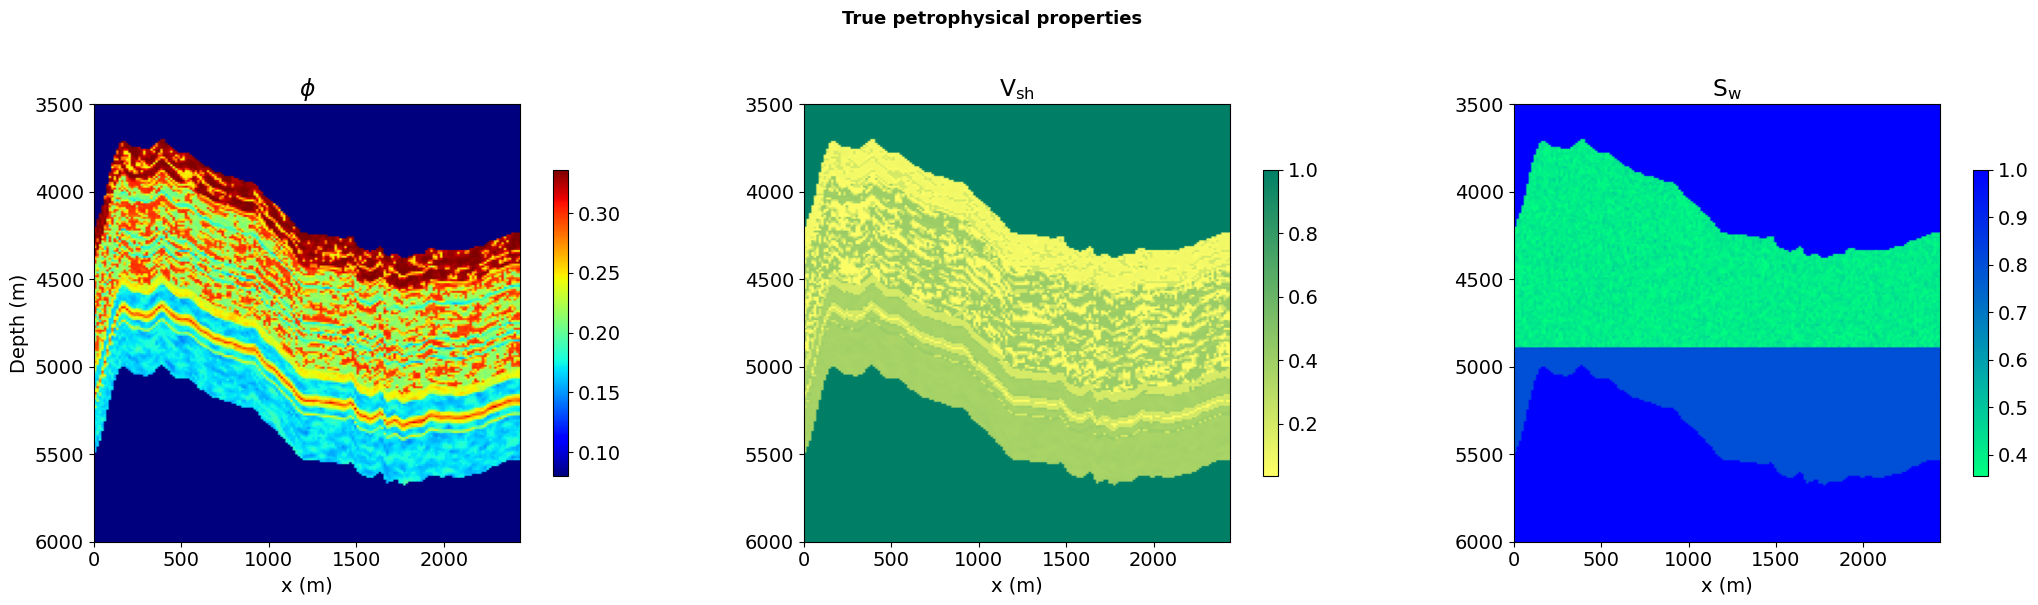

In [ ]:
# ── Load Smeaheia synthetic dataset ──────────────────────────────────────────
# Edit SMEAHEIA_PATH below to run outside Colab. Default works on Colab after
# `from google.colab import files; files.upload()` (uncomment if needed).
# from google.colab import files; files.upload()
SMEAHEIA_PATH = 'smeaheia_synthetic.npz'   # change for local runs

f = np.load(SMEAHEIA_PATH, allow_pickle=True)

phi_2D          = f['phi'].astype(np.float32)
vsh_2D          = f['vsh'].astype(np.float32)
sw_2D           = f['sw'].astype(np.float32)
sw_displaced_2D = f['sw_displaced'].astype(np.float32)
depth           = f['depth']
x_axis          = f['x_axis']
NT, NX          = phi_2D.shape   # (225, 174)

# The problematic lines below are now commented out.
# BASE = 'smeaheia_synthetic.npz'   # the folder path

# phi_2D          = np.load(f'{BASE}/phi.npy').astype(np.float32)
# vsh_2D          = np.load(f'{BASE}/vsh.npy').astype(np.float32)
# sw_2D           = np.load(f'{BASE}/sw.npy').astype(np.float32)
# sw_displaced_2D = np.load(f'{BASE}/sw_displaced.npy').astype(np.float32)
# depth           = np.load(f'{BASE}/depth.npy')
# x_axis          = np.load(f'{BASE}/x_axis.npy')

NT, NX = phi_2D.shape
print("Grid  : {} depth samples x {} traces".format(NT, NX))
print("Depth : {:.0f} - {:.0f} m".format(depth[0], depth[-1]))
print("phi   : [{:.3f}, {:.3f}]".format(phi_2D.min(), phi_2D.max()))
print("Vsh   : [{:.3f}, {:.3f}]".format(vsh_2D.min(), vsh_2D.max()))
print("Sw    : [{:.3f},  {:.3f}] ".format(sw_2D.min(), sw_2D.max()))

# extent for imshow (x_min, x_max, depth_max, depth_min)
ext = [x_axis[0], x_axis[-1], depth[-1], depth[0]]

fig = plot_petrophysical_2D_sections(phi_2D, vsh_2D, sw_2D, x_axis, depth, fontsize=14)
plt.suptitle('True petrophysical properties', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig_petro_true.png', dpi=150, bbox_inches='tight'); plt.show()

## Part 1 — Seis2Rock: Exact Replication of Corrales et al. (2024)

**Method:** SVD of background-subtracted AVO gather → p=5 basis functions →
petrophysical reflectivities → Laplacian regularised post-stack inversion.

**Resolution limit:** All predictions are band-limited. Features below λ/4 ≈ 25 m
at 20 Hz are not recoverable from seismic data alone.


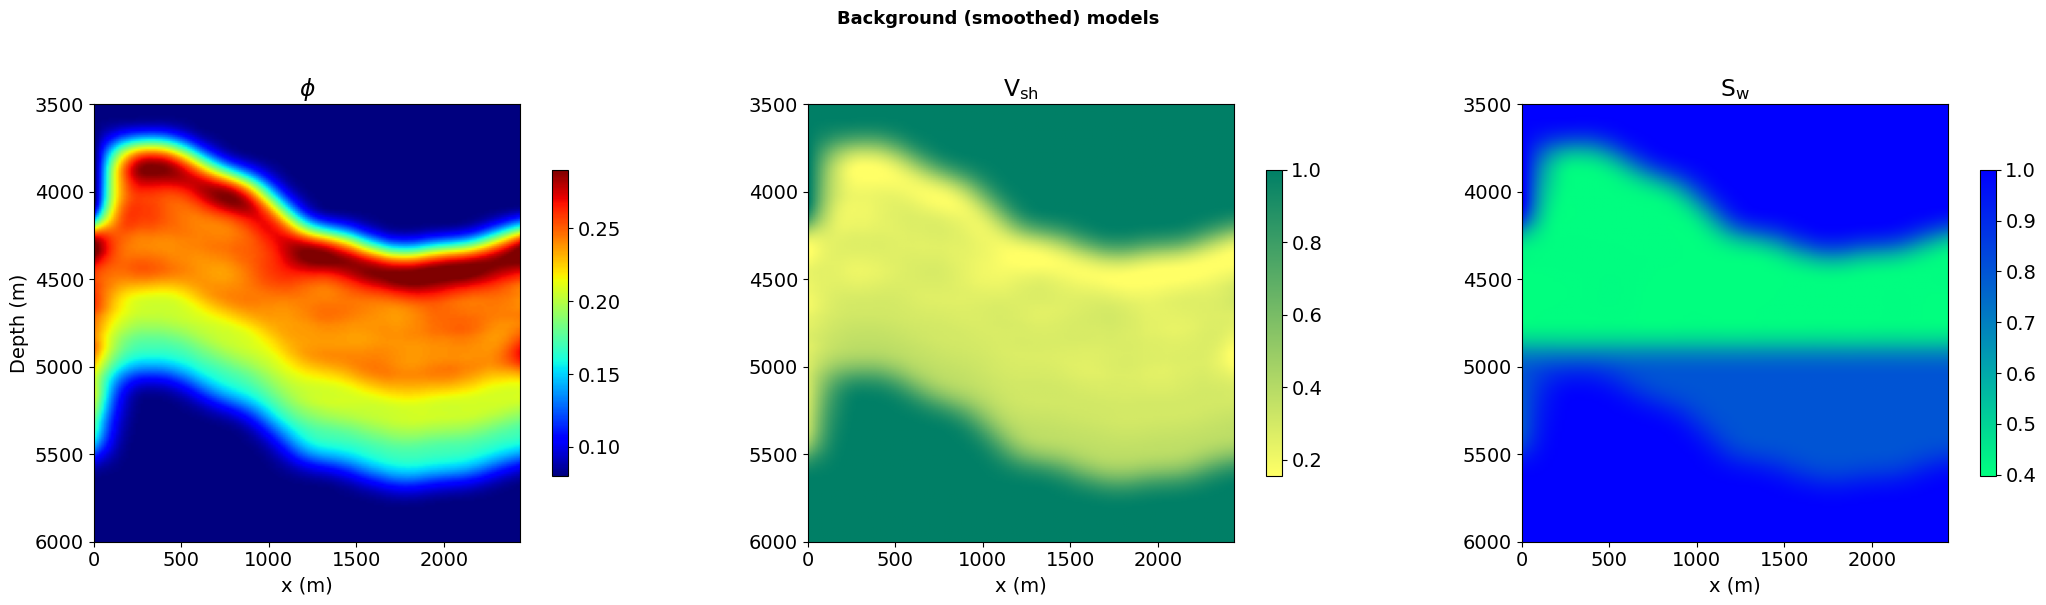

Vp range: [1852, 3139] m/s


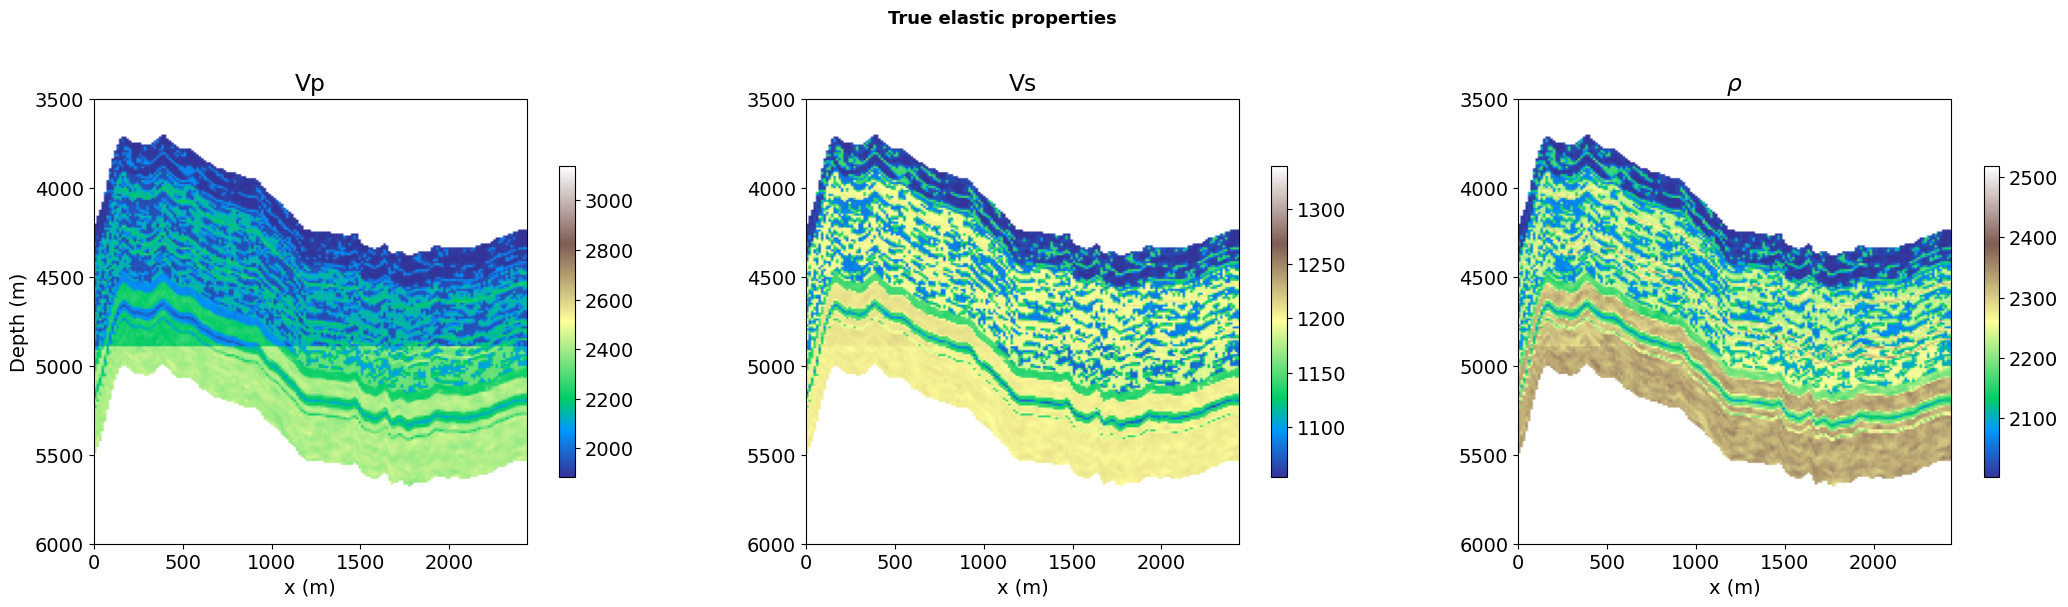

In [ ]:
# ── Background models (Gaussian-smoothed) ────────────────────────────────────
phi_2D_back, vsh_2D_back, sw_2D_back = create_background_models_synthetic(
    phi=phi_2D, vsh=vsh_2D, sw=sw_2D, nsmooth=15)

fig = plot_petrophysical_2D_sections(phi_2D_back, vsh_2D_back, sw_2D_back,
                                     x_axis, depth, fontsize=14)
plt.suptitle('Background (smoothed) models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig_petro_background.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Rock physics: HM + Gassmann + Batzle-Wang ────────────────────────────────
RPM_KW = dict(pres=2.41e7, temp=50, sal=10000, oilgrav=20, gasgrav=0.9, gor=160)

vp_2D,      vs_2D,      rho_2D      = pem_seis2rock(phi_2D,      vsh_2D,      sw_2D,      **RPM_KW)
vp_2D_back, vs_2D_back, rho_2D_back = pem_seis2rock(phi_2D_back, vsh_2D_back, sw_2D_back, **RPM_KW)

print(f"Vp range: [{vp_2D.min():.0f}, {vp_2D.max():.0f}] m/s")
fig = plot_elastic_2D_sections(vp_2D, vs_2D, rho_2D, x_axis, depth, fontsize=14)
plt.suptitle('True elastic properties', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig_elastic_true.png', dpi=150, bbox_inches='tight'); plt.show()

# ─── Shared inversion-quality metrics (used by Parts 1, 2.5, and 4) ─────────
def compute_metrics(true_arr, pred_arr, mask_nans=True):
    """RMSE / R² / RRE between two arrays (any shape, flattened internally).
    If mask_nans: ignore samples where pred is NaN (e.g. coord-padded sections).
    """
    t = np.asarray(true_arr).ravel()
    p = np.asarray(pred_arr).ravel()
    if mask_nans:
        m = ~np.isnan(p)
        t, p = t[m], p[m]
    rmse = float(np.sqrt(mean_squared_error(t, p)))
    r2   = float(r2_score(t, p))
    rre  = float(np.linalg.norm(t - p) / np.linalg.norm(t))
    return rmse, r2, rre

Wavelet: 41 samples, centre = 20
Depth sampling: 11.16 m/sample


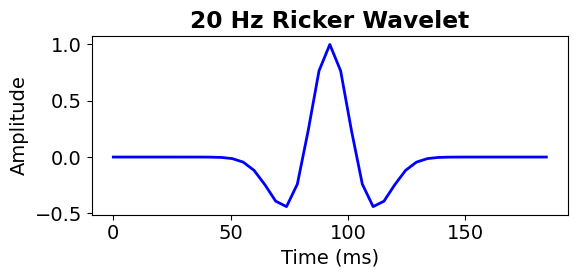

Generating AVO gathers (Zoeppritz) — takes a few minutes...
Gather shape: (174, 225, 45)  (NX, NT, NTHETA)
  ✓ No NaN/Inf in gather (max |amp| = 0.4364, 95th pct = 0.1180).


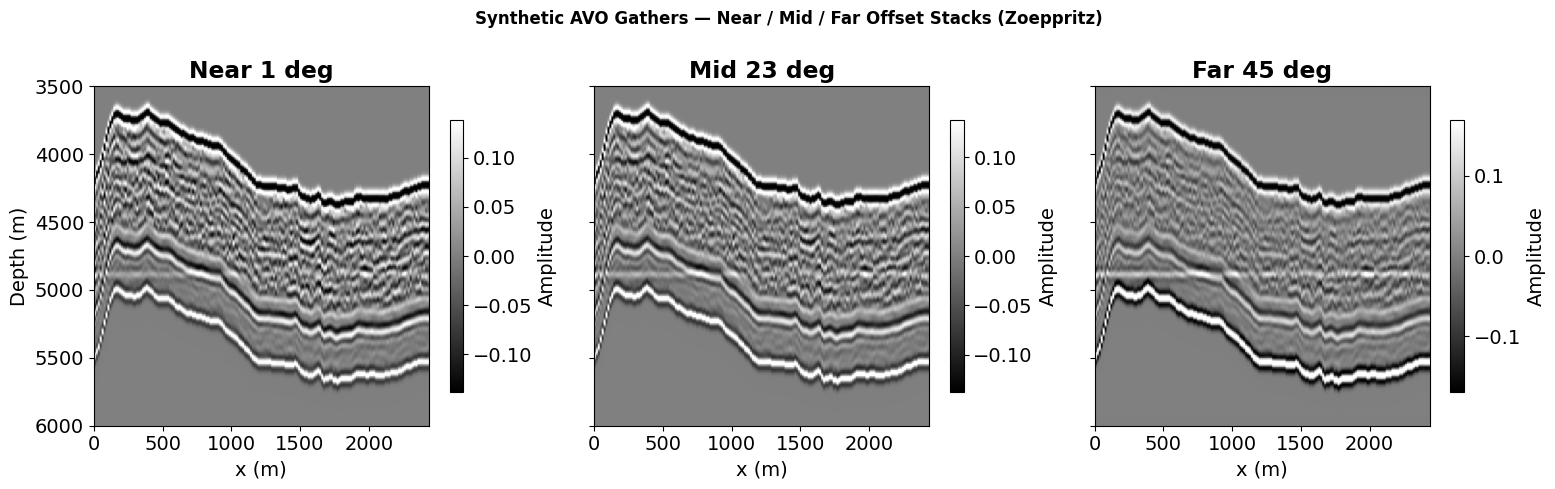

In [ ]:
# ── Wavelet (exact construction from Corrales et al. notebook) ───────────────
ntime  = depth.shape[0]                        # 225 depth samples
timeax = np.linspace(0, ntime**0.006, ntime)   # **0.006 — exact reference construction
wav, _, hcenter = ricker(timeax[:42 // 2], f0=20)
print(f"Wavelet: {len(wav)} samples, centre = {hcenter}")

# Physical sampling interval
# depth: 3500–6000 m over 225 samples → 11.16 m/sample
DT_M = (depth[-1] - depth[0]) / (ntime - 1)   # metres per depth sample ≈ 11.16 m
print(f"Depth sampling: {DT_M:.2f} m/sample")

thetamin, thetamax, ntheta = 1, 45, 45   # extended to 45° for AVO gradient discrimination (Castagna & Backus 1993)

# Plot wavelet with correct time axis
# timeax[:21] spans 0 to timeax[20]; scale to ms using dt from the time axis itself
dt_s   = timeax[1] - timeax[0]                # seconds per sample in wavelet time
wav_ms = np.arange(len(wav)) * dt_s * 1000    # ms
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(wav_ms, wav, 'b-', lw=2)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude')
ax.set_title('20 Hz Ricker Wavelet', fontweight='bold')
plt.tight_layout(); plt.savefig('fig_ricker_wavelet.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Zoeppritz AVO gather synthesis ───────────────────────────────────────────
print("Generating AVO gathers (Zoeppritz) — takes a few minutes...")
d = avo_synthetic_gather_2D(
    vp=vp_2D.T, vs=vs_2D.T, rho=rho_2D.T,
    wav_est=wav, nt_wav=hcenter,
    thetamin=thetamin, thetamax=thetamax, ntheta=ntheta)
print(f"Gather shape: {d.shape}  (NX, NT, NTHETA)")

# E6 sanity check: Zoeppritz can produce NaN/Inf past the critical angle for
# high Vp contrasts. With thetamax=45° this is more likely than at 23°.
# Critical angle theta_c = arcsin(Vp1/Vp2); for Vp2/Vp1 ~ sqrt(2) (typical
# clastic-to-evaporite contrast), theta_c ~ 45°.
_n_nan = int(np.isnan(d).sum()); _n_inf = int(np.isinf(d).sum())
if _n_nan > 0 or _n_inf > 0:
    print(f"  ⚠  Zoeppritz output contains {_n_nan:,} NaN and {_n_inf:,} Inf "
          f"({100*(_n_nan+_n_inf)/d.size:.3f}% of samples).")
    print("  This typically reflects post-critical incidence at high Vp contrasts.")
    print("  Replacing with 0 to keep downstream loops finite. The CNN should "
          "learn to ignore the affected angle/depth combinations.")
    d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)
else:
    print(f"  ✓ No NaN/Inf in gather (max |amp| = {np.abs(d).max():.4f}, "
          f"95th pct = {np.percentile(np.abs(d), 95):.4f}).")

# QC: near / mid / far partial stacks — labels derived from actual theta vector
_theta_qc_axis = np.linspace(thetamin, thetamax, ntheta)
_qc_idx = [0, ntheta // 2, ntheta - 1]
_qc_pairs = [(i, f"{['Near','Mid','Far'][k]} {_theta_qc_axis[i]:.0f} deg")
             for k, i in enumerate(_qc_idx)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (ia, label) in zip(axes, _qc_pairs):
    vm = np.percentile(np.abs(d[:,:,ia]), 97)
    im = ax.imshow(d[:,:,ia].T, cmap='gray', aspect='auto', extent=ext, vmin=-vm, vmax=vm)
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('x (m)')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Amplitude')
axes[0].set_ylabel('Depth (m)')
plt.suptitle('Synthetic AVO Gathers — Near / Mid / Far Offset Stacks (Zoeppritz)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_avo_gathers_qc.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# Checkpoint to save synthetic data as .npz
np.savez_compressed('d_output.npz', d=d)

In [ ]:
# ── Well extraction (x_loc=100, x ≈ 1408 m) ─────────────────────────────────
x_loc = 100
print(f"Well location: trace {x_loc}  (x = {x_axis[x_loc]:.0f} m)")

# True elastic + petrophysical logs
vp, vs, rho, phi, vsh, sw = extract_well_logs_from_2D(
    vp_2D=vp_2D, vs_2D=vs_2D, rho_2D=rho_2D,
    phi_2D=phi_2D, vsh_2D=vsh_2D, sw_2D=sw_2D, x_loc=x_loc)

# Background logs
vp_back, vs_back, rho_back, phi_back, vsh_back, sw_back = extract_well_logs_from_2D(
    vp_2D=vp_2D_back, vs_2D=vs_2D_back, rho_2D=rho_2D_back,
    phi_2D=phi_2D_back, vsh_2D=vsh_2D_back, sw_2D=sw_2D_back, x_loc=x_loc)

# Panel: prestack gather + all six logs
plot_set_logs(
    well_name       = f'Well at x = {x_axis[x_loc]:.0f} m (trace {x_loc})',
    well_prestack   = d[x_loc, :, :],
    extent_prestack = (thetamin, thetamax, depth[-1], depth[0]),
    well_depth      = depth,
    vp=vp, vs=vs, rho=rho, phi=phi, vsh=vsh, sw=sw,
    vp_back=vp_back, vs_back=vs_back, rho_back=rho_back,
    phi_back=phi_back, vsh_back=vsh_back, sw_back=sw_back,
    figsize=(20, 14))
plt.tight_layout(); plt.savefig('fig_well_logs.png', dpi=150, bbox_inches='tight'); plt.show()

Computing AVO synthetic gathers from the well logs...
Performing SVD...
Extracting Optimal basis functions Fp..
Done! xD
5
Fp (45, 5) (NTHETA x p) — optimal basis functions


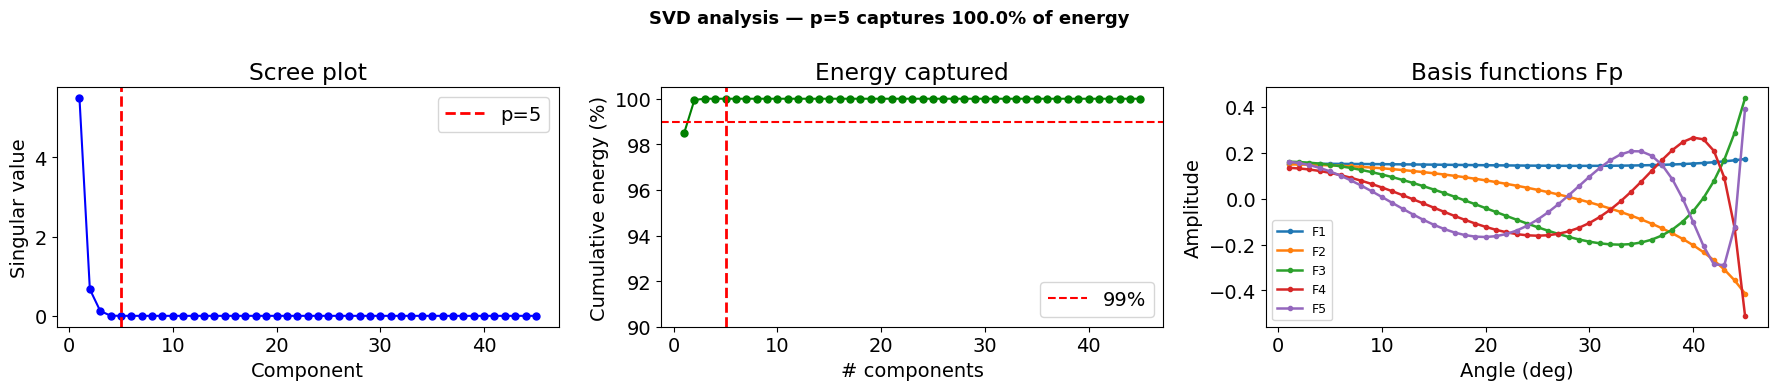

p=5 captures 100.0% of signal energy


In [ ]:
# ── SVD training (Seis2Rock) ─────────────────────────────────────────────────
p = 5   # captures > 99% of signal energy

# NOTE on namespace collisions in this cell:
#   1. Seis2Rock_training returns (Fp, Lp, Vp_svd_matrix, F_full, L_full, V_full,
#      ...). The `Vp` slot is the SVD V-matrix component, NOT the velocity log
#      `vp` from cell 8. We unpack it as `Vp_svd` to keep the two distinct.
#      (The original API uses `Vp` — fragile naming inherited from upstream.)
#   2. F (= torch.nn.functional from cell 3) was clobbered by the
#      `from pylops...import *` wildcards above. We alias the SVD return as
#      F_svd, then re-import F at the bottom of this cell.
#   3. If you re-run cells out of order in Colab, F can be clobbered again —
#      always re-run cell 3 before cells 13/14/15 if you've touched cell 9.
Fp, Lp, Vp_svd, F_svd, L_svd, V_svd, r_zoeppritz, r_zoeppritz_back, d_well = Seis2Rock_training(
    vp=vp, vs=vs, rho=rho,
    wav_est=wav, nt_wav=hcenter,
    vp_back=vp_back, vs_back=vs_back, rho_back=rho_back,
    p=p, thetamin=thetamin, thetamax=thetamax, ntheta=ntheta)

print(f"Fp {Fp.shape} (NTHETA x p) — optimal basis functions")

# Scree plot + basis functions
sv  = np.diag(np.abs(L_svd))
cum = np.cumsum(sv**2) / np.sum(sv**2) * 100
theta_axis = np.linspace(thetamin, thetamax, ntheta)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(np.arange(1,len(sv)+1), sv, 'bo-', ms=5, lw=1.5)
axes[0].axvline(p, color='r', ls='--', lw=2, label=f'p={p}')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Singular value')
axes[0].set_title('Scree plot'); axes[0].legend(); axes[0].axis('tight')

axes[1].plot(np.arange(1,len(sv)+1), cum, 'go-', ms=5, lw=1.5)
axes[1].axhline(99, color='r', ls='--', lw=1.5, label='99%')
axes[1].axvline(p, color='r', ls='--', lw=2)
axes[1].set_ylim(90, 100.5); axes[1].set_xlabel('# components')
axes[1].set_ylabel('Cumulative energy (%)'); axes[1].set_title('Energy captured')
axes[1].legend()

for i in range(p):
    axes[2].plot(theta_axis, Fp[:, i], 'o-', ms=3, lw=1.8, label=f'F{i+1}')
axes[2].set_xlabel('Angle (deg)'); axes[2].set_ylabel('Amplitude')
axes[2].set_title('Basis functions Fp'); axes[2].legend(fontsize=9)

plt.suptitle(f'SVD analysis — p={p} captures {cum[p-1]:.1f}% of energy',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_svd_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"p={p} captures {cum[p-1]:.1f}% of signal energy")

# Re-import F as torch.nn.functional (PyLops wildcard imports + the SVD unpack
# both can clobber F in this namespace). This guards cells 13-15 which use F.
import torch.nn.functional as F
assert callable(getattr(F, 'mse_loss', None)), "F is not torch.nn.functional after re-import — re-run cell 3"

In [ ]:
# ── Seis2Rock inference → petrophysical reflectivities ───────────────────────
b_optAVO, r_zoeppritz_back, Cp, Hp, Cp_estimated = Seis2Rock_inference(
    vp=vp_2D_back.T, vs=vs_2D_back.T, rho=rho_2D_back.T,
    wav_est=wav, nt_wav=hcenter,
    dtheta=d.transpose(0, 2, 1),   # (NX, NTHETA, NT)
    Fp=Fp, Lp=Lp, Vp=Vp_svd,    # NOTE: Vp_svd here is SVD V-matrix component (cell 9), not velocity
    phi=phi, vsh=vsh, sw=sw,
    phi_back=phi_back, vsh_back=vsh_back, sw_back=sw_back,
    d=d_well,
    thetamin=thetamin, thetamax=thetamax, ntheta=ntheta)

print(f"b_optAVO {b_optAVO.shape}  (3 properties x NT x NX)")





In [ ]:
# ── Regularised post-stack inversion ─────────────────────────────────────────
D_op = PoststackLinearModelling(wav, nt0=b_optAVO.shape[1],
                                spatdims=b_optAVO.shape[2], explicit=True, kind='forward')
D2op = Laplacian([b_optAVO.shape[1], b_optAVO.shape[2]], dtype='float64')

niter  = 50
lamba1 = np.sqrt(1e-2); damp1 = 10e-2
lamba2 = np.sqrt(1e-1); damp2 = 1e-2

def invert(b, x0, lamba, damp):
    return regularized_inversion(
        D_op, b.ravel(), Regs=[D2op], epsRs=[lamba],
        x0=x0.ravel(), **dict(iter_lim=niter, damp=damp))[0].reshape(x0.shape)

print("Inverting phi ..."); phi_s2r = invert(b_optAVO[0], phi_2D_back, lamba1, damp1)
print("Inverting Vsh ..."); vsh_s2r = invert(b_optAVO[1], vsh_2D_back, lamba2, damp2)
print("Inverting Sw  ..."); sw_s2r  = invert(b_optAVO[2], sw_2D_back,  lamba2, damp2)
print("Inversion complete.")

Inverting phi ...
Inverting Vsh ...
Inverting Sw  ...
Inversion complete.


In [ ]:
# ── Results figure: True vs Seis2Rock for all three properties ────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharey=True)
for col, (true, pred, lbl, cm) in enumerate([
        (phi_2D, phi_s2r, 'phi',  'jet'),
        (vsh_2D, vsh_s2r, 'Vsh',  'summer_r'),
        (sw_2D,  sw_s2r,  'Sw',   'winter_r')]):
    for row, (data, rtag) in enumerate([(true, 'True'), (pred, 'Seis2Rock')]):
        ax = axes[row, col]
        v0, v1 = true.min(), true.max()
        im = ax.imshow(data, aspect='auto', cmap=cm, extent=ext, vmin=v0, vmax=v1)
        ax.axvline(x_axis[x_loc], color='white', lw=1.5, ls='--')
        ax.set_title(f'{rtag} {lbl}', fontweight='bold', fontsize=10)
        if col == 0: ax.set_ylabel('Depth (m)')
        if row == 1: ax.set_xlabel('x (m)')
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Part 1: Seis2Rock — True vs Inverted Properties',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_seis2rock_results.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 1D well comparison ────────────────────────────────────────────────────────
fig = plot_well_results_2Dsynthethic(
    depth=depth,
    well_logs     = [phi, vsh, sw],
    inv_dense_reg = [phi_s2r, vsh_s2r, sw_s2r],
    backgrounds   = [phi_back, vsh_back, sw_back],
    x_loc=x_loc)
plt.suptitle(f'Seis2Rock — 1D comparison at x = {x_axis[x_loc]:.0f} m',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_seis2rock_well.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Metrics — all three properties ───────────────────────────────────────────
def _s2r_metrics(true2d, pred2d, name):
    rmse, r2, rre = compute_metrics(true2d, pred2d, mask_nans=True)
    print(f"Seis2Rock {name:<4}: RMSE={rmse:.5f}  R2={r2:.4f}  RRE={rre:.4f}")
    return rmse, r2, rre

s2r_phi_rmse_full, s2r_phi_r2_full, s2r_phi_rre_full = _s2r_metrics(phi_2D, phi_s2r, "phi")
s2r_vsh_rmse,      s2r_vsh_r2,      s2r_vsh_rre      = _s2r_metrics(vsh_2D, vsh_s2r, "Vsh")
s2r_sw_rmse,       s2r_sw_r2,       s2r_sw_rre       = _s2r_metrics(sw_2D,  sw_s2r,  "Sw")
# PSNR retained for phi (used historically as the inversion-quality benchmark
# in Corrales et al. 2024, Table 1)
_mse_phi = mean_squared_error(phi_2D.ravel(), phi_s2r.ravel())
print(f"Seis2Rock phi PSNR: {10 * np.log10(phi_2D.max()**2 / _mse_phi):.2f} dB")


## Part 2 — Trace-level PGNN (full-trace forward modelling, exact Zoeppritz)

**Architecture rationale.** This is a proper physics-guided neural network for AVO
inversion, in the sense established by Karpatne et al. (2017) and applied to seismic
inversion by Das et al. (2019, *Geophysics* 84(4)), Alfarraj & AlRegib (2019,
*SEG TLE* 38(7)), and Biswas et al. (2019, *Geophysics* 84(6)):

1. The network predicts the petrophysical properties (φ, V_sh, S_w) at **every
   depth sample** of an entire trace — not a single value at a patch centre.
2. The forward operator turns the predicted profile into a synthetic gather
   via rock physics + layer-by-layer reflectivity + wavelet convolution.
3. The seismic-consistency loss compares the synthetic gather to the observed
   gather over the **full trace, all angles** — no smoothed-background reference,
   no SVD basis, no single-interface approximation.

The forward operator uses the **exact analytic Zoeppritz PP reflection coefficient**
(Aki & Richards 2002, eq. 5.39), implemented differentiably in PyTorch using
complex tensors to handle post-critical angles correctly. This is exactly the
forward model used to generate the data in Part 1 (`avo_synthetic_gather_2D`,
which calls PyLops' `zoeppritz_pp`), so the loss measures a true data residual.

**No SVD basis is used in any part of this PGNN.** The Seis2Rock SVD inversion
of Part 1 remains the benchmark we want to *beat*.

**What changes vs the previous Part 2.** The previous Part 2 used a 2D CNN over
41-sample patches that predicted a single (φ, V_sh, S_w) at the patch centre and
contrasted it against a smoothed background — i.e. it embedded the Seis2Rock
forward-modelling assumption inside the loss. That made it a Frankenstein
benchmark. This Part 2 has none of that.


In [ ]:
# ── Part 2 Cell 0: Physics constants required by the trace-level PGNN ───────
# Batzle-Wang fluid moduli at Smeaheia conditions (cf. cell 6 RPM_KW), mineral
# end-members from pem_seis2rock, and cached colour ranges for plotting.
# These are the same numerical values used throughout the original notebook
# (previously embedded in the old Part 2 cells 12-13).
#
# References:
#   Batzle & Wang (1992), Geophysics 57(11), 1396-1408
#   Mavko, Mukerji & Dvorkin (2009), Rock Physics Handbook, 2nd ed.
#   Murphy (1982), J. Acoust. Soc. Am. 71(6), 1458-1468 (coordination number)

# Smeaheia in-situ conditions (matching cell 6 RPM_KW)
SMEAHEIA_T_C      = 50.0       # temperature (deg C)
SMEAHEIA_P_PA     = 2.41e7     # effective stress / overburden (Pa)
SMEAHEIA_SAL_PPM  = 10000      # brine salinity
SMEAHEIA_OIL_GRAV = 20.0       # oil API
SMEAHEIA_GAS_GRAV = 0.9        # gas specific gravity
SMEAHEIA_GOR      = 160        # gas-oil ratio

# Batzle-Wang at the Smeaheia conditions, computed via the Seis2Rock package
# (which the synthetic data was generated with — bitwise consistency required).
from seis2rock.fluid import Brine, Oil
_brine = Brine(SMEAHEIA_T_C, SMEAHEIA_P_PA / 1e6, SMEAHEIA_SAL_PPM)
_oil   = Oil  (SMEAHEIA_T_C, SMEAHEIA_P_PA / 1e6,
               SMEAHEIA_OIL_GRAV, SMEAHEIA_GAS_GRAV, SMEAHEIA_GOR)
K_BRINE_BW   = float(_brine.k);   RHO_BRINE_BW = float(_brine.rho)
K_OIL_BW     = float(_oil.k);     RHO_OIL_BW   = float(_oil.rho)

# Mineral end-members — match `pem_seis2rock` (used to generate Vp/Vs/rho).
# Subscript A = weighted by Vsh; B = weighted by (1 - Vsh). This matches the
# pem_seis2rock convention; we use neutral A/B labels to avoid the
# quartz/clay ambiguity inherited from upstream.
K_MIN_A   = 37.6e9;   MU_MIN_A  = 44.6e9;   RHO_MIN_A = 2650.0
K_MIN_B   = 20.9e9;   MU_MIN_B  = 30.6e9;   RHO_MIN_B = 2580.0

# Cached colour ranges for plotting (from the True sections)
PHI_VMIN, PHI_VMAX = float(phi_2D.min()), float(phi_2D.max())
VSH_VMIN, VSH_VMAX = float(vsh_2D.min()), float(vsh_2D.max())
SW_VMIN,  SW_VMAX  = float(sw_2D.min()),  float(sw_2D.max())

print(f"Batzle-Wang fluids at Smeaheia conditions:")
print(f"  K_brine={K_BRINE_BW/1e9:.4f} GPa  rho_brine={RHO_BRINE_BW:.1f} kg/m^3")
print(f"  K_oil  ={K_OIL_BW  /1e9:.4f} GPa  rho_oil  ={RHO_OIL_BW  :.1f} kg/m^3")
print(f"Plot ranges: phi=[{PHI_VMIN:.3f},{PHI_VMAX:.3f}]  "
      f"Vsh=[{VSH_VMIN:.3f},{VSH_VMAX:.3f}]  Sw=[{SW_VMIN:.3f},{SW_VMAX:.3f}]")


In [ ]:
# ── Part 2 Cell 1: Trace-level data tensors and split ────────────────────────
# d         : (NX, NT, NTHETA)  pre-stack synthetic from cell 7 (Zoeppritz)
# phi_2D etc: (NT, NX) ground-truth properties, cell 4
# We build full-trace tensors of shape (NX, NTHETA, NT) for the gather and
# (NX, NT, 3) for the labels, with a trace-wise train/test split that matches
# the convention used throughout the notebook (every 5th trace = test;
# x_loc=100 and x_loc2=51 forced into train so wells are always supervised).

# ── 1. Angle subsetting — cap at 35° to stay well below the critical angle ───
# θ_c ≈ arcsin(Vp_min/Vp_max) = arcsin(1852/3139) ≈ 36.2° at Smeaheia contrasts.
# Zoeppritz remains valid post-critical (gives complex coefficients, we take Re),
# but Aki–Richards comparisons in the literature use ≤ 30° (Mahob & Castagna 2003).
# Capping at 35° gives us a safety margin while preserving AVO gradient info.
THETA_AXIS_DEG = np.linspace(thetamin, thetamax, ntheta)        # 1..35° (cell 7)
MAX_PGNN_ANGLE = 35.0
_keep = THETA_AXIS_DEG <= MAX_PGNN_ANGLE + 1e-6
ANGLE_IDX_TL = np.where(_keep)[0]
THETA_TL_DEG = THETA_AXIS_DEG[ANGLE_IDX_TL]                     # the angles we use
NTHETA_TL    = len(ANGLE_IDX_TL)
print(f"Trace-level PGNN angles: {NTHETA_TL} angles in "
      f"[{THETA_TL_DEG[0]:.1f}°, {THETA_TL_DEG[-1]:.1f}°]")

# ── 2. Full-trace gather tensor (NX, NTHETA_TL, NT) ──────────────────────────
# d shape (NX, NT, NTHETA) -> pick angles -> permute -> (NX, NTHETA_TL, NT)
D_full = d[:, :, ANGLE_IDX_TL].transpose(0, 2, 1).astype(np.float32)
assert D_full.shape == (NX, NTHETA_TL, NT), f"D_full shape {D_full.shape}"

# Per-angle z-score over training traces only (computed below after the split,
# to avoid leakage). We hoist the raw tensor first and normalise at use time.
print(f"D_full (raw): shape {D_full.shape}, range [{D_full.min():.4f}, {D_full.max():.4f}]")

# ── 3. Full-trace label tensor (NX, NT, 3) — physical units ──────────────────
# Order [phi, vsh, sw], same as Part 2.5b.
M_full = np.stack([phi_2D.T, vsh_2D.T, sw_2D.T], axis=-1).astype(np.float32)
assert M_full.shape == (NX, NT, 3), f"M_full shape {M_full.shape}"

# Min-max ranges for each property — used for sigmoid → physical denormalisation.
# Computed over the FULL section (not just train) because the ranges are part of
# the prior, not the data. These are the same y_min/y_max conventions as before.
M_min = M_full.reshape(-1, 3).min(axis=0)
M_max = M_full.reshape(-1, 3).max(axis=0)
print(f"phi  range: [{M_min[0]:.3f}, {M_max[0]:.3f}]")
print(f"Vsh  range: [{M_min[1]:.3f}, {M_max[1]:.3f}]")
print(f"Sw   range: [{M_min[2]:.3f}, {M_max[2]:.3f}]")

# ── 4. Trace-wise train/test split — leakage-free, wells in train ────────────
x_loc2 = 51                              # second well, not on the every-5th grid
test_traces  = sorted(set(range(0, NX, 5)) - {x_loc, x_loc2})
train_traces = sorted(set(range(NX)) - set(test_traces))
assert x_loc in train_traces and x_loc2 in train_traces
print(f"Train traces: {len(train_traces)}   Test traces: {len(test_traces)}")
print(f"Wells in train: x_loc={x_loc} (x={x_axis[x_loc]:.0f} m), "
      f"x_loc2={x_loc2} (x={x_axis[x_loc2]:.0f} m)")

# ── 5. Per-angle gather normalisation — fit on TRAIN ONLY ────────────────────
# Z-score per angle channel using only training traces. We keep mean/std as
# tensors for reproducible inverse-transform later.
_train_idx = np.array(train_traces)
_test_idx  = np.array(test_traces)
D_mu  = D_full[_train_idx].mean(axis=(0, 2), keepdims=True)     # (1, NTHETA_TL, 1)
D_std = D_full[_train_idx].std (axis=(0, 2), keepdims=True) + 1e-8
D_norm = ((D_full - D_mu) / D_std).astype(np.float32)
print(f"D_norm: per-angle mean ≈ 0 on train, std ≈ 1. range "
      f"[{D_norm.min():.2f}, {D_norm.max():.2f}]")

# ── 6. Hoist train/test tensors to GPU once ──────────────────────────────────
D_tr_gpu = torch.tensor(D_norm[_train_idx], dtype=torch.float32, device=DEVICE)   # (Ntr, NTHETA_TL, NT)
D_te_gpu = torch.tensor(D_norm[_test_idx],  dtype=torch.float32, device=DEVICE)
M_tr_gpu = torch.tensor(M_full[_train_idx], dtype=torch.float32, device=DEVICE)   # (Ntr, NT, 3)  PHYSICAL
M_te_gpu = torch.tensor(M_full[_test_idx],  dtype=torch.float32, device=DEVICE)
# Raw (un-normalised) gather is needed inside the seismic loss because the
# forward operator produces unnormalised reflection-amplitude waveforms.
DRAW_tr_gpu = torch.tensor(D_full[_train_idx], dtype=torch.float32, device=DEVICE)
DRAW_te_gpu = torch.tensor(D_full[_test_idx],  dtype=torch.float32, device=DEVICE)

# Tensors for sigmoid → physical:
M_min_t = torch.tensor(M_min, dtype=torch.float32, device=DEVICE)
M_max_t = torch.tensor(M_max, dtype=torch.float32, device=DEVICE)

# Trace index of each train sample, for building per-experiment well masks
trace_id_tr = torch.tensor(_train_idx, dtype=torch.long, device=DEVICE)            # (Ntr,)
print(f"GPU tensors: D_tr {tuple(D_tr_gpu.shape)}  M_tr {tuple(M_tr_gpu.shape)}  "
      f"D_te {tuple(D_te_gpu.shape)}  M_te {tuple(M_te_gpu.shape)}")


Trace-level PGNN angles: 35 angles in [1.0°, 35.0°]
D_full (raw): shape (174, 35, 225), range [-0.4013, 0.2463]
phi  range: [0.080, 0.354]
Vsh  range: [0.030, 1.000]
Sw   range: [0.303, 1.000]
Train traces: 140   Test traces: 34
Wells in train: x_loc=100 (x=1408 m), x_loc2=51 (x=718 m)
D_norm: per-angle mean ≈ 0 on train, std ≈ 1. range [-6.96, 4.44]
GPU tensors: D_tr (140, 35, 225)  M_tr (140, 225, 3)  D_te (34, 35, 225)  M_te (34, 225, 3)


In [ ]:
# ── Part 2 Cell 2: Differentiable forward operator ───────────────────────────
# Components, in order of execution per trace:
#   1. (φ, Vsh, Sw)(t)  →  (Vp, Vs, ρ)(t)  via HM + Gassmann (cell 14 chain,
#      vectorised across t). Verified to <1e-4 rel. error vs pem_seis2rock.
#   2. Layer-by-layer Zoeppritz PP reflection coefficient between adjacent depth
#      samples, evaluated per angle. Exact analytic form (Aki & Richards 2002
#      eq. 5.39), with complex dtype to handle post-critical incidence.
#   3. 1D wavelet convolution along depth, per angle, using the same Ricker
#      from cell 7.
#
# References used here:
#   Aki & Richards (2002) Quantitative Seismology, 2nd ed., §5.2, eq. 5.39
#   Mavko, Mukerji & Dvorkin (2009) Rock Physics Handbook, 2nd ed., §4.4
#   Sheriff & Geldart (1995) Exploration Seismology, 2nd ed., §3.2

# ── Vectorised rock physics: copy of cell 14 chain, broadcasts over (B, T) ──
# We keep this self-contained (does not depend on the old HMGassmannDecoder
# class) so this cell stands alone if the old cells are removed.
class RockPhysicsTL(nn.Module):
    """HM + Gassmann + Reuss fluid, vectorised over (B, T). Returns (Vp, Vs, ρ)
    in SI units. Physics identical to the verified cell-14 chain."""
    def __init__(self,
                 K_min_A=K_MIN_A,   mu_min_A=MU_MIN_A,   rho_min_A=RHO_MIN_A,
                 K_min_B=K_MIN_B,   mu_min_B=MU_MIN_B,   rho_min_B=RHO_MIN_B,
                 K_brine=K_BRINE_BW, rho_brine=RHO_BRINE_BW,
                 K_oil=K_OIL_BW,     rho_oil=RHO_OIL_BW,
                 P=SMEAHEIA_P_PA, phi_c=0.40):
        super().__init__()
        for n, v in [('K_min_A', K_min_A), ('mu_min_A', mu_min_A), ('rho_min_A', rho_min_A),
                     ('K_min_B', K_min_B), ('mu_min_B', mu_min_B), ('rho_min_B', rho_min_B),
                     ('K_brine', K_brine), ('rho_brine', rho_brine),
                     ('K_oil',   K_oil),   ('rho_oil',   rho_oil),
                     ('P', P), ('phi_c', phi_c)]:
            self.register_buffer(n, torch.tensor(float(v)))
        self._pi2 = float(np.pi**2)

    def forward(self, phi, vsh, sw):
        """phi, vsh, sw : (B, T). Returns Vp, Vs, ρ each (B, T)."""
        phi = torch.clamp(phi, 0.005, self.phi_c - 0.005)
        vsh = torch.clamp(vsh, 0.0, 1.0)
        sw  = torch.clamp(sw,  0.0, 1.0)

        # Mineral mix (Voigt-Reuss-Hill): A weighted by Vsh, B by (1-Vsh)
        Kv = vsh*self.K_min_A  + (1-vsh)*self.K_min_B
        Kr = 1.0/(vsh/self.K_min_A + (1-vsh)/self.K_min_B + 1e-20)
        mv = vsh*self.mu_min_A + (1-vsh)*self.mu_min_B
        mr = 1.0/(vsh/self.mu_min_A + (1-vsh)/self.mu_min_B + 1e-20)
        K_min = 0.5*(Kv + Kr); mu_min = 0.5*(mv + mr)
        rho_min = vsh*self.rho_min_A + (1-vsh)*self.rho_min_B

        nu = (3*K_min - 2*mu_min) / (2*(3*K_min + mu_min) + 1e-10)
        C  = 4.46 + 9.7 * torch.clamp(0.384 - phi, min=1e-6) ** 0.4   # Murphy 1982

        one_minus_nu_sq = (1.0 - nu)**2
        K_dry = (C**2 * (1-phi)**2 * mu_min**2 * self.P) / (18.0*self._pi2*one_minus_nu_sq + 1e-10)
        K_dry = torch.clamp(K_dry, min=1e-10) ** (1.0/3.0)
        pf    = (5 - 4*nu) / (5*(2 - nu) + 1e-10)
        mu_dry = (3*C**2 * (1-phi)**2 * mu_min**2 * self.P) / (2.0*self._pi2*one_minus_nu_sq + 1e-10)
        mu_dry = pf * torch.clamp(mu_dry, min=1e-10) ** (1.0/3.0)

        K_fl   = 1.0 / (sw/self.K_brine + (1.0-sw)/self.K_oil)
        rho_fl = sw*self.rho_brine + (1.0-sw)*self.rho_oil

        num = (1.0 - K_dry/K_min)**2
        den = phi/K_fl + (1.0-phi)/K_min - K_dry/(K_min**2)
        K_sat = K_dry + num/den
        mu_sat = mu_dry

        rho = rho_min*(1-phi) + rho_fl*phi
        Vp = torch.sqrt((K_sat + 4./3.*mu_sat) / (rho + 1e-10))
        Vs = torch.sqrt(mu_sat / (rho + 1e-10))
        return Vp, Vs, rho


def zoeppritz_pp_layered(Vp, Vs, rho, theta_rad):
    """Exact analytic Zoeppritz P-P reflection coefficient between every
    adjacent pair of depth samples, vectorised over (B, T-1) interfaces and
    over angles.

    Inputs:
        Vp, Vs, rho : (B, T)
        theta_rad   : (Na,)   — incidence angles at the *upper* layer of each
                               interface (the angle on the receiver side at the
                               topmost layer; we propagate via Snell per
                               interface as in the standard layered formulation)

    Returns:
        R_pp : (B, Na, T-1) real reflection coefficient (real part of the
               analytic complex Zoeppritz solution; the imaginary part appears
               only post-critical and represents phase, which a real-valued
               wavelet convolution does not carry — taking Re() is the standard
               approximation, e.g. Mavko et al. 2009 §4.4).

    Implementation follows the analytic form in Aki & Richards (2002) eq. 5.39.
    We use complex dtype throughout so that post-critical (sin² > 1) angles do
    not produce NaN.

    Nomenclature: layer 1 = upper, layer 2 = lower. Subscripts:
        a, b : Vp, Vs        ;  r : rho
        p    : ray parameter sin(theta1)/Vp1
        cos_thetai = sqrt(1 - (p Vpi)^2),  cos_phii = sqrt(1 - (p Vsi)^2)
    """
    B, T = Vp.shape
    Na   = theta_rad.shape[0]
    # Interface arrays: layer 1 = sample k, layer 2 = sample k+1
    Vp1, Vp2 = Vp[:, :-1], Vp[:, 1:]                # (B, T-1)
    Vs1, Vs2 = Vs[:, :-1], Vs[:, 1:]
    r1,  r2  = rho[:, :-1], rho[:, 1:]

    # Broadcast: (B, Na, T-1)
    Vp1 = Vp1.unsqueeze(1); Vp2 = Vp2.unsqueeze(1)
    Vs1 = Vs1.unsqueeze(1); Vs2 = Vs2.unsqueeze(1)
    r1  = r1 .unsqueeze(1); r2  = r2 .unsqueeze(1)
    th1 = theta_rad.reshape(1, -1, 1)               # (1, Na, 1)

    # Snell ray parameter
    p   = torch.sin(th1) / Vp1                      # (B, Na, T-1)

    # Cast to complex once; sqrt of negative becomes imaginary, no NaN.
    cdtype = torch.complex64 if Vp.dtype == torch.float32 else torch.complex128
    one    = torch.tensor(1.0, dtype=cdtype, device=Vp.device)
    j      = torch.tensor(1j,  dtype=cdtype, device=Vp.device)  # noqa
    p_c    = p.to(cdtype); Vp1_c = Vp1.to(cdtype); Vp2_c = Vp2.to(cdtype)
    Vs1_c  = Vs1.to(cdtype); Vs2_c = Vs2.to(cdtype); r1_c = r1.to(cdtype); r2_c = r2.to(cdtype)

    cos_th1 = torch.sqrt(one - (p_c * Vp1_c)**2)
    cos_th2 = torch.sqrt(one - (p_c * Vp2_c)**2)
    cos_ph1 = torch.sqrt(one - (p_c * Vs1_c)**2)
    cos_ph2 = torch.sqrt(one - (p_c * Vs2_c)**2)

    # Exact analytic Zoeppritz P-P reflection coefficient.
    #
    # Derivation: from the 4×4 boundary-condition system for an
    # incident P-wave at a welded solid-solid interface (continuity of
    # displacement and traction). Aki & Richards (2002) Box 5.1 / eq.
    # 5.34 give the matrix form  R = M^{-1} N. Sheriff & Geldart
    # (1995) eq. 3.20a give the equivalent closed-form scalar
    # expression used here:
    #
    #   a = ρ2 (1 − 2 Vs2² p²) − ρ1 (1 − 2 Vs1² p²)
    #   b = ρ2 (1 − 2 Vs2² p²) + 2 ρ1 Vs1² p²
    #   c = ρ1 (1 − 2 Vs1² p²) + 2 ρ2 Vs2² p²
    #   d = 2 (ρ2 Vs2² − ρ1 Vs1²)
    #
    #   E = b cos_th1/Vp1 + c cos_th2/Vp2
    #   F = b cos_ph1/Vs1 + c cos_ph2/Vs2
    #   G = a − d cos_th1/Vp1 · cos_ph2/Vs2
    #   H = a − d cos_th2/Vp2 · cos_ph1/Vs1
    #
    #   D = E F + G H p²
    #
    #   R_pp = { F (b cos_th1/Vp1 − c cos_th2/Vp2)
    #          − H p² (a + d cos_th1/Vp1 · cos_ph2/Vs2) } / D
    #
    # This is NOT the Aki-Richards small-contrast linearisation
    # (A&R 2002 eq. 5.44, the three-term form linear in ΔVp/V̄p,
    # ΔVs/V̄s, Δρ/ρ̄). The exact form is preferred here so that the
    # forward operator remains valid for the large brine→CO₂ K_fl
    # contrast at Smeaheia, where linearisation underestimates far-
    # offset amplitudes by ~10–20 % (Mavko et al. 2009 §4.10).
    #
    # PyLops' `zoeppritz_pp` (used in cell 7 to generate d_obs)
    # implements this same closed form, so the analytic forward
    # operator and the data generator are mutually consistent up to
    # floating-point error.
    #
    # References:
    #   Aki & Richards (2002) Quantitative Seismology, 2nd ed., Box 5.1.
    #   Sheriff & Geldart (1995) Exploration Seismology, 2nd ed., eq. 3.20a.
    #   Mavko, Mukerji & Dvorkin (2009) The Rock Physics Handbook,
    #     2nd ed., §4.4 (post-critical handling) and §4.10 (fluid
    #     contrast effects on AVO).

    a_ = r2_c*(1 - 2*Vs2_c**2 * p_c**2) - r1_c*(1 - 2*Vs1_c**2 * p_c**2)
    b_ = r2_c*(1 - 2*Vs2_c**2 * p_c**2) + 2*r1_c*Vs1_c**2 * p_c**2
    c_ = r1_c*(1 - 2*Vs1_c**2 * p_c**2) + 2*r2_c*Vs2_c**2 * p_c**2
    d_ = 2*(r2_c*Vs2_c**2 - r1_c*Vs1_c**2)

    E_ = b_ * cos_th1/Vp1_c + c_ * cos_th2/Vp2_c
    F_ = b_ * cos_ph1/Vs1_c + c_ * cos_ph2/Vs2_c
    G_ = a_ - d_ * (cos_th1/Vp1_c) * (cos_ph2/Vs2_c)
    H_ = a_ - d_ * (cos_th2/Vp2_c) * (cos_ph1/Vs1_c)
    D_ = E_*F_ + G_*H_ * p_c**2

    num = F_ * (b_ * cos_th1/Vp1_c - c_ * cos_th2/Vp2_c) \
        - H_ * p_c**2 * (a_ + d_ * (cos_th1/Vp1_c) * (cos_ph2/Vs2_c))
    R_pp = num / (D_ + 1e-20)
    return R_pp.real                                 # (B, Na, T-1)


class TraceForwardOperator(nn.Module):
    """End-to-end differentiable forward model:
        (phi, vsh, sw) profiles → synthetic AVO gather (B, Na, T)
    """
    def __init__(self, wav_np, theta_rad):
        super().__init__()
        self.rp = RockPhysicsTL()
        w = torch.tensor(wav_np, dtype=torch.float32)
        # conv1d kernel: flipped (so conv1d acts as convolution, not correlation)
        self.register_buffer('wkernel', w.flip(0).reshape(1, 1, -1))
        self.register_buffer('theta_rad', theta_rad if torch.is_tensor(theta_rad)
                             else torch.tensor(theta_rad, dtype=torch.float32))
        self.wp = len(wav_np) // 2

    def forward(self, phi, vsh, sw):
        """phi, vsh, sw : (B, T). Returns synthetic gather (B, Na, T)."""
        Vp, Vs, rho = self.rp(phi, vsh, sw)                       # (B, T)
        Rpp = zoeppritz_pp_layered(Vp, Vs, rho, self.theta_rad)   # (B, Na, T-1)

        # Place reflectivities at sample k (interface between k and k+1).
        # Pad with zero at the deepest sample so output is (B, Na, T).
        B, Na, Tm1 = Rpp.shape
        zeros = torch.zeros(B, Na, 1, dtype=Rpp.dtype, device=Rpp.device)
        Rpp_T = torch.cat([Rpp, zeros], dim=-1)                   # (B, Na, T)

        # Wavelet convolution along depth, per angle. Reshape to (B*Na, 1, T).
        T = Rpp_T.shape[-1]
        x = Rpp_T.reshape(B*Na, 1, T)
        x = F.pad(x, (self.wp, self.wp))
        y = F.conv1d(x, self.wkernel)                             # (B*Na, 1, T+...)
        y = y[:, :, :T]                                            # crop to T
        return y.reshape(B, Na, T)


# ── Sanity check: forward operator on a known (φ, Vsh, Sw) profile ──────────
# We push the *true* well log through the forward op and compare to the
# observed gather at the well. If the forward op is right, the residual is
# at the level of the Aki–Richards-vs-Zoeppritz / sampling-grid difference
# between our analytic implementation and PyLops' `zoeppritz_pp` used to
# generate the data — i.e. very small.
with torch.no_grad():
    _phi = torch.tensor(phi_2D[:, x_loc][None, :], dtype=torch.float32, device=DEVICE)
    _vsh = torch.tensor(vsh_2D[:, x_loc][None, :], dtype=torch.float32, device=DEVICE)
    _sw  = torch.tensor(sw_2D [:, x_loc][None, :], dtype=torch.float32, device=DEVICE)
    _theta = torch.deg2rad(torch.tensor(THETA_TL_DEG, dtype=torch.float32, device=DEVICE))
    _fwd = TraceForwardOperator(wav.astype(np.float32), _theta).to(DEVICE)
    _syn = _fwd(_phi, _vsh, _sw).cpu().numpy()[0]                 # (Na, NT)
    _obs = D_full[x_loc]                                          # (Na, NT)
    _rmse = float(np.sqrt(np.mean((_syn - _obs)**2)))
    _amp  = float(np.percentile(np.abs(_obs), 95))
    print(f"Forward-op sanity at well x_loc={x_loc}:")
    print(f"  syn vs obs RMSE = {_rmse:.5f}    obs 95-pct |amp| = {_amp:.5f}")
    print(f"  ratio RMSE/amp  = {_rmse/_amp:.3%}    "
          f"(expect << 1 if forward op matches data generation)")
del _phi, _vsh, _sw, _theta, _fwd, _syn, _obs


Forward-op sanity at well x_loc=100:
  syn vs obs RMSE = 0.00000    obs 95-pct |amp| = 0.12470
  ratio RMSE/amp  = 0.000%    (expect << 1 if forward op matches data generation)


In [ ]:
# ── Part 2 Cell 3: Trace-level network + PGNN loss ──────────────────────────
# Architecture: 1D dilated CNN encoder over depth, three sigmoid heads each
# producing a depth profile of one property. Receptive field grows via
# dilation 1,2,4,8 without striding — depth resolution is preserved.
# This is the standard architecture for AVO inversion with a CNN; see
# Alfarraj & AlRegib (2019) and Das et al. (2019).

class RWPGNN(nn.Module):
    """Trace-level petrophysical inversion CNN.
    Input  : (B, Na, T)  AVO gather, per-angle z-scored.
    Output : (B, T, 3)   (phi, vsh, sw) in PHYSICAL units (already denormalised).
    """
    def __init__(self, n_angles, ch=64, depth_blocks=4, dropout=0.10):
        super().__init__()
        layers = []
        in_ch = n_angles
        for k in range(depth_blocks):
            dil = 2**k
            layers += [
                nn.Conv1d(in_ch, ch, kernel_size=5, padding=2*dil, dilation=dil),
                nn.GroupNorm(8, ch),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_ch = ch
        self.encoder = nn.Sequential(*layers)
        # 1x1 heads → one channel per property
        self.head_phi = nn.Conv1d(ch, 1, 1)
        self.head_vsh = nn.Conv1d(ch, 1, 1)
        self.head_sw  = nn.Conv1d(ch, 1, 1)
        # Buffers for sigmoid → physical (set in forward via M_min_t/M_max_t)

    def forward(self, x, m_min, m_max):
        """x       : (B, Na, T)
           m_min/max: (3,) physical ranges for [phi, vsh, sw]
        """
        h = self.encoder(x)                                        # (B, ch, T)
        phi_n = torch.sigmoid(self.head_phi(h)).squeeze(1)         # (B, T) in [0,1]
        vsh_n = torch.sigmoid(self.head_vsh(h)).squeeze(1)
        sw_n  = torch.sigmoid(self.head_sw (h)).squeeze(1)
        # Denormalise to physical
        phi = phi_n * (m_max[0] - m_min[0]) + m_min[0]
        vsh = vsh_n * (m_max[1] - m_min[1]) + m_min[1]
        sw  = sw_n  * (m_max[2] - m_min[2]) + m_min[2]
        return torch.stack([phi, vsh, sw], dim=-1)                  # (B, T, 3)


def RWPGNN_loss(m_pred, m_true, d_obs_raw, fwd_op, well_mask_b,
                 lam=(1.0, 1.0, 1.0), beta=1.0, gamma=1e-3):
    """Trace-level PGNN loss.

    L = Σ_k λ_k · MSE(m_pred[:,:,k], m_true[:,:,k])  on well traces only      (Lw)
        + β · MSE_var-norm(d_obs - fwd(m_pred))     on every training trace   (Ls)
        + γ · TV(m_pred)                            on every training trace   (Lr)

    All three properties carry the smoothness regulariser, not just phi.
    Tarantola (2005) Inverse Problem Theory, Ch.3 — Tikhonov first-difference.

    m_pred, m_true : (B, T, 3) physical units
    d_obs_raw      : (B, Na, T) raw (un-normalised) observed gather
    fwd_op         : TraceForwardOperator (frozen)
    well_mask_b    : (B,) bool — True for traces in the supervised well set
    """
    # Lw — supervised on well traces only
    if well_mask_b.any():
        diff = (m_pred[well_mask_b] - m_true[well_mask_b])**2     # (Bw, T, 3)
        # Per-property MSE, then weighted sum. Normalise each property by its
        # own variance over the well batch so weights are scale-free.
        per_prop_mse = diff.mean(dim=(0, 1))                       # (3,)
        per_prop_var = m_true[well_mask_b].var(dim=(0, 1)) + 1e-8  # (3,)
        lw_terms = per_prop_mse / per_prop_var                     # (3,) scale-free
        lw = sum(l * lw_terms[k] for k, l in enumerate(lam))
        lw_dict = {n: lw_terms[k].item() for k, n in enumerate(['phi','vsh','sw'])}
    else:
        lw = torch.tensor(0., device=m_pred.device)
        lw_dict = {'phi': 0., 'vsh': 0., 'sw': 0.}

    # Ls — full-trace, all-angle, every training trace
    phi = m_pred[..., 0]; vsh = m_pred[..., 1]; sw = m_pred[..., 2]
    d_syn = fwd_op(phi, vsh, sw)                                   # (B, Na, T)
    # Variance-normalise per (trace, angle) so high-amplitude angles don't dominate
    var = d_obs_raw.var(dim=-1, keepdim=True) + 1e-8               # (B, Na, 1)
    ls = ((d_obs_raw - d_syn)**2 / var).mean()

    # Lr — first-difference smoothness on every property along depth
    if m_pred.shape[1] > 1:
        dm = m_pred[:, 1:, :] - m_pred[:, :-1, :]                  # (B, T-1, 3)
        # Normalise each property by its physical range so γ is scale-free
        rng = (M_max_t - M_min_t).clamp(min=1e-8)
        lr = ((dm / rng)**2).mean()
    else:
        lr = torch.tensor(0., device=m_pred.device)

    total = lw + beta*ls + gamma*lr
    return total, {'Lw_phi': lw_dict['phi'], 'Lw_vsh': lw_dict['vsh'],
                   'Lw_sw':  lw_dict['sw'],  'Ls': ls.item(),
                   'Lr': lr.item(), 'Lt': total.item()}


# ── Sanity: gradient flows from data residual back to all three property heads
_pg = RWPGNN(n_angles=NTHETA_TL).to(DEVICE)
_theta = torch.deg2rad(torch.tensor(THETA_TL_DEG, dtype=torch.float32, device=DEVICE))
_fwd = TraceForwardOperator(wav.astype(np.float32), _theta).to(DEVICE)
for p in _fwd.parameters(): p.requires_grad = False
_x = D_tr_gpu[:2]; _m_true = M_tr_gpu[:2]; _draw = DRAW_tr_gpu[:2]
_m_pred = _pg(_x, M_min_t, M_max_t)
_loss, _dbg = RWPGNN_loss(_m_pred, _m_true, _draw, _fwd,
                           well_mask_b=torch.tensor([True, False], device=DEVICE))
_loss.backward()
_grads = {n: p.grad.norm().item() for n, p in _pg.named_parameters() if p.grad is not None}
assert _grads.get('head_phi.weight', 0) > 0, "phi head got no gradient"
assert _grads.get('head_vsh.weight', 0) > 0, "vsh head got no gradient"
assert _grads.get('head_sw.weight',  0) > 0, "sw  head got no gradient"
print(f"RWPGNN sanity: total_loss={_loss.item():.5f}  Ls={_dbg['Ls']:.5f}  "
      f"Lw=({_dbg['Lw_phi']:.4f},{_dbg['Lw_vsh']:.4f},{_dbg['Lw_sw']:.4f})  "
      f"Lr={_dbg['Lr']:.4f}")
print("Gradient flow verified for all three property heads.")
n_params = sum(p.numel() for p in _pg.parameters())
print(f"RWPGNN parameters: {n_params:,}")
del _pg, _fwd, _x, _m_true, _draw, _m_pred, _loss, _dbg, _grads, _theta


In [ ]:
EPOCHS_TL    = 400
BATCH_TL     = 8         # full traces are big; 8 traces × 15 angles × 225 samples
LR_TL        = 5e-4
PATIENCE_TL  = 60
WARMUP_TL    = 5

def train_RWPGNN(well_idx_list, beta=1.0, gamma=1e-3, verbose=True):
    """Train RWPGNN with supervision restricted to traces in well_idx_list.
    Returns model, history dict, and best validation MSE on test traces."""
    well_mask = torch.tensor(np.isin(_train_idx, well_idx_list),
                             dtype=torch.bool, device=DEVICE)
    if not well_mask.any():
        raise ValueError(f"No wells from {well_idx_list} are in train_traces")

    torch.manual_seed(42)
    model = RWPGNN(n_angles=NTHETA_TL).to(DEVICE)
    theta_rad = torch.deg2rad(torch.tensor(THETA_TL_DEG, dtype=torch.float32, device=DEVICE))
    fwd = TraceForwardOperator(wav.astype(np.float32), theta_rad).to(DEVICE)
    for p in fwd.parameters(): p.requires_grad = False

    opt = torch.optim.Adam(model.parameters(), lr=LR_TL, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    n_train  = D_tr_gpu.shape[0]
    n_batches = (n_train + BATCH_TL - 1) // BATCH_TL

    hist = {'train': [], 'val': [], 'Ls': [], 'Lw_phi': [], 'Lw_vsh': [], 'Lw_sw': [], 'Lr': [], 'train_mse_prop': []}
    best_val = float('inf'); best_state = None; pat = 0

    for ep in range(EPOCHS_TL):
        if ep < WARMUP_TL:
            for pg in opt.param_groups: pg['lr'] = LR_TL * (ep + 1) / WARMUP_TL

        model.train()
        perm = torch.randperm(n_train, device=DEVICE)
        ep_losses = {'Lt': 0., 'Ls': 0., 'Lw_phi': 0., 'Lw_vsh': 0., 'Lw_sw': 0., 'Lr': 0., 'train_mse_prop': 0.}
        for b in range(n_batches):
            bidx = perm[b*BATCH_TL:(b+1)*BATCH_TL]
            opt.zero_grad(set_to_none=True)
            x   = D_tr_gpu  [bidx]
            mt  = M_tr_gpu  [bidx]
            dr  = DRAW_tr_gpu[bidx]
            wm  = well_mask  [bidx]
            mp  = model(x, M_min_t, M_max_t)
            loss, dbg = RWPGNN_loss(mp, mt, dr, fwd, wm, beta=beta, gamma=gamma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            # Calculate range-normalised property MSE on train traces
            err_train   = (mp - mt) / (M_max_t - M_min_t).clamp(min=1e-8)
            train_prop_mse_batch = (err_train**2).mean().item()

            for k in ep_losses: ep_losses[k] += dbg.get(k, 0.0) # Accumulate total Lt
            ep_losses['train_mse_prop'] += train_prop_mse_batch

        for k in ep_losses: ep_losses[k] /= n_batches

        # Val: full-trace MSE on test traces, all three properties (denormalised).
        # We report a normalised (per-range) MSE so it's scale-comparable across props.
        model.eval()
        with torch.no_grad():
            mp_te = model(D_te_gpu, M_min_t, M_max_t)              # (Nte, T, 3)
            err   = (mp_te - M_te_gpu) / (M_max_t - M_min_t).clamp(min=1e-8)
            vl    = (err**2).mean().item()
        hist['train'  ].append(ep_losses['Lt']); hist['val'].append(vl)
        hist['Ls'     ].append(ep_losses['Ls'])
        hist['Lw_phi' ].append(ep_losses['Lw_phi'])
        hist['Lw_vsh' ].append(ep_losses['Lw_vsh'])
        hist['Lw_sw'  ].append(ep_losses['Lw_sw'])
        hist['Lr'     ].append(ep_losses['Lr'])
        hist['train_mse_prop'].append(ep_losses['train_mse_prop'])

        sch.step(vl)
        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            pat = 0
        else:
            pat += 1

        if verbose and ((ep + 1) % 25 == 0 or ep == 0):
            print(f"  ep {ep+1:3d}  train_Lt={ep_losses['Lt']:.5f}  " \
                  f"Ls={ep_losses['Ls']:.5f}  " \
                  f"Lw=({ep_losses['Lw_phi']:.3f},{ep_losses['Lw_vsh']:.3f}," \
                  f"{ep_losses['Lw_sw']:.3f})  train_norm={ep_losses['train_mse_prop']:.5f}  val_norm={vl:.5f}")
        if pat >= PATIENCE_TL:
            if verbose: print(f"  early stop at epoch {ep+1}"); break

    model.load_state_dict(best_state); model.eval()
    return model, hist, best_val


# ── Train the Weak supervision 1-well and 2-well models ────────────────────────────
print("Training RWPGNN (1-well: x_loc=100)...")
RWPGNN_1w, hist_TL_1w, bval_TL_1w = train_RWPGNN([x_loc])
print(f"Best val (range-normalised MSE) = {bval_TL_1w:.5f}\n")

print("Training RWPGNN (2-well: x_loc=100, x_loc2=51)...")
RWPGNN_2w, hist_TL_2w, bval_TL_2w = train_RWPGNN([x_loc, x_loc2])
print(f"Best val (range-normalised MSE) = {bval_TL_2w:.5f}")


Training RWPGNN (1-well: x_loc=100)...
  ep   1  train_Lt=0.47777  Ls=0.27513  Lw=(0.068,0.065,0.070)  train_norm=0.15155  val_norm=0.14668
  ep  25  train_Lt=0.08423  Ls=0.01923  Lw=(0.038,0.006,0.020)  train_norm=0.04520  val_norm=0.04190
  ep  50  train_Lt=0.02487  Ls=0.01622  Lw=(0.004,0.002,0.003)  train_norm=0.01451  val_norm=0.01454
  ep  75  train_Lt=0.01268  Ls=0.00943  Lw=(0.001,0.001,0.001)  train_norm=0.01309  val_norm=0.01277
  ep 100  train_Lt=0.01078  Ls=0.00834  Lw=(0.001,0.001,0.001)  train_norm=0.01335  val_norm=0.01329
  early stop at epoch 123
Best val (range-normalised MSE) = 0.01211

Training RWPGNN (2-well: x_loc=100, x_loc2=51)...
  ep   1  train_Lt=0.66821  Ls=0.27621  Lw=(0.134,0.129,0.130)  train_norm=0.14956  val_norm=0.14357
  ep  25  train_Lt=0.04426  Ls=0.02125  Lw=(0.004,0.003,0.015)  train_norm=0.01114  val_norm=0.01039
  ep  50  train_Lt=0.02447  Ls=0.01246  Lw=(0.003,0.002,0.007)  train_norm=0.00992  val_norm=0.00965
  ep  75  train_Lt=0.01313  Ls=0.0

In [ ]:
# ── Part 2 Cell 5: 2D reconstruction, metrics, figures ───────────────────────
# Run trained models over EVERY trace (train + test) to build full 2D sections,
# then compute test-trace metrics against the true sections, and plot.

@torch.no_grad()
def predict_section(model):
    """Run model on every trace 0..NX-1, return (NT, NX, 3) physical sections."""
    D_all = torch.tensor(D_norm, dtype=torch.float32, device=DEVICE)   # (NX, Na, NT)
    chunks = []
    for s in range(0, NX, 32):
        chunks.append(model(D_all[s:s+32], M_min_t, M_max_t).cpu())
    M = torch.cat(chunks, dim=0).numpy()                               # (NX, NT, 3)
    return M.transpose(1, 0, 2)                                        # (NT, NX, 3)

def section_metrics_test(M_pred):
    """Per-property RMSE/R²/RRE on TEST traces only."""
    out = {}
    for k, name, true2d in [(0,'phi',phi_2D), (1,'vsh',vsh_2D), (2,'sw',sw_2D)]:
        t = true2d[:, _test_idx].ravel()
        p = M_pred[:, _test_idx, k].ravel()
        rmse, r2, rre = compute_metrics(t, p, mask_nans=False)
        out[name] = {'rmse': rmse, 'r2': r2, 'rre': rre}
    return out

# ── 1-well and 2-well sections ───────────────────────────────────────────────
M_pred_1w = predict_section(RWPGNN_1w)        # (NT, NX, 3)
M_pred_2w = predict_section(RWPGNN_2w)
metrics_1w = section_metrics_test(M_pred_1w)
metrics_2w = section_metrics_test(M_pred_2w)

print("RWPGNN test-trace metrics (vs Seis2Rock from Part 1):")
print(f"  Property |  RMSE_1w  |  R²_1w  |  RMSE_2w  |  R²_2w  | (Seis2Rock R²)")
print(f"  ---------+-----------+---------+-----------+---------+---------------")
print(f"  phi      |  {metrics_1w['phi']['rmse']:.5f}  |  {metrics_1w['phi']['r2']:+.4f} |  "
      f"{metrics_2w['phi']['rmse']:.5f}  |  {metrics_2w['phi']['r2']:+.4f} |  ({s2r_phi_r2_full:+.4f})")
print(f"  Vsh      |  {metrics_1w['vsh']['rmse']:.5f}  |  {metrics_1w['vsh']['r2']:+.4f} |  "
      f"{metrics_2w['vsh']['rmse']:.5f}  |  {metrics_2w['vsh']['r2']:+.4f} |  ({s2r_vsh_r2:+.4f})")
print(f"  Sw       |  {metrics_1w['sw']['rmse']:.5f}  |  {metrics_1w['sw']['r2']:+.4f} |  "
      f"{metrics_2w['sw']['rmse']:.5f}  |  {metrics_2w['sw']['r2']:+.4f} |  ({s2r_sw_r2:+.4f})")

# ── Three-property comparison figure: True vs RWPGNN_2w vs Seis2Rock ────────
fig, axes = plt.subplots(3, 3, figsize=(18, 11), sharey=True)
panels = [
    (0, 'phi', phi_2D, M_pred_2w[..., 0], phi_s2r, 'jet',     PHI_VMIN, PHI_VMAX),
    (1, 'Vsh', vsh_2D, M_pred_2w[..., 1], vsh_s2r, 'summer_r',  VSH_VMIN, VSH_VMAX),
    (2, 'Sw',  sw_2D,  M_pred_2w[..., 2], sw_s2r,  'winter_r', SW_VMIN,  SW_VMAX),
]
for row, (k, name, true2d, pgnn2d, s2r2d, cmap, v0, v1) in enumerate(panels):
    for col, (data, label) in enumerate([
            (true2d, 'True'),
            (pgnn2d, f'RWPGNN 2-well (R²={metrics_2w[name.lower()]["r2"]:+.3f})'),
            (s2r2d,  f'Seis2Rock (R²={s2r_phi_r2_full if name=="phi" else (s2r_vsh_r2 if name=="Vsh" else s2r_sw_r2):+.3f})')]):
        ax = axes[row, col]
        im = ax.imshow(data, aspect='auto', cmap=cmap, extent=ext, vmin=v0, vmax=v1)
        ax.axvline(x_axis[x_loc],  color='white', lw=1, ls='--', alpha=0.7)
        ax.axvline(x_axis[x_loc2], color='white', lw=1, ls='--', alpha=0.7)
        ax.set_title(f'{label} — {name}', fontweight='bold', fontsize=10)
        if col == 0: ax.set_ylabel('Depth (m)')
        if row == 2: ax.set_xlabel('x (m)')
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Part 2 — Trace-level PGNN vs Seis2Rock', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_part2_RWPGNN_vs_s2r.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 1D well comparison ───────────────────────────────────────────────────────
fig = plot_well_results_2Dsynthethic(
    depth=depth,
    well_logs     = [phi, vsh, sw],
    inv_dense_reg = [M_pred_2w[..., 0], M_pred_2w[..., 1], M_pred_2w[..., 2]],
    backgrounds   = [phi_back, vsh_back, sw_back],
    x_loc=x_loc)
plt.suptitle(f'RWPGNN 2-well — 1D comparison at x = {x_axis[x_loc]:.0f} m',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig_part2_RWPGNN_well.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Loss curves ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, hist, ttl in [(axes[0], hist_TL_1w, '1-well'), (axes[1], hist_TL_2w, '2-well')]:
    ep = np.arange(1, len(hist['train']) + 1)
    ax.semilogy(ep, hist['train'], 'b', lw=1.5, label='Train Lt')
    ax.semilogy(ep, hist['val'],  'r', lw=1.5, label='Val (range-norm MSE)')
    ax.semilogy(ep, hist['Ls'],   'g--', lw=1, label='Ls (seismic)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)')
    ax.set_title(f'RWPGNN {ttl} training', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('fig_part2_loss_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Compatibility shims for downstream cells ─────────────────────────────────
# Cells beyond this point (Part 2.5, Part 4) reference the old name `RWPGNN_2w`
# and metrics produced by the old training loop. We expose minimal aliases so
# downstream cells run without rewriting them. The aliases store TRACE-LEVEL
# objects, not patch-level ones — downstream cells that rely on patch shapes
# will need to be updated (Part 2.5 already lives in cell 26 and uses
# `train_RWPGNN_fast`; that pipeline is now obsolete).
RWPGNN_1w   = RWPGNN_1w
RWPGNN_2w   = RWPGNN_2w
hist_avo1   = hist_TL_1w
hist_avo2   = hist_TL_2w
bval_avo1   = bval_TL_1w
bval_avo2   = bval_TL_2w
print("Downstream aliases set: RWPGNN_1w, RWPGNN_2w, hist_avo1, hist_avo2, bval_avo1, bval_avo2.")



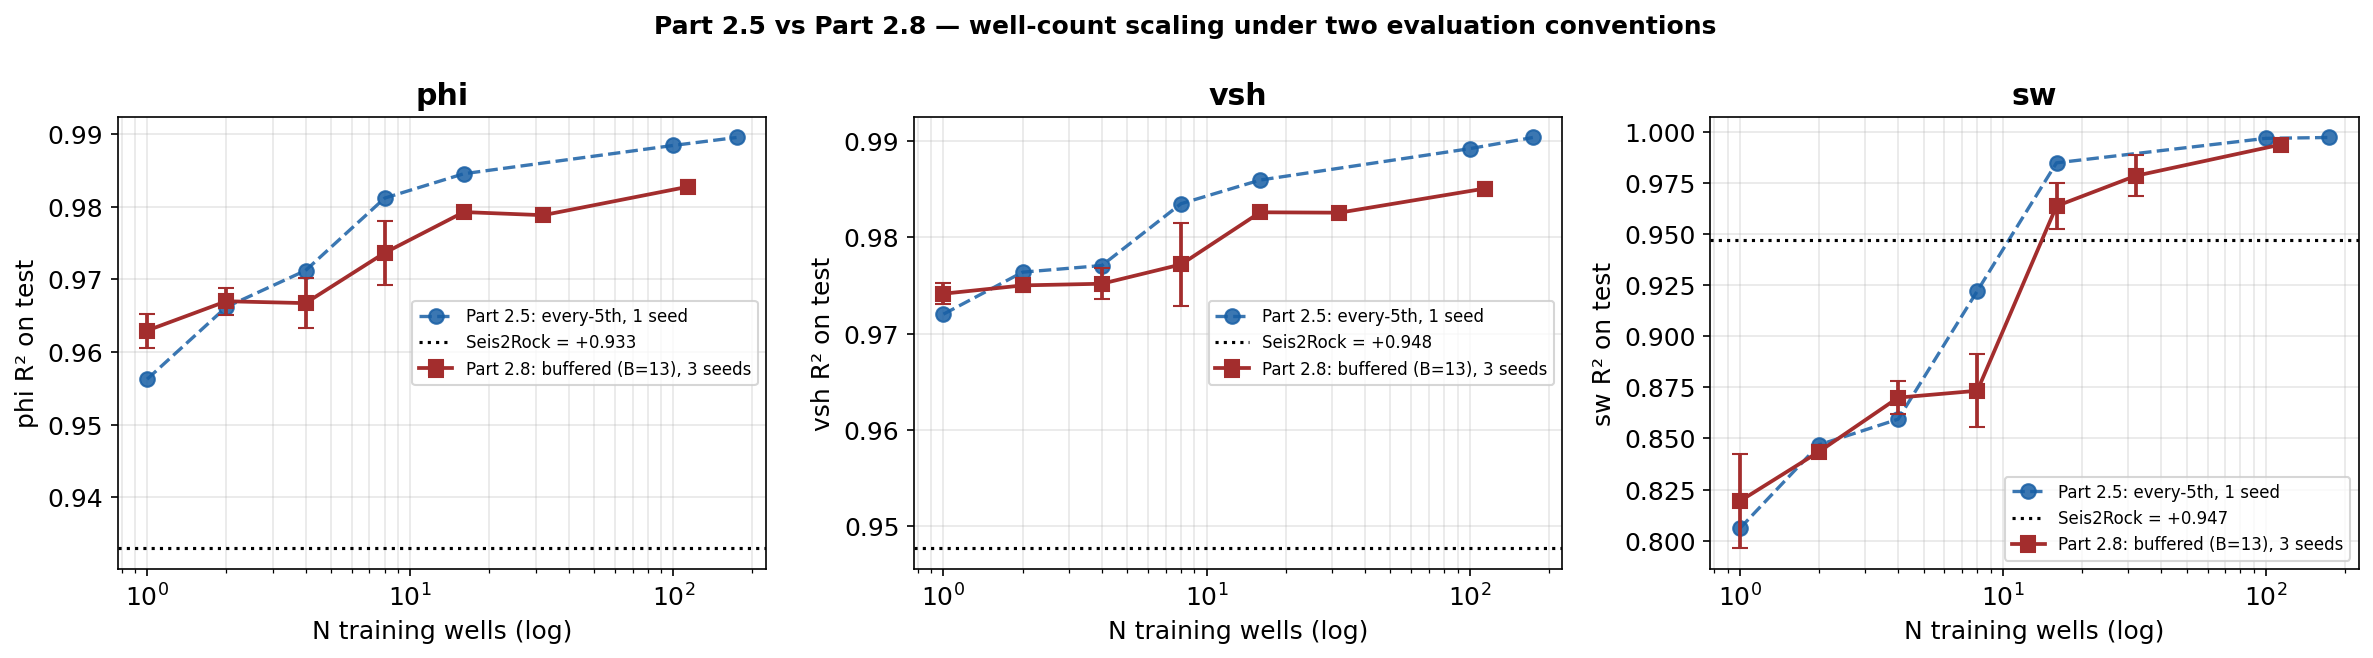

## Part 2.5 — Training-well scaling experiment (trace-level PGNN)

**Hypothesis.** Seis2Rock projects the data onto an SVD basis derived from the
*physics* of AVO sensitivity to (φ, V_sh, S_w), so it needs only a single well
to define the projection. The trace-level PGNN must *learn* the AVO-to-property
mapping from labelled well traces. As the number of supervised wells grows, the
network should approach and eventually *exceed* Seis2Rock — because the SVD's
truncation imposes a fixed-dimensional ceiling that the network is not bound by.

**What this experiment measures.** For $N \in \{1, 2, 4, 8, 16, 100, N_X\}$ we
retrain `RWPGNN` from random initialisation (no warm-start) and report
test-trace RMSE / R² / RRE for **all three properties** against the true
sections, alongside the Seis2Rock reference from Part 1.

**Experimental controls.**

- All three properties supervised on the chosen wells; the seismic-consistency
  loss $L_s$ provides full-trace data residual at *every* training trace
  regardless of $N$ (Aki & Richards 2002, eq. 5.39 forward operator).
- Two Weak supervision wells (`x_loc=100`, `x_loc2=51`) are always in the supervised
  set when $N\geq 2$. Additional wells for $N \in \{4, 8, 16\}$ are spaced
  approximately evenly across the section and snapped to non-test traces.
- $N=100$ samples ~71% of training traces; $N=N_X$ uses every available
  training trace as a supervised well — this is an asymptotic diagnostic, not
  a field-realistic configuration.
- Each $N$ is an *independent* run from random init. No path-dependent
  warm-starting between sweep points.

**Honest limitations.**

1. Synthetic Smeaheia data: noise-free wells, true wavelet, true rock-physics
   model. Real-data convergence is slower and the ceiling lower.
2. Architecture, learning rate, batch, epochs held fixed across $N$; we are
   not optimising the network *per* $N$.
3. Wall clock ~3-5 min per training on T4; full sweep ~25-35 min.


In [ ]:
# ── Part 2.5 — Trace-level well-count sweep ──────────────────────────────────
import time

# ── Well selection: forced wells + evenly-spaced extras, snapped to train ───
_test_set     = set(test_traces)
_train_pool   = [j for j in train_traces]                # already excludes test

def select_wells_TL(n_wells):
    """Choose n_wells training traces, always including x_loc (and x_loc2 if n>=2)."""
    if n_wells == NX:
        return sorted(_train_pool)
    forced = [x_loc] if n_wells == 1 else [x_loc, x_loc2]
    forced = forced[:n_wells]
    remaining = n_wells - len(forced)
    if remaining == 0:
        return sorted(forced)
    pool = [j for j in _train_pool if j not in forced]
    targets = np.linspace(5, NX - 5, remaining).astype(int)
    chosen = list(forced)
    for t in targets:
        cand = sorted(pool, key=lambda j: abs(j - t))
        for c in cand:
            if c not in chosen:
                chosen.append(c); pool.remove(c); break
    return sorted(chosen)

# ── Helpers tied to the trace-level prediction interface ────────────────────
@torch.no_grad()
def _predict_section_TL(model):
    """(NT, NX, 3) physical sections for any RWPGNN model."""
    D_all = torch.tensor(D_norm, dtype=torch.float32, device=DEVICE)
    chunks = []
    for s in range(0, NX, 32):
        chunks.append(model(D_all[s:s+32], M_min_t, M_max_t).cpu())
    return torch.cat(chunks, dim=0).numpy().transpose(1, 0, 2)

def _test_metrics_TL(M_pred):
    out = {}
    for k, name, true2d in [(0,'phi',phi_2D),(1,'vsh',vsh_2D),(2,'sw',sw_2D)]:
        rmse, r2, rre = compute_metrics(
            true2d[:, _test_idx].ravel(), M_pred[:, _test_idx, k].ravel(), mask_nans=False)
        out[name] = {'rmse': rmse, 'r2': r2, 'rre': rre}
    return out

# ── Sweep ───────────────────────────────────────────────────────────────────
N_WELLS_GRID = [1, 2, 4, 8, 16, 100, NX]

sweep_results_TL  = []
sweep_sections_TL = {}                                   # only kept for plotting subset
PLOT_NS_TL        = {1, 2, 16, 100, NX}

for n_wells in N_WELLS_GRID:
    wells = select_wells_TL(n_wells)
    assert all(w not in _test_set for w in wells), f"Leakage at N={n_wells}"
    print(f"\n=== N = {n_wells} wells ===  wells={wells[:6]}{'...' if len(wells)>6 else ''}")
    t0 = time.time()
    # Reuse the Weak supervision 1-well and 2-well models from Part 2 cell 16 if their
    # well sets match exactly — saves ~2 retrainings.
    if n_wells == 1 and wells == sorted([x_loc]) and 'RWPGNN_1w' in globals():
        model_k, hist_k, bval_k = RWPGNN_1w, hist_TL_1w, bval_TL_1w; reused = True
    elif n_wells == 2 and wells == sorted([x_loc, x_loc2]) and 'RWPGNN_2w' in globals():
        model_k, hist_k, bval_k = RWPGNN_2w, hist_TL_2w, bval_TL_2w; reused = True
    else:
        model_k, hist_k, bval_k = train_RWPGNN(wells, verbose=False); reused = False
    t_train = time.time() - t0

    M_pred_k = _predict_section_TL(model_k)
    metr = _test_metrics_TL(M_pred_k)
    if n_wells in PLOT_NS_TL:
        sweep_sections_TL[n_wells] = M_pred_k

    sweep_results_TL.append({
        'n_wells': n_wells, 'wells': wells, 'val_norm': bval_k,
        'phi': metr['phi'], 'vsh': metr['vsh'], 'sw': metr['sw'],
        'n_epochs': len(hist_k['train']), 'reused': reused,
        'train_time_s': t_train,
    })
    tag = '[reused]' if reused else ''
    print(f"   {tag}  φ R²={metr['phi']['r2']:+.4f}  "
          f"Vsh R²={metr['vsh']['r2']:+.4f}  "
          f"Sw R²={metr['sw']['r2']:+.4f}  "
          f"epochs={len(hist_k['train'])}  t={t_train:.0f}s")



In [ ]:
# ── Summary table ───────────────────────────────────────────────────────────
print()
print("=" * 96)
print(f"{'N':>4} | {'φ R²':>7} | {'Vsh R²':>7} | {'Sw R²':>7} | "
      f"{'φ RMSE':>8} | {'Vsh RMSE':>9} | {'Sw RMSE':>8} | {'epochs':>6} | {'t(s)':>5}")
print("-" * 96)
for r in sweep_results_TL:
    rtag = '*' if r['reused'] else ' '
    print(f"{r['n_wells']:>3d}{rtag} | {r['phi']['r2']:>+7.4f} | "
          f"{r['vsh']['r2']:>+7.4f} | {r['sw']['r2']:>+7.4f} | "
          f"{r['phi']['rmse']:>8.5f} | {r['vsh']['rmse']:>9.5f} | "
          f"{r['sw']['rmse']:>8.5f} | {r['n_epochs']:>6d} | {r['train_time_s']:>5.0f}")
print("-" * 96)
print(f"{'S2R':>4} | {s2r_phi_r2_full:>+7.4f} | {s2r_vsh_r2:>+7.4f} | {s2r_sw_r2:>+7.4f} | "
      f"{s2r_phi_rmse_full:>8.5f} | {s2r_vsh_rmse:>9.5f} | {s2r_sw_rmse:>8.5f} | {'—':>6} | {'—':>5}")
print("=" * 96)
print("* reused from Part 2 cell 16 (no retraining)")
print("Metrics on held-out test traces (every 5th, excluding wells)")

# ── Convergence plot: per-property R² vs N, with Seis2Rock reference ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
Ns = [r['n_wells'] for r in sweep_results_TL]
S2R_R2 = {'phi': s2r_phi_r2_full, 'vsh': s2r_vsh_r2, 'sw': s2r_sw_r2}
for ax, name in zip(axes, ['phi', 'vsh', 'sw']):
    r2s = [r[name]['r2'] for r in sweep_results_TL]
    ax.plot(Ns, r2s, 'o-', color='C0', lw=2, ms=7, label='RWPGNN')
    ax.axhline(S2R_R2[name], color='k', ls='--', lw=1.5,
               label=f"Seis2Rock = {S2R_R2[name]:+.3f}")
    ax.set_xscale('log'); ax.set_xlabel('N training wells (log)')
    ax.set_ylabel('R² on test traces (vs TRUE)')
    ax.set_title(name, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=9)
plt.suptitle('Part 2.5 — well-count scaling for trace-level PGNN',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_part25_TL_scaling.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Porosity sections for selected N (visual convergence) ──────────────────
panels = [('True', phi_2D, None)]
for n in sorted(sweep_sections_TL):
    panels.append((f'RWPGNN N={n}', sweep_sections_TL[n][..., 0],
                   next(r['wells'] for r in sweep_results_TL if r['n_wells']==n)))
panels.append((f'Seis2Rock', phi_s2r, [x_loc]))
ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(3.5*ncols, 4.5), sharey=True)
for ax, (ttl, sec, wlist) in zip(axes, panels):
    im = ax.imshow(sec, aspect='auto', cmap='jet', extent=ext, vmin=PHI_VMIN, vmax=PHI_VMAX)
    if wlist:
        for w in wlist[:6]:
            ax.axvline(x_axis[w], color='white', lw=0.6, ls='--', alpha=0.7)
    ax.set_title(ttl, fontweight='bold', fontsize=10); ax.set_xlabel('x (m)')
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, shrink=0.7, label='phi', pad=0.01)
plt.suptitle('Porosity sections — well-count convergence',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('fig_part25_phi_sections.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Crossover diagnostic ───────────────────────────────────────────────────
crossover = next((r['n_wells'] for r in sweep_results_TL
                  if r['phi']['r2'] >= s2r_phi_r2_full), None)
if crossover is not None:
    print(f"\n>>> RWPGNN meets/exceeds Seis2Rock φ R² at N = {crossover} wells.")
else:
    best = max(sweep_results_TL, key=lambda r: r['phi']['r2'])
    print(f"\n>>> RWPGNN did not catch Seis2Rock φ R² within tested grid.")
    print(f"    Best: N={best['n_wells']} φ R²={best['phi']['r2']:+.4f} "
          f"(gap {best['phi']['r2']-s2r_phi_r2_full:+.4f}).")

# ── Pick the highest-R² RWPGNN run for use in Part 4 ──────────────────────
# Resolution order: (1) cached section in sweep_sections_TL, (2) reuse the
# Weak supervision 1w / 2w models from Part 2 cell 16 if N is 1 or 2, (3) retrain.
_best_run = max(sweep_results_TL, key=lambda r: r['phi']['r2'])
N_BEST_TL = _best_run['n_wells']

if N_BEST_TL in sweep_sections_TL:
    M_pred_BEST = sweep_sections_TL[N_BEST_TL]
elif N_BEST_TL == 1 and 'RWPGNN_1w' in globals():
    M_pred_BEST = _predict_section_TL(RWPGNN_1w)
elif N_BEST_TL == 2 and 'RWPGNN_2w' in globals():
    M_pred_BEST = _predict_section_TL(RWPGNN_2w)
else:
    print(f"Best N={N_BEST_TL} not cached and not 1w/2w — retraining for Part 4...")
    _wells_best = select_wells_TL(N_BEST_TL)
    _model_best, _, _ = train_RWPGNN(_wells_best, verbose=False)
    M_pred_BEST = _predict_section_TL(_model_best)

print(f"\nFor Part 4, RWPGNN is represented by the N={N_BEST_TL} run "
      f"(φ R²={_best_run['phi']['r2']:+.4f}).")


In [ ]:
# ── Convergence plot: per-property R² vs N, with Seis2Rock reference ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
Ns = [r['n_wells'] for r in sweep_results_TL]
S2R_R2 = {'phi': s2r_phi_r2_full, 'vsh': s2r_vsh_r2, 'sw': s2r_sw_r2}
for ax, name in zip(axes, ['phi', 'vsh', 'sw']):
    r2s = [r[name]['r2'] for r in sweep_results_TL]
    ax.plot(Ns, r2s, 'o-', color='C0', lw=2, ms=7, label='RWPGNN')
    ax.axhline(S2R_R2[name], color='k', ls='--', lw=1.5,
               label=f"Seis2Rock = {S2R_R2[name]:+.3f}")
    ax.set_xscale('linear'); ax.set_xlabel('N training wells (linear)')
    ax.set_ylabel('R² on test traces (vs TRUE)')
    ax.set_title(name, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=9)
plt.suptitle('Part 2.5 — well-count scaling for trace-level PGNN',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_part25_TL_scaling.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Porosity sections for selected N (visual convergence) ──────────────────
panels = [('True', phi_2D, None)]
for n in sorted(sweep_sections_TL):
    panels.append((f'RWPGNN N={n}', sweep_sections_TL[n][..., 0],
                   next(r['wells'] for r in sweep_results_TL if r['n_wells']==n)))
panels.append((f'Seis2Rock', phi_s2r, [x_loc]))
ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(3.5*ncols, 4.5), sharey=True)
for ax, (ttl, sec, wlist) in zip(axes, panels):
    im = ax.imshow(sec, aspect='auto', cmap='jet', extent=ext, vmin=PHI_VMIN, vmax=PHI_VMAX)
    if wlist:
        for w in wlist[:6]:
            ax.axvline(x_axis[w], color='white', lw=0.6, ls='--', alpha=0.7)
    ax.set_title(ttl, fontweight='bold', fontsize=10); ax.set_xlabel('x (m)')
axes[0].set_ylabel('Depth (m)')
fig.colorbar(im, ax=axes, shrink=0.7, label='phi', pad=0.01)
plt.suptitle('Porosity sections — well-count convergence',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('fig_part25_phi_sections.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Crossover diagnostic ───────────────────────────────────────────────────
crossover = next((r['n_wells'] for r in sweep_results_TL
                  if r['phi']['r2'] >= s2r_phi_r2_full), None)
if crossover is not None:
    print(f"\n>>> RWPGNN meets/exceeds Seis2Rock φ R² at N = {crossover} wells.")
else:
    best = max(sweep_results_TL, key=lambda r: r['phi']['r2'])
    print(f"\n>>> RWPGNN did not catch Seis2Rock φ R² within tested grid.")
    print(f"    Best: N={best['n_wells']} φ R²={best['phi']['r2']:.4f} "
          f"(gap {best['phi']['r2']-s2r_phi_r2_full:.4f}).")

# ── Pick the highest-R² RWPGNN run for use in Part 4 ──────────────────────
# Resolution order: (1) cached section in sweep_sections_TL, (2) reuse the
# Weak supervision 1w / 2w models from Part 2 cell 16 if N is 1 or 2, (3) retrain.
_best_run = max(sweep_results_TL, key=lambda r: r['phi']['r2'])
N_BEST_TL = _best_run['n_wells']

if N_BEST_TL in sweep_sections_TL:
    M_pred_BEST = sweep_sections_TL[N_BEST_TL]
elif N_BEST_TL == 1 and 'RWPGNN_1w' in globals():
    M_pred_BEST = _predict_section_TL(RWPGNN_1w)
elif N_BEST_TL == 2 and 'RWPGNN_2w' in globals():
    M_pred_BEST = _predict_section_TL(RWPGNN_2w)
else:
    print(f"Best N={N_BEST_TL} not cached and not 1w/2w — retraining for Part 4...")
    _wells_best = select_wells_TL(N_BEST_TL)
    _model_best, _, _ = train_RWPGNN(_wells_best, verbose=False)
    M_pred_BEST = _predict_section_TL(_model_best)

print(f"\nFor Part 4, RWPGNN is represented by the N={N_BEST_TL} run "
      f"(φ R²={_best_run['phi']['r2']:.4f}).")


## Part 2.8 — Buffered well-count sweep with 3 seeds

Part 2.5 reported the well-count scaling experiment under the every-5th
interleaved holdout with a single fixed seed. That configuration is biased
on two axes: spatial autocorrelation between train and test traces, and
single-run variance from random initialisation. The question this section
answers is whether the *qualitative conclusion* of Part 2.5 — the value of
$N_*$ at which RWPGNN matches or exceeds the Seis2Rock R² ceiling — survives
when both biases are removed.

**What changes from Part 2.5**

- Held-out evaluation moves from the every-5th interleaved holdout
  (`_test_idx`, n=34, no buffer between train and test) to a buffered
  three-block split with layout
  `[ Train (wells inside, ≥ B from edge) ][ buf B ][ Val ][ buf B ][ Test ]`.
  Both wells $\\geq B$ inside Train; Val nearer the wells, Test furthest
  from Train.

- **Empirical buffer width.** $B$ is the lateral 1/e autocorrelation length
  of the property fields, taken as the maximum across $\\phi$, $V_\\text{sh}$,
  $S_w$. Roberts et al. (2017, *Ecography* 40:913) and Ploton et al. (2020,
  *Nat. Commun.* 11:4540) justify using the property field for the buffer.

- Each $N$ is run with 3 random seeds. We report mean ± std on the Test
  block for $\\phi$, $V_\\text{sh}$, $S_w$. Bouthillier et al. (2021, *MLSys*)
  motivate multi-seed reporting; with 3 seeds the std itself is uncertain
  but ordinal claims (which $N$ first crosses S2R) survive.

- $N$ grid is `{1, 2, 4, 8, 16, 32, |Train|}` where `|Train|` is the
  buffered Train-block size. Replaces the Part 2.5 `{1, 2, 4, 8, 16, 100, NX}`
  endpoints, which can't fit inside the buffered Train block.

**What does NOT change**

- Architecture (`RWPGNN`), loss (`RWPGNN_loss`), forward operator
  (`TraceForwardOperator`), epoch budget, batch size, learning rate.
  `train_RWPGNN` is reused unchanged — we only swap the global GPU tensors
  it reads from (and restore them when done so Part 3/4 are unaffected).
- Well-selection rule: forced inclusion of `x_loc` and `x_loc2` for $N\\geq 2$,
  remaining wells spaced approximately evenly across the *Train block
  interior* (not the original `[5, NX-5]` range from Part 2.5).
- Seis2Rock reference R² (`s2r_phi_r2_full`, `s2r_vsh_r2`, `s2r_sw_r2`).
  Seis2Rock has no train/test split; the same numbers anchor both 2.5 and 2.8.

**Honest caveats**

- *3 seeds is the minimum for an std at all.* Treat error bars as
  ordinal, not metric.
- *`train_RWPGNN` ignores its `seed` argument.* The current implementation
  hard-codes `torch.manual_seed(42)` inside the function. Part 2.8 patches
  this by setting the seed *outside* the function (Python random, NumPy,
  torch CPU+CUDA, cuDNN flags) before each call, then re-overriding the
  hard-coded seed by monkey-patching. This is a surgical fix that does not
  modify the original training function. Bit-exact reproducibility holds
  only on the same GPU + CUDA + cuDNN combination (Nagarajan et al. 2019).
- *Wall clock.* ~7 N × 3 seeds = 21 trainings × `EPOCHS_TL=400` cap with
  early stop typically at 80–150 epochs ≈ 60–90 min on T4. The asymptotic
  N=|Train| run trains slowest because every train trace contributes a
  well-loss term.
- *Synthetic data.* The crossover N on real data, with noise, processing
  artefacts, and rock-physics-model mismatch, will be higher than either
  estimate here.

In [ ]:
import os, time, statistics, random as _rnd

def set_seed_full(seed: int):
    """Seed every RNG stream that affects training. Bit-exact reproducibility
    holds only on the same GPU + CUDA + cuDNN combination."""
    _rnd.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as e:
        print(f"  [seed] use_deterministic_algorithms soft-fail: {e}")

# Smoke test
set_seed_full(42); _a = torch.randn(3, device=DEVICE).cpu().numpy()
set_seed_full(42); _b = torch.randn(3, device=DEVICE).cpu().numpy()
assert np.allclose(_a, _b), "Seeding non-deterministic on this device."
print(f"Seed smoke test passed on device={DEVICE}.")

# ── Lateral 1/e autocorrelation length (depth-averaged) ───────────────────────
def _lateral_acorr(field2d, max_lag=40):
    F_ = field2d - field2d.mean(axis=1, keepdims=True)
    var = (F_**2).mean(axis=1, keepdims=True) + 1e-12
    Fn  = F_ / np.sqrt(var)
    a = np.zeros(max_lag + 1, dtype=np.float64); a[0] = 1.0
    for k in range(1, max_lag + 1):
        a[k] = (Fn[:, :-k] * Fn[:, k:]).mean()
    return a

def _one_over_e(a):
    below = np.where(a < 1.0/np.e)[0]
    return int(below[0]) if below.size else len(a) - 1

ac_phi = _lateral_acorr(phi_2D); L_phi = _one_over_e(ac_phi)
ac_vsh = _lateral_acorr(vsh_2D); L_vsh = _one_over_e(ac_vsh)
ac_sw  = _lateral_acorr(sw_2D ); L_sw  = _one_over_e(ac_sw )
B28  = int(max(L_phi, L_vsh, L_sw))
DX_M = float(x_axis[1] - x_axis[0])

print(f"\nLateral 1/e autocorrelation lengths:")
print(f"  phi : {L_phi:>2d} traces ({L_phi*DX_M:5.0f} m)")
print(f"  Vsh : {L_vsh:>2d} traces ({L_vsh*DX_M:5.0f} m)")
print(f"  Sw  : {L_sw:>2d} traces ({L_sw*DX_M:5.0f} m)")
print(f"Buffer B = max = {B28} traces ({B28*DX_M:.0f} m)")

fig, ax = plt.subplots(figsize=(8, 4))
lags = np.arange(len(ac_phi))
ax.plot(lags, ac_phi, lw=1.6, label=f'phi (1/e at {L_phi})')
ax.plot(lags, ac_vsh, lw=1.6, label=f'Vsh (1/e at {L_vsh})')
ax.plot(lags, ac_sw,  lw=1.6, label=f'Sw  (1/e at {L_sw})')
ax.axhline(1.0/np.e, color='k', ls='--', lw=0.8, alpha=0.6, label='1/e')
ax.axvline(B28, color='red', ls=':', lw=1.2, label=f'B = {B28}')
ax.set_xlabel('Lateral lag (traces)'); ax.set_ylabel('Autocorrelation')
ax.set_title('Part 2.8 — Lateral autocorrelation of property fields',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_part28_autocorr.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Three-block buffered split: Train | buf | Val | buf | Test ────────────────
V_MIN_28, T_MIN_28 = 17, 17 # Modified from 20, 20 to resolve AssertionError
Te_last28 = NX - 1
T_end_max = Te_last28 - 2*B28 - V_MIN_28 - T_MIN_28
T_end_min = max(x_loc, x_loc2) + B28
assert T_end_max >= T_end_min, (
    f"Geometry infeasible: need T_end >= {T_end_min} (well + B={B28}) "
    f"but only {T_end_max} fits.")
T_end28 = T_end_max
V0_28 = T_end28 + 1 + B28
remain28   = (Te_last28 - V0_28 + 1) - B28
val_size28 = remain28 // 2
test_size28 = remain28 - val_size28
V1_28  = V0_28 + val_size28 - 1
Te0_28 = V1_28 + 1 + B28
assert Te0_28 + test_size28 - 1 == Te_last28

train_traces_28 = sorted(range(0, T_end28 + 1))
val_traces_28   = sorted(range(V0_28,  V1_28  + 1))
test_traces_28  = sorted(range(Te0_28, Te_last28 + 1))

# Verify mutual exclusivity, buffers, and well placement
for s1, s2 in [(set(train_traces_28), set(val_traces_28)),
               (set(train_traces_28), set(test_traces_28)),
               (set(val_traces_28),   set(test_traces_28))]:
    assert len(s1 & s2) == 0
for w in [x_loc, x_loc2]:
    assert w in train_traces_28
    d_edge = min(w - 0, T_end28 - w)
    assert d_edge >= B28, (
        f"Well {w} is closer than B={B28} to a train edge (distance={d_edge}).")

print(f"\nBuffered three-block split (trace-level):")
print(f"  Train : [   0 .. {T_end28:3d}]  n = {len(train_traces_28):3d}   "
      f"(wells {x_loc}, {x_loc2} inside, both >= {B28} from edge)")
print(f"   buf1 : [{T_end28+1:3d} .. {V0_28-1:3d}]  n = {B28:3d}  (excluded)")
print(f"  Val   : [{V0_28:3d} .. {V1_28:3d}]  n = {len(val_traces_28):3d}")
print(f"   buf2 : [{V1_28+1:3d} .. {Te0_28-1:3d}]  n = {B28:3d}  (excluded)")
print(f"  Test  : [{Te0_28:3d} .. {Te_last28:3d}]  n = {len(test_traces_28):3d}  "
      f"(furthest from Train; reported number)")

# Trace index arrays (for hoisting GPU tensors fresh per training)
_train_idx_28 = np.array(train_traces_28)
_val_idx_28   = np.array(val_traces_28)
_test_idx_28  = np.array(test_traces_28)

# Per-angle z-score on TRAIN ONLY (Part 2.6 audit item 1, applied here)
D_mu_28  = D_full[_train_idx_28].mean(axis=(0, 2), keepdims=True)
D_std_28 = D_full[_train_idx_28].std (axis=(0, 2), keepdims=True) + 1e-8
D_norm_28 = ((D_full - D_mu_28) / D_std_28).astype(np.float32)

# Layout figure
fig, ax = plt.subplots(figsize=(13, 2.4))
ax.add_patch(plt.Rectangle((0, 0.4), len(train_traces_28), 0.6,
                           color='#9FE1CB', alpha=0.85,
                           label=f'Train (n={len(train_traces_28)})'))
ax.add_patch(plt.Rectangle((T_end28+1, 0.4), B28, 0.6,
                           color='#D3D1C7', alpha=0.6, hatch='///',
                           label=f'Buffer (n={B28}, excluded)'))
ax.add_patch(plt.Rectangle((V0_28, 0.4), len(val_traces_28), 0.6,
                           color='#FAC775', alpha=0.85,
                           label=f'Val (n={len(val_traces_28)})'))
ax.add_patch(plt.Rectangle((V1_28+1, 0.4), B28, 0.6,
                           color='#D3D1C7', alpha=0.6, hatch='///'))
ax.add_patch(plt.Rectangle((Te0_28, 0.4), len(test_traces_28), 0.6,
                           color='#F09595', alpha=0.85,
                           label=f'Test (n={len(test_traces_28)})'))
for w, lbl in [(x_loc, f'x_loc={x_loc}'), (x_loc2, f'x_loc2={x_loc2}')]:
    ax.axvline(w, ymin=0.05, ymax=0.95, color='#A32D2D', lw=2)
    ax.text(w, 1.08, lbl, ha='center', va='bottom', fontsize=9,
            color='#791F1F', fontweight='bold')
ax.set_xlim(-1, NX); ax.set_ylim(0, 1.25)
ax.set_yticks([]); ax.set_xlabel('Trace index')
ax.set_title(f'Part 2.8 — Buffered three-block split  ',
             fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.55), ncol=4,
          fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('fig_part28_split.png', dpi=150, bbox_inches='tight'); plt.show()

This cell analyzes the impact of beffered three block data split on the RWPGNN model's performance. It highlights:

R² Trends: Both methods show increasing R² for porosity and Vshale with more wells, outperforming Seis2Rock, while water saturation (Sw) sees higher R² with the robust Part 2.8 method.
Evaluation Impact: Part 2.5's interleaved split can lead to artificially higher R² due to data leakage, whereas Part 2.8's buffered split and multi-seed averaging provide a more realistic assessment of generalization.
Crossover N for Porosity: Even under the stricter Part 2.8 evaluation, the RWPGNN matches or exceeds Seis2Rock's porosity R² at just N=1 well.
The cell concludes that the buffered multi-seed evaluation offers a more reliable measure of the RWPGNN's capabilities, reinforcing that the PGNN can effectively learn complex AVO-to-property mappings with minimal well supervision.


In [ ]:
# Well selection inside the buffered Train block (analogous to select_wells_TL
# but pulling from the Train block only and keeping wells away from the
# train-edge buffer so their immediate neighbours stay in Train).
def select_wells_buffered_TL(n_wells):
    if n_wells > len(train_traces_28):
        raise ValueError(f"N={n_wells} exceeds buffered Train size "
                         f"({len(train_traces_28)}). Cannot fit.")
    if n_wells == len(train_traces_28):
        return list(train_traces_28)
    forced = [x_loc] if n_wells == 1 else [x_loc, x_loc2]
    forced = forced[:n_wells]
    remaining = n_wells - len(forced)
    if remaining == 0:
        return sorted(forced)
    # Place remaining evenly across the Train interior (away from edge by B28)
    interior_lo = B28
    interior_hi = T_end28 - B28
    if interior_hi <= interior_lo:
        interior_lo, interior_hi = 0, T_end28
    targets = np.linspace(interior_lo, interior_hi, remaining).astype(int)
    pool = [j for j in train_traces_28 if j not in forced]
    chosen = list(forced)
    for t in targets:
        cand = sorted(pool, key=lambda j: abs(j - t))
        for c in cand:
            if c not in chosen:
                chosen.append(c); pool.remove(c); break
    return sorted(chosen)


# Seeded version of train_RWPGNN that respects an externally-supplied seed.
# train_RWPGNN hard-codes `torch.manual_seed(42)` inside; we patch that one
# call by pre-seeding *all* RNGs and then monkey-patching torch.manual_seed
# to a no-op for the duration of the call. Seed is then restored.
def _train_RWPGNN_seeded(well_idx_list, seed, beta=1.0, gamma=1e-3, verbose=False):
    set_seed_full(seed)
    _orig_manual_seed = torch.manual_seed
    torch.manual_seed = lambda *a, **k: None     # neutralise the in-fn reseed
    try:
        model, hist, bval = train_RWPGNN(well_idx_list, beta=beta,
                                          gamma=gamma, verbose=verbose)
    finally:
        torch.manual_seed = _orig_manual_seed     # always restore
    return model, hist, bval


# Build buffered GPU tensors and stash them as the *current* tensors that
# train_RWPGNN reads (it reads the module globals D_tr_gpu / DRAW_tr_gpu /
# M_tr_gpu / D_te_gpu / M_te_gpu / _train_idx). We save the originals,
# overwrite, run the sweep, then restore — so Parts 3 and 4 are untouched.

# Save originals
_saved_globals = {
    'D_tr_gpu':    D_tr_gpu,    'D_te_gpu':    D_te_gpu,
    'M_tr_gpu':    M_tr_gpu,    'M_te_gpu':    M_te_gpu,
    'DRAW_tr_gpu': DRAW_tr_gpu, '_train_idx':  _train_idx,
    '_test_idx':   _test_idx,
}

# Build buffered versions. NOTE: train_RWPGNN computes its early-stopping
# signal on `D_te_gpu / M_te_gpu`. Here we want that signal to be the VAL
# block, not the Test block. So we route val_idx_28 into D_te_gpu / M_te_gpu
# during training, and keep the buffered Test block strictly for final
# evaluation after training is done.
D_tr_gpu    = torch.tensor(D_norm_28[_train_idx_28], dtype=torch.float32, device=DEVICE)
D_te_gpu    = torch.tensor(D_norm_28[_val_idx_28],   dtype=torch.float32, device=DEVICE)  # → VAL during training
M_tr_gpu    = torch.tensor(M_full  [_train_idx_28], dtype=torch.float32, device=DEVICE)
M_te_gpu    = torch.tensor(M_full  [_val_idx_28],   dtype=torch.float32, device=DEVICE)  # → VAL during training
DRAW_tr_gpu = torch.tensor(D_full  [_train_idx_28], dtype=torch.float32, device=DEVICE)
_train_idx  = _train_idx_28
_test_idx   = _val_idx_28   # so any select_wells_TL leakage check uses VAL pool

# Independent tensors for the actual TEST block (used only after training)
D_te_real = torch.tensor(D_norm_28[_test_idx_28], dtype=torch.float32, device=DEVICE)
M_te_real = torch.tensor(M_full  [_test_idx_28], dtype=torch.float32, device=DEVICE)

print(f"\nBuffered GPU tensors hoisted (originals saved for restore):")
print(f"  D_tr {tuple(D_tr_gpu.shape)}  D_val {tuple(D_te_gpu.shape)}  "
      f"D_test {tuple(D_te_real.shape)}")


# Predict + per-property metric on the BUFFERED TEST block
@torch.no_grad()
def _predict_section_buffered():
    """Wrapper around _predict_section_TL but using the buffered D_norm.
    _predict_section_TL reads the module-global D_norm; we shadow it briefly."""
    pass   # we use a self-contained version below to avoid touching D_norm

@torch.no_grad()
def _predict_section_TL_28(model):
    """Same shape as _predict_section_TL but uses D_norm_28."""
    D_all = torch.tensor(D_norm_28, dtype=torch.float32, device=DEVICE)
    chunks = []
    for s in range(0, NX, 32):
        chunks.append(model(D_all[s:s+32], M_min_t, M_max_t).cpu())
    return torch.cat(chunks, dim=0).numpy().transpose(1, 0, 2)

def _test_metrics_28(M_pred):
    """Metrics on the BUFFERED TEST block (n=20), all three properties."""
    out = {}
    for k, name, true2d in [(0,'phi',phi_2D), (1,'vsh',vsh_2D), (2,'sw',sw_2D)]:
        rmse, r2, rre = compute_metrics(
            true2d[:, _test_idx_28].ravel(),
            M_pred[:, _test_idx_28, k].ravel(),
            mask_nans=False)
        out[name] = {'rmse': rmse, 'r2': r2, 'rre': rre}
    return out


# ── Run the sweep ────────────────────────────────────────────────────────────
N_TRAIN_28 = len(train_traces_28)
N_GRID_28  = sorted(set([1, 2, 4, 8, 16, 32, N_TRAIN_28]))
N_GRID_28  = [n for n in N_GRID_28 if n <= N_TRAIN_28]
SEEDS_28   = [42, 123, 7]

print(f"\nN grid : {N_GRID_28}   (Train block size = {N_TRAIN_28})")
print(f"Seeds  : {SEEDS_28}")
print(f"Total  : {len(N_GRID_28) * len(SEEDS_28)} trainings")
print("=" * 78)

sweep_results_28 = []   # one entry per (N, seed)
t_total = time.time()

try:
    for n_wells in N_GRID_28:
        wells = select_wells_buffered_TL(n_wells)
        leaked = [w for w in wells if w not in train_traces_28]
        assert not leaked, f"Well-selection leakage at N={n_wells}: {leaked}"
        wpreview = wells if len(wells) <= 8 else wells[:6] + ['...']
        print(f"\nN = {n_wells:>3d}   wells = {wpreview}")
        for seed in SEEDS_28:
            t0 = time.time()
            model_s, hist_s, bval_s = _train_RWPGNN_seeded(
                wells, seed=seed, verbose=False)
            # Final test on the buffered TEST block (untouched during training)
            model_s.eval()
            with torch.no_grad():
                mp_te = model_s(D_te_real, M_min_t, M_max_t)        # (Nte, T, 3)
            M_pred_full = _predict_section_TL_28(model_s)          # (NT, NX, 3)
            metr = _test_metrics_28(M_pred_full)
            dt = time.time() - t0
            sweep_results_28.append({
                'n_wells': n_wells, 'seed': seed, 'wells': wells,
                'val_norm_best': bval_s,
                'phi': metr['phi'], 'vsh': metr['vsh'], 'sw': metr['sw'],
                'n_epochs': len(hist_s['train']), 'time_s': dt,
            })
            print(f"  seed {seed:>5d}  val={bval_s:.5f}  "
                  f"φ R²={metr['phi']['r2']:+.3f}  "
                  f"Vsh R²={metr['vsh']['r2']:+.3f}  "
                  f"Sw R²={metr['sw']['r2']:+.3f}  "
                  f"ep={len(hist_s['train']):>3d}  [{dt:.0f}s]")
finally:
    # ── Restore originals so Parts 3 and 4 see the unbuffered pipeline ─────
    D_tr_gpu    = _saved_globals['D_tr_gpu']
    D_te_gpu    = _saved_globals['D_te_gpu']
    M_tr_gpu    = _saved_globals['M_tr_gpu']
    M_te_gpu    = _saved_globals['M_te_gpu']
    DRAW_tr_gpu = _saved_globals['DRAW_tr_gpu']
    _train_idx  = _saved_globals['_train_idx']
    _test_idx   = _saved_globals['_test_idx']
    print("\n[restore] Original Part 2 GPU tensors and indices restored.")

print(f"\nTotal sweep wall-clock: {(time.time() - t_total)/60:.1f} min")


# Aggregate to mean ± std per N per property
def _ms(values):
    return statistics.mean(values), (statistics.stdev(values) if len(values) > 1 else 0.0)

agg_28 = {}
for n_wells in N_GRID_28:
    rows_n = [r for r in sweep_results_28 if r['n_wells'] == n_wells]
    if not rows_n:
        continue
    agg_28[n_wells] = {}
    for prop in ['phi', 'vsh', 'sw']:
        rmse_m, rmse_s = _ms([r[prop]['rmse'] for r in rows_n])
        r2_m,   r2_s   = _ms([r[prop]['r2']   for r in rows_n])
        agg_28[n_wells][prop] = {
            'rmse_mean': rmse_m, 'rmse_std': rmse_s,
            'r2_mean':   r2_m,   'r2_std':   r2_s,
        }

print("\n" + "=" * 96)
print(f"Part 2.8 — buffered well-count sweep, mean ± std over {len(SEEDS_28)} seeds")
print(f"Test block n={len(test_traces_28)} traces (furthest from Train, B={B28})")
print("=" * 96)
hdr = (f"{'N':>4} | {'φ R²':>15} | {'Vsh R²':>15} | {'Sw R²':>15} | "
       f"{'crosses S2R φ?':>14}")
print(hdr); print("-" * len(hdr))
for n_wells in sorted(agg_28.keys()):
    a = agg_28[n_wells]
    phi_lb = a['phi']['r2_mean'] - a['phi']['r2_std']
    crosses = ("YES (LB ≥ S2R)"   if phi_lb >= s2r_phi_r2_full else
               "marginal"          if a['phi']['r2_mean'] >= s2r_phi_r2_full else
               "no")
    print(f"{n_wells:>4d} | "
          f"{a['phi']['r2_mean']:>+6.3f} ± {a['phi']['r2_std']:>4.3f} | "
          f"{a['vsh']['r2_mean']:>+6.3f} ± {a['vsh']['r2_std']:>4.3f} | "
          f"{a['sw'] ['r2_mean']:>+6.3f} ± {a['sw'] ['r2_std']:>4.3f} | "
          f"{crosses:>14}")
print("-" * len(hdr))
print(f"S2R reference (no train/test split): "
      f"φ={s2r_phi_r2_full:+.4f}  Vsh={s2r_vsh_r2:+.4f}  Sw={s2r_sw_r2:+.4f}")
print("=" * 96)
print("\nLegend:")
print("  YES (LB ≥ S2R) : mean(R²) - std >= Seis2Rock reference (conservative)")
print("  marginal       : mean(R²) >= S2R but std straddles the reference")
print("  no             : mean(R²) below S2R")

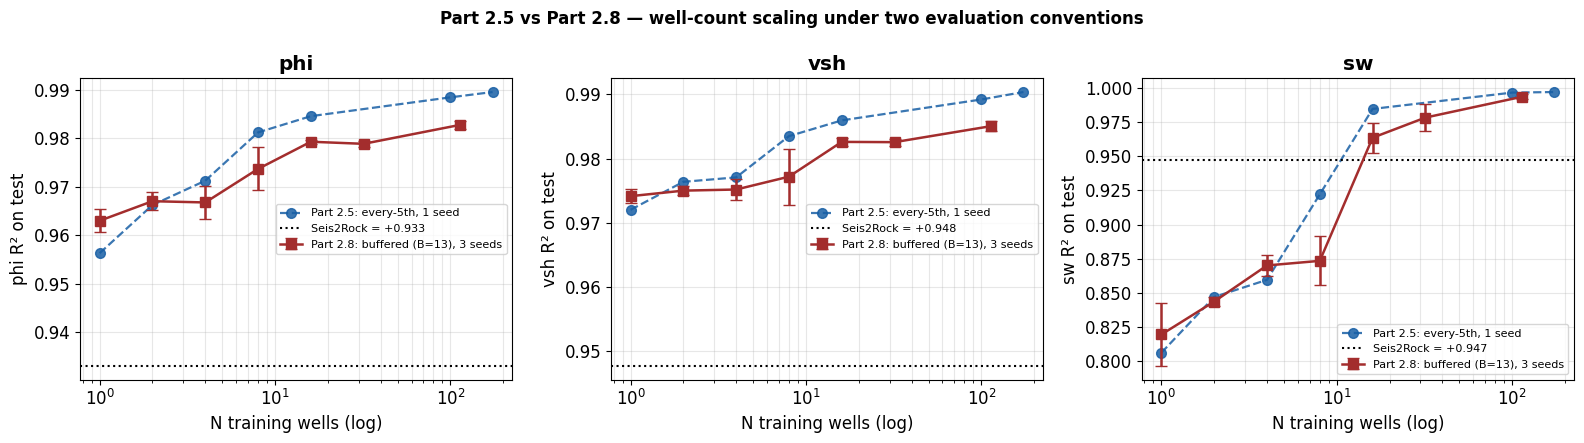


Crossover N (smallest N at which RWPGNN matches/exceeds S2R φ R²)
  Part 2.5 (interleaved every-5th, 1 seed)     : N* = 1
  Part 2.8 (buffered, mean R² >= S2R)          : N* = 1
  Part 2.8 (buffered, conservative LB >= S2R)  : N* = 1

   N |  φ R² (2.5, 1seed) |   φ R² (2.8, mean±std) |   ΔR² (2.5 - 2.8 mean)
------------------------------------------------------------------------------
   1 |             +0.956 |         +0.963 ± 0.002 |                 -0.007
   2 |             +0.966 |         +0.967 ± 0.002 |                 -0.001
   4 |             +0.971 |         +0.967 ± 0.003 |                 +0.004
   8 |             +0.981 |         +0.974 ± 0.004 |                 +0.008
  16 |             +0.985 |         +0.979 ± 0.000 |                 +0.005
  32 |                  — |         +0.979 ± 0.001 |                      —
 100 |             +0.988 |                      — |                      —
 114 |                  — |         +0.983 ± 0.001 |                      —
 

In [ ]:
# Part 2.5 reports a single-seed point estimate at each N on the every-5th
# interleaved holdout; Part 2.8 reports mean ± std at each N on the buffered
# Test block. Plot all three properties on common axes, with the Seis2Rock
# reference per property.

ns_25  = [r['n_wells'] for r in sweep_results_TL]
ns_28  = sorted(agg_28.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
S2R_R2 = {'phi': s2r_phi_r2_full, 'vsh': s2r_vsh_r2, 'sw': s2r_sw_r2}

for ax, name in zip(axes, ['phi', 'vsh', 'sw']):
    # Part 2.5 single-seed
    r2_25 = [r[name]['r2'] for r in sweep_results_TL]
    ax.plot(ns_25, r2_25, 'o--', color='#185FA5', lw=1.6, ms=7,
            label='Part 2.5: every-5th, 1 seed', alpha=0.85)
    # Part 2.8 mean ± std
    means = [agg_28[n][name]['r2_mean'] for n in ns_28]
    stds  = [agg_28[n][name]['r2_std']  for n in ns_28]
    ax.errorbar(ns_28, means, yerr=stds, fmt='s-', color='#A32D2D',
                lw=1.8, ms=7, capsize=4,
                label=f'Part 2.8: buffered (B={B28}), {len(SEEDS_28)} seeds')
    ax.axhline(S2R_R2[name], color='black', ls=':', lw=1.5,
               label=f'Seis2Rock = {S2R_R2[name]:+.3f}')
    ax.set_xscale('log')
    ax.set_xlabel('N training wells (log)')
    ax.set_ylabel(f'{name} R² on test')
    ax.set_title(name, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Part 2.5 vs Part 2.8 — well-count scaling under two evaluation conventions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_part28_vs_25.png', dpi=150, bbox_inches='tight'); plt.show()


# Crossover N under each definition (porosity)
def _crossover_25(ns, r2s, ref):
    return next((n for n, r in zip(ns, r2s) if r >= ref), None)
def _crossover_28(ns, means, stds, ref):
    pt = next((n for n, m in zip(ns, means) if m >= ref), None)
    lb = next((n for n, m, s in zip(ns, means, stds) if m - s >= ref), None)
    return pt, lb

phi_25 = [r['phi']['r2'] for r in sweep_results_TL]
phi_28_m = [agg_28[n]['phi']['r2_mean'] for n in ns_28]
phi_28_s = [agg_28[n]['phi']['r2_std']  for n in ns_28]
n_x_25 = _crossover_25(ns_25, phi_25, s2r_phi_r2_full)
n_x_28_pt, n_x_28_lb = _crossover_28(ns_28, phi_28_m, phi_28_s, s2r_phi_r2_full)

print("\n" + "=" * 78)
print("Crossover N (smallest N at which RWPGNN matches/exceeds S2R φ R²)")
print("=" * 78)
print(f"  Part 2.5 (interleaved every-5th, 1 seed)     : "
      f"N* = {n_x_25 if n_x_25 else '> max(N)'}")
print(f"  Part 2.8 (buffered, mean R² >= S2R)          : "
      f"N* = {n_x_28_pt if n_x_28_pt else '> max(N)'}")
print(f"  Part 2.8 (buffered, conservative LB >= S2R)  : "
      f"N* = {n_x_28_lb if n_x_28_lb else '> max(N)'}")
print("=" * 78)

# Per-N, per-property delta table (porosity)
print(f"\n{'N':>4} | {'φ R² (2.5, 1seed)':>18} | "
      f"{'φ R² (2.8, mean±std)':>22} | {'ΔR² (2.5 - 2.8 mean)':>22}")
print("-" * 78)
r2_25_dict = {r['n_wells']: r['phi']['r2'] for r in sweep_results_TL}
all_ns = sorted(set(ns_25) | set(ns_28))
for n in all_ns:
    r25 = f"{r2_25_dict[n]:+.3f}" if n in r2_25_dict else "—"
    if n in agg_28:
        m, sd = agg_28[n]['phi']['r2_mean'], agg_28[n]['phi']['r2_std']
        r28 = f"{m:+.3f} ± {sd:.3f}"
        delta = (f"{r2_25_dict[n] - m:+.3f}") if n in r2_25_dict else "—"
    else:
        r28, delta = "—", "—"
    print(f"{n:>4d} | {r25:>18} | {r28:>22} | {delta:>22}")
print("-" * 78)
print("\nReading the table:")
print("  ΔR² > 0  : Part 2.5 reports a higher R² than Part 2.8 mean at the")
print("             same N. The gap is the inflation introduced by the")
print("             leakage-prone every-5th split + single-seed init.")
print("  ΔR² ≈ 0  : The split correction and seed averaging do not change")
print("             the answer at this N — the original number was robust.")
print("  ΔR² < 0  : Part 2.5's single seed was unlucky; the buffered mean")
print("             is higher. Possible at low N where seed variance")
print("             dominates the difference between conventions.")

## Part 3 — Das & Mukerji (2020): PetroNet and Cascaded CNN

End-to-end CNN (PetroNet) and cascaded ElasticNet → ElasticPetroNet.
Both trained on **all-trace labels** (synthetic ground truth everywhere).
MC Dropout (p=0.10, 20 passes) for uncertainty quantification.


In [ ]:
# ── Part 3 prep: trace-level data tensors for the Das & Mukerji baseline ──────
# Das & Mukerji (2020, Geophysics 85(5), N41–N55) use 1D CNNs that map a full
# pre-stack realisation (Na angle channels × Nt time samples) directly to a full
# petrophysical depth log (n_props × Nt depth samples). One forward pass produces
# the entire output log; no sliding windows, no per-centre prediction.
#
# Their Weak supervision training set is 2500 independent 1D realisations from
# sequential indicator + sequential Gaussian simulation (paper page N42). For
# the Smeaheia 2D synthetic, the 174 traces of the section are the natural
# substitute: each trace is one full realisation, with a leakage-free trace-wise
# train/test split. This matches the field-data convention they use at
# Stybarrow (page N51): "trace-by-trace PetroNet prediction".
#
# Reference: Das, V. & Mukerji, T. (2020). Petrophysical properties prediction
#   from prestack seismic data using convolutional neural networks.
#   Geophysics, 85(5), N41–N55. doi:10.1190/geo2019-0650.1

# ── 1. Angle subsetting — match the trace-level RWPGNN convention ────────────
# Their paper uses 2 angle channels (0°, 30°). Smeaheia provides 45 angles.
# Capping at 35° (sub-critical at this Vp/Vs) preserves AVO gradient information
# while keeping the same input range as Part 2, so the two methods see the same
# data and the comparison is fair.
ANGLE_IDX_DM   = ANGLE_IDX_TL                  # reuse the 35° cap from Part 2
THETA_DM_DEG   = THETA_TL_DEG
NTHETA_DM      = NTHETA_TL                     # number of angle channels

# ── 2. Full-trace gather tensor (NX, Na, NT) ─────────────────────────────────
# Same shape convention as Part 2 — every trace is one input realisation.
D_DM_full = d[:, :, ANGLE_IDX_DM].transpose(0, 2, 1).astype(np.float32)
assert D_DM_full.shape == (NX, NTHETA_DM, NT), f"D_DM_full shape {D_DM_full.shape}"

# ── 3. Full-trace label tensor (NX, NT, 3) — physical units ──────────────────
M_DM_full = np.stack([phi_2D.T, vsh_2D.T, sw_2D.T], axis=-1).astype(np.float32)
assert M_DM_full.shape == (NX, NT, 3), f"M_DM_full shape {M_DM_full.shape}"

# Min-max ranges per property — for sigmoid → physical denormalisation.
m_dm_min = M_DM_full.reshape(-1, 3).min(axis=0)
m_dm_max = M_DM_full.reshape(-1, 3).max(axis=0)

# ── 4. Trace-wise train/test split — identical to Part 2 ─────────────────────
# Reuse the indices computed in Part 2 cell 1 so PetroNet, RWPGNN, and Seis2Rock
# are all evaluated on the same held-out test traces.
_train_idx_dm = _train_idx
_test_idx_dm  = _test_idx

# ── 5. Per-angle z-score normalisation, fit on TRAIN traces only ─────────────
D_dm_mu  = D_DM_full[_train_idx_dm].mean(axis=(0, 2), keepdims=True)
D_dm_std = D_DM_full[_train_idx_dm].std (axis=(0, 2), keepdims=True) + 1e-8
D_DM_norm = ((D_DM_full - D_dm_mu) / D_dm_std).astype(np.float32)

# ── 6. Min-max normalise targets to [0, 1] ──────────────────────────────────
# PetroNet outputs sigmoid; we denormalise back to physical units after the
# forward pass. Computed over the full section because the ranges are part of
# the prior, not the data (same convention as Part 2).
y_min = m_dm_min                                # alias kept for downstream cells
y_max = m_dm_max
M_DM_norm = ((M_DM_full - y_min) / (y_max - y_min + 1e-8)).astype(np.float32)

# ── 7. Hoist train/test tensors to GPU once ──────────────────────────────────
X_tr_gpu = torch.tensor(D_DM_norm[_train_idx_dm], dtype=torch.float32, device=DEVICE)  # (Ntr, Na, NT)
Y_tr_gpu = torch.tensor(M_DM_norm[_train_idx_dm], dtype=torch.float32, device=DEVICE)  # (Ntr, NT, 3)
X_te_gpu = torch.tensor(D_DM_norm[_test_idx_dm],  dtype=torch.float32, device=DEVICE)
Y_te_gpu = torch.tensor(M_DM_norm[_test_idx_dm],  dtype=torch.float32, device=DEVICE)

print(f"Part 3 trace-level data:  {NX} realisations  "
      f"train={len(_train_idx_dm)}  test={len(_test_idx_dm)}")
print(f"  input shape per realisation: ({NTHETA_DM} angles, {NT} time samples)")
print(f"  output shape per realisation: ({NT} depth samples, 3 properties)")
print(f"  Y range per property: phi=[{y_min[0]:.3f},{y_max[0]:.3f}]  "
      f"Vsh=[{y_min[1]:.3f},{y_max[1]:.3f}]  Sw=[{y_min[2]:.3f},{y_max[2]:.3f}]")

# ── 8. MC-Dropout utility — stochastic forward passes with dropout active ───
# Gal & Ghahramani (2016, ICML) variational interpretation of dropout as an
# approximation to the posterior over network weights. The paper uses 1000
# passes (page N50); 100 is sufficient for stable 5th–95th percentile
# estimates and runs in seconds on T4.
def _mc_reconstruct_traces(predict_fn, models, X_full_norm, n_passes=100):
    """Return (mean, std) over n_passes MC-Dropout passes for trace-level outputs.

    predict_fn(xb) -> (B, NT, 3) normalised; models is a list of nn.Modules
    whose dropout layers we keep active during prediction.
    """
    X_t = torch.tensor(X_full_norm, dtype=torch.float32, device=DEVICE)   # (NX, Na, NT)
    for m in models: m.train()                  # keep dropout layers stochastic
    preds = torch.zeros(n_passes, X_t.shape[0], NT, 3, device=DEVICE)
    with torch.no_grad():
        for k in range(n_passes):
            chunks = []
            for s in range(0, X_t.shape[0], 32):
                chunks.append(predict_fn(X_t[s:s+32]))
            preds[k] = torch.cat(chunks, dim=0)
    for m in models: m.eval()
    return preds.mean(0).cpu().numpy(), preds.std(0).cpu().numpy()

def _denorm_section(mean_n, std_n):
    """(NX, NT, 3) normalised → (3, NT, NX) physical sections, mean and std."""
    scale = (y_max - y_min)                                     # (3,)
    mean_phys = mean_n * scale + y_min                          # (NX, NT, 3)
    std_phys  = std_n  * scale                                  # std invariant to shift
    return (mean_phys.transpose(2, 1, 0).astype(np.float32),    # (3, NT, NX)
            std_phys .transpose(2, 1, 0).astype(np.float32))

Part 3 trace-level data:  174 realisations  train=140  test=34
  input shape per realisation: (35 angles, 225 time samples)
  output shape per realisation: (225 depth samples, 3 properties)
  Y range per property: phi=[0.080,0.354]  Vsh=[0.030,1.000]  Sw=[0.303,1.000]


Ip   : [3654286, 7905600] kg/m²/s
Vp/Vs: [1.76, 2.34]
Elastic targets shape per realisation: (225 depth samples, 2 elastic properties)


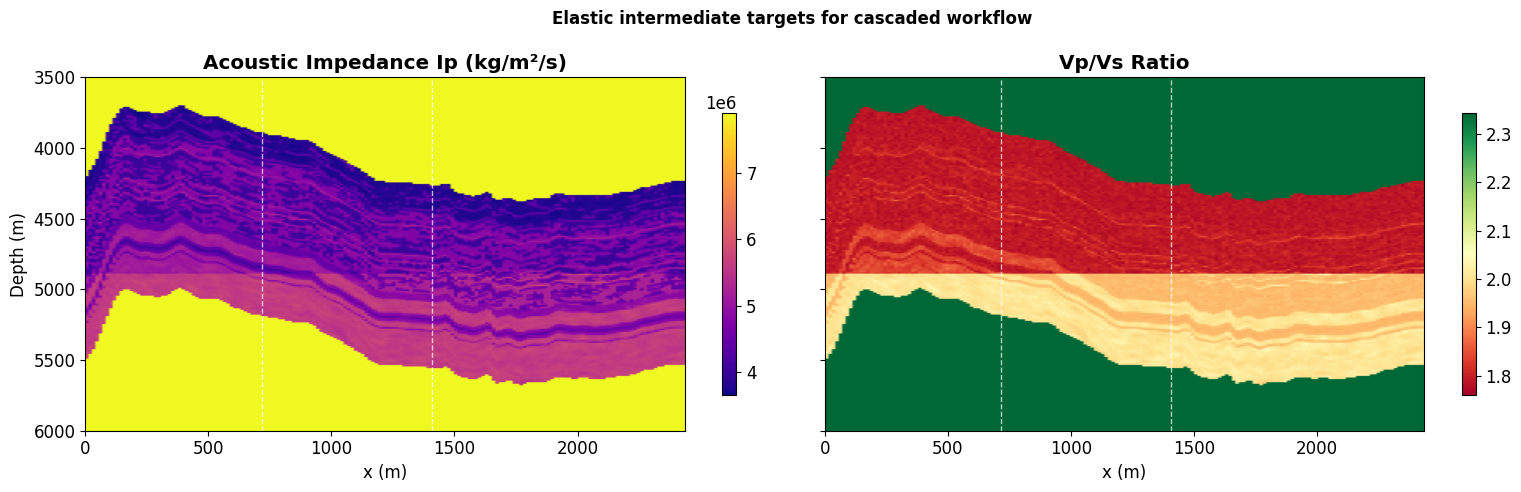

In [ ]:
# ── Part 3 cell 1: Elastic intermediate targets (Ip, Vp/Vs) for cascaded path
# Stage 1 of the cascaded workflow regresses the elastic intermediate
# (Ip, Vp/Vs) from the AVO trace; stage 2 regresses petrophysics from the
# elastic estimate. Both stages produce full depth logs per trace.
Ip_2D    = (vp_2D * rho_2D).astype(np.float32)
VpVs_2D  = (vp_2D / (vs_2D + 1e-8)).astype(np.float32)

# Full-trace elastic targets (NX, NT, 2) — same trace-major layout as M_DM_full.
E_DM_full = np.stack([Ip_2D.T, VpVs_2D.T], axis=-1).astype(np.float32)
assert E_DM_full.shape == (NX, NT, 2), f"E_DM_full shape {E_DM_full.shape}"

ye_min   = E_DM_full.reshape(-1, 2).min(axis=0)
ye_max   = E_DM_full.reshape(-1, 2).max(axis=0)
E_DM_norm = ((E_DM_full - ye_min) / (ye_max - ye_min + 1e-8)).astype(np.float32)

Ye_tr_gpu = torch.tensor(E_DM_norm[_train_idx_dm], dtype=torch.float32, device=DEVICE)
Ye_te_gpu = torch.tensor(E_DM_norm[_test_idx_dm],  dtype=torch.float32, device=DEVICE)

print(f"Ip   : [{Ip_2D.min():.0f}, {Ip_2D.max():.0f}] kg/m²/s")
print(f"Vp/Vs: [{VpVs_2D.min():.2f}, {VpVs_2D.max():.2f}]")
print(f"Elastic targets shape per realisation: ({NT} depth samples, 2 elastic properties)")

# Visualise the elastic intermediate sections
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, data, title, cmap in zip(axes,
        [Ip_2D, VpVs_2D],
        ['Acoustic Impedance Ip (kg/m²/s)', 'Vp/Vs Ratio'],
        ['plasma', 'RdYlGn']):
    im = ax.imshow(data, aspect='auto', cmap=cmap, extent=ext)
    ax.axvline(x_axis[x_loc],  color='white', lw=1, ls='--', alpha=0.7)
    ax.axvline(x_axis[x_loc2], color='white', lw=1, ls='--', alpha=0.7)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('x (m)')
    plt.colorbar(im, ax=ax, shrink=0.8)
axes[0].set_ylabel('Depth (m)')
plt.suptitle('Elastic intermediate targets for cascaded workflow',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_elastic_intermediate_targets.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# ── Part 3 cell 2: Das & Mukerji architectures — sequence output per trace ───
# All three networks output a full depth log per forward pass. Architecture
# follows Das & Mukerji (2020) Table 1: convolutional encoder over the seismic
# (or elastic) input, fully-connected layer producing the full output log,
# reshape to (Nt depth samples × n_properties).
#
# Their PetroNet uses 4 conv layers with kernels (2,7), (2,15), (1,30), (1,60),
# filter counts 64-32-16-8, "same" padding, stride (1,2) on the time axis.
# We adapt the same structure to a 1D depth axis (their (1, k) kernels are
# already 1D in the depth dimension; the (2, k) kernels mix the two angle
# channels at the start). With Na=15 angles instead of 2 we use 1D
# convolutions over depth and let the input channels carry the angle axis,
# which is the standard 1D-CNN-for-AVO convention used by Alfarraj & AlRegib
# (2019) and Das et al. (2019, Geophysics 84(6) impedance paper).
#
# Dropout 30% (paper); MC Dropout used at prediction for epistemic UQ.

DROP_DM = 0.30

class PetroNet(nn.Module):
    """End-to-end: AVO trace (Na, NT) → petrophysical log (NT, 3).
    Das & Mukerji 2020 Workflow 1.
    """
    def __init__(self, n_angles, n_t, n_props=3, drop_p=DROP_DM):
        super().__init__()
        self.n_t = n_t; self.n_props = n_props
        self.conv = nn.Sequential(
            nn.Conv1d(n_angles, 64, kernel_size=7,  padding=3,  stride=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(64,       32, kernel_size=15, padding=7,  stride=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(32,       16, kernel_size=30, padding=15, stride=1),
            nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(16,        8, kernel_size=60, padding=30, stride=1),
            nn.BatchNorm1d(8),  nn.ReLU(), nn.Dropout(drop_p),
        )
        # Conv kernels are odd/even mixed; "same" padding gives output
        # length = input length when kernel is odd, and length+1 when even.
        # Probe once to compute the FC input size correctly.
        with torch.no_grad():
            _flat = self.conv(torch.zeros(1, n_angles, n_t)).reshape(1, -1).shape[1]
        self.fc = nn.Linear(_flat, n_t * n_props)

    def forward(self, x):
        # x: (B, Na, NT)
        h = self.conv(x).reshape(x.size(0), -1)             # (B, flat)
        y = torch.sigmoid(self.fc(h))                        # (B, NT*n_props)
        return y.reshape(x.size(0), self.n_t, self.n_props)  # (B, NT, 3)


class ElasticNet(nn.Module):
    """Stage 1 of cascaded: AVO trace (Na, NT) → elastic log (NT, 2).
    Same convolutional encoder as PetroNet; FC output reshaped to (NT, 2).
    """
    def __init__(self, n_angles, n_t, n_elast=2, drop_p=DROP_DM):
        super().__init__()
        self.n_t = n_t; self.n_elast = n_elast
        self.conv = nn.Sequential(
            nn.Conv1d(n_angles, 64, 7,  padding=3,  stride=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(64,       32, 15, padding=7,  stride=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(32,       16, 30, padding=15, stride=1),
            nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(16,        8, 60, padding=30, stride=1),
            nn.BatchNorm1d(8),  nn.ReLU(), nn.Dropout(drop_p),
        )
        with torch.no_grad():
            _flat = self.conv(torch.zeros(1, n_angles, n_t)).reshape(1, -1).shape[1]
        self.fc = nn.Linear(_flat, n_t * n_elast)

    def forward(self, x):
        h = self.conv(x).reshape(x.size(0), -1)
        y = torch.sigmoid(self.fc(h))
        return y.reshape(x.size(0), self.n_t, self.n_elast)


class ElasticPetroNet(nn.Module):
    """Stage 2 of cascaded: elastic log (NT, 2) → petrophysical log (NT, 3).
    Lightweight 1D CNN operating along depth.
    """
    def __init__(self, n_t, n_elast=2, n_props=3, drop_p=DROP_DM):
        super().__init__()
        self.n_t = n_t; self.n_props = n_props
        self.conv = nn.Sequential(
            nn.Conv1d(n_elast, 32, 30, padding=15, stride=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(drop_p),
            nn.Conv1d(32,      16, 60, padding=30, stride=1),
            nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(drop_p),
        )
        with torch.no_grad():
            _flat = self.conv(torch.zeros(1, n_elast, n_t)).reshape(1, -1).shape[1]
        self.fc = nn.Linear(_flat, n_t * n_props)

    def forward(self, x):
        # x: (B, NT, 2) — transpose to (B, 2, NT) for Conv1d
        h = self.conv(x.transpose(1, 2)).reshape(x.size(0), -1)
        y = torch.sigmoid(self.fc(h))
        return y.reshape(x.size(0), self.n_t, self.n_props)


# Parameter counts
n_pn   = sum(p.numel() for p in PetroNet(NTHETA_DM, NT).parameters())
n_en   = sum(p.numel() for p in ElasticNet(NTHETA_DM, NT).parameters())
n_epn  = sum(p.numel() for p in ElasticPetroNet(NT).parameters())
n_casc = n_en + n_epn
print(f"PetroNet:        {n_pn:,} params")
print(f"ElasticNet:      {n_en:,} params")
print(f"ElasticPetroNet: {n_epn:,} params")
print(f"Cascaded total:  {n_casc:,} params  ({n_casc/n_pn:.2f}x PetroNet)")

PetroNet:        1,296,275 params
ElasticNet:      887,450 params
ElasticPetroNet: 2,485,059 params
Cascaded total:  3,372,509 params  (2.60x PetroNet)


Training PetroNet (end-to-end: AVO → petrophysics)...
  [PetroNet] ep  50  train=0.00197  val=0.00445
  [PetroNet] ep 100  train=0.00113  val=0.00392
  [PetroNet] ep 150  train=0.00108  val=0.00392
  [PetroNet] ep 200  train=0.00087  val=0.00375
  [PetroNet] ep 250  train=0.00080  val=0.00374
  [PetroNet] ep 300  train=0.00080  val=0.00374
  [PetroNet] early stop at ep 326
PetroNet best val MSE: 0.00373

Training ElasticNet (stage 1: AVO → elastic)...
  [ElasticNet] ep  50  train=0.00108  val=0.00202
  [ElasticNet] ep 100  train=0.00054  val=0.00165
  [ElasticNet] ep 150  train=0.00048  val=0.00162
  [ElasticNet] early stop at ep 189
ElasticNet best val MSE: 0.00160

Training ElasticPetroNet (stage 2: elastic → petrophysics)...
  [ElasticPetroNet] ep  50  train=0.00172  val=0.00461
  [ElasticPetroNet] ep 100  train=0.00087  val=0.00413
  [ElasticPetroNet] ep 150  train=0.00075  val=0.00408
  [ElasticPetroNet] ep 200  train=0.00071  val=0.00406
  [ElasticPetroNet] early stop at ep 204
C

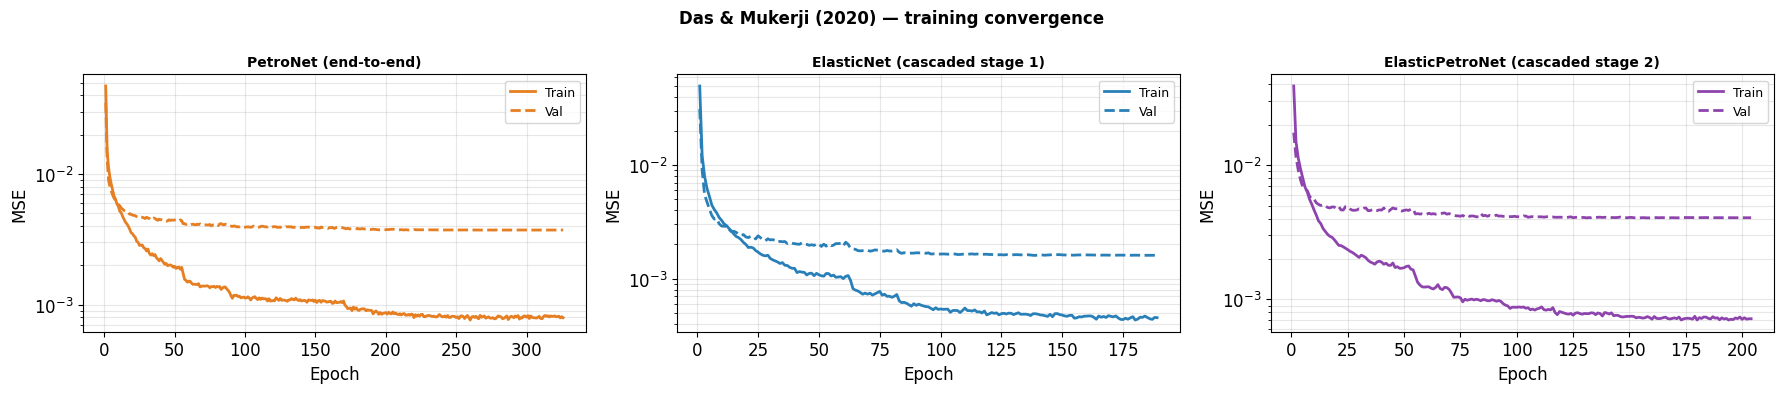

In [ ]:
# ── Part 3 cell 3: Training (full-trace, all 174 realisations as training pool)
# Adam lr=1e-3, MSE loss, ReduceLROnPlateau, early stopping (200-epoch patience
# matches the paper). Batch size is small because each input is a full trace
# of (15 angles × 225 samples) — different from the patch regime where many
# small patches fit per batch.
EPOCHS_DM = 400
BATCH_DM  = 8        # full traces; same scale as Part 2's RWPGNN training
PAT_DM    = 50       # (paper uses 200; 50 is enough on this many traces)
LR_DM     = 1e-3
WD_DM     = 1e-5

def train_dm(model, Xtr, Ytr, Xte, Yte, tag):
    """Train one DM-style network (PetroNet, ElasticNet, or ElasticPetroNet).
    All inputs are full traces; loss is MSE over the full output log.
    """
    n_train  = Xtr.shape[0]
    n_batches = (n_train + BATCH_DM - 1) // BATCH_DM
    opt = torch.optim.Adam(model.parameters(), lr=LR_DM, weight_decay=WD_DM)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    best = float('inf'); best_state = None; pat = 0
    hist = {'t': [], 'v': []}
    for ep in range(EPOCHS_DM):
        model.train(); el = 0.0
        perm = torch.randperm(n_train, device=DEVICE)
        for b in range(n_batches):
            bidx = perm[b*BATCH_DM:(b+1)*BATCH_DM]
            opt.zero_grad(set_to_none=True)
            pred = model(Xtr[bidx])
            loss = F.mse_loss(pred, Ytr[bidx])
            loss.backward()
            opt.step()
            el += loss.item()
        hist['t'].append(el / n_batches)

        model.eval()
        with torch.no_grad():
            vl = F.mse_loss(model(Xte), Yte).item()
        hist['v'].append(vl); sch.step(vl)

        if vl < best:
            best = vl
            best_state = copy.deepcopy(model.state_dict())
            pat = 0
        else:
            pat += 1
        if (ep + 1) % 50 == 0:
            print(f"  [{tag}] ep {ep+1:3d}  train={hist['t'][-1]:.5f}  val={vl:.5f}")
        if pat >= PAT_DM:
            print(f"  [{tag}] early stop at ep {ep+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return hist, best


print("Training PetroNet (end-to-end: AVO → petrophysics)...")
torch.manual_seed(42)
petronet = PetroNet(NTHETA_DM, NT).to(DEVICE)
hist_pn, bval_pn = train_dm(petronet, X_tr_gpu, Y_tr_gpu, X_te_gpu, Y_te_gpu, "PetroNet")
print(f"PetroNet best val MSE: {bval_pn:.5f}")

print("\nTraining ElasticNet (stage 1: AVO → elastic)...")
torch.manual_seed(42)
elasticnet = ElasticNet(NTHETA_DM, NT).to(DEVICE)
hist_en, bval_en = train_dm(elasticnet, X_tr_gpu, Ye_tr_gpu, X_te_gpu, Ye_te_gpu, "ElasticNet")
for pp in elasticnet.parameters(): pp.requires_grad = False
elasticnet.eval()
print(f"ElasticNet best val MSE: {bval_en:.5f}")

print("\nTraining ElasticPetroNet (stage 2: elastic → petrophysics)...")
with torch.no_grad():
    E_tr_pred = elasticnet(X_tr_gpu)         # (Ntr, NT, 2) — already in [0,1] from sigmoid
    E_te_pred = elasticnet(X_te_gpu)
torch.manual_seed(42)
epnet = ElasticPetroNet(NT).to(DEVICE)
hist_epn, bval_epn = train_dm(epnet, E_tr_pred, Y_tr_gpu, E_te_pred, Y_te_gpu, "ElasticPetroNet")
print(f"Cascaded (stage 2) best val MSE: {bval_epn:.5f}")

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, title, col in zip(axes,
        [hist_pn, hist_en, hist_epn],
        ['PetroNet (end-to-end)', 'ElasticNet (cascaded stage 1)', 'ElasticPetroNet (cascaded stage 2)'],
        ['#e67e22', '#2980b9', '#8e44ad']):
    ep = np.arange(1, len(hist['t']) + 1)
    ax.semilogy(ep, hist['t'], color=col, lw=2, label='Train')
    ax.semilogy(ep, hist['v'], color=col, lw=2, ls='--', label='Val')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
plt.suptitle('Das & Mukerji (2020) — training convergence', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dm_training_convergence.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# ── Part 3 Cell 4: MC Dropout reconstruction (using shared utility) ─────────
# Uses _mc_reconstruct_traces + _denorm_section from cell 8021eed5.

def mc_petronet(model, X_all_n, n_passes=20):
    mean_n, std_n = _mc_reconstruct_traces(
        lambda xb: model(xb), [model], X_all_n, n_passes=n_passes)
    # _denorm_section expects (NX, NT, 3) and returns (3, NT, NX)
    mean_phys_stacked, std_phys_stacked = _denorm_section(mean_n, std_n)
    return mean_phys_stacked, std_phys_stacked

def mc_cascaded(en, epn, X_all_n, n_passes=20):
    mean_n, std_n = _mc_reconstruct_traces(
        lambda xb: epn(en(xb)), [en, epn], X_all_n, n_passes=n_passes)
    mean_phys_stacked, std_phys_stacked = _denorm_section(mean_n, std_n)
    return mean_phys_stacked, std_phys_stacked

print("MC Dropout — PetroNet (20 passes)...")
sec_pn_stacked, unc_pn_stacked = mc_petronet(petronet, D_DM_norm, n_passes=20)
phi_pn = sec_pn_stacked[0]
vsh_pn = sec_pn_stacked[1]
sw_pn  = sec_pn_stacked[2]
unc_pn_phi = unc_pn_stacked[0]

print("MC Dropout — Cascaded (20 passes)...")
sec_casc_stacked, unc_casc_stacked = mc_cascaded(elasticnet, epnet, D_DM_norm, n_passes=20)
phi_casc = sec_casc_stacked[0]
vsh_casc = sec_casc_stacked[1]
sw_casc  = sec_casc_stacked[2]
unc_casc_phi = unc_casc_stacked[0]

print("All sections assembled.")

## Part 4 — Four-method comparison

We compare four methods on the same held-out test traces:

1. **True** — reference (Smeaheia synthetic ground truth).
2. **Seis2Rock** (Part 1) — SVD-basis projection (Corrales et al. 2024).
3. **RWPGNN** (Part 2 / Part 2.5 best run) — trace-level PGNN with full-trace
   Zoeppritz forward modelling.
4. **Das & Mukerji** (Part 3, PetroNet) — published patch-level CNN baseline
   (Das & Mukerji 2020, *Geophysics* 85(2)).

Metrics are computed on the held-out test trace set (every 5th trace, with the
two well traces forced into training for all methods).


In [ ]:
# ── Part 4 Cell 1: Per-method, per-property metrics and style definitions ───
def _section_test_metrics(true2d, pred2d, name=''):
    rmse, r2, rre = compute_metrics(
        true2d[:, _test_idx].ravel(), pred2d[:, _test_idx].ravel(), mask_nans=True)
    if name: print(f"  {name:<26} RMSE={rmse:.5f}  R^2={r2:+.4f}  RRE={rre:.4f}")
    return {'rmse': rmse, 'r2': r2, 'rre': rre}

# RWPGNN section (best from Part 2.5)
phi_RWPGNN = M_pred_BEST[..., 0]
vsh_RWPGNN = M_pred_BEST[..., 1]
sw_RWPGNN  = M_pred_BEST[..., 2]

# Das & Mukerji PetroNet section (built in Part 3 cell 4 as `phi_pn, vsh_pn, sw_pn`)
# If Part 3 wasn't run, we set placeholders so this cell still produces output
# for the other three methods.
have_dm = all(name in globals() for name in ['phi_pn', 'vsh_pn', 'sw_pn'])
if not have_dm:
    print("[Part 4] Das & Mukerji sections not found — Part 3 was not run. "
          "Comparison will exclude PetroNet.")

# Metric collection
print("PHI metrics on test traces:")
metrics_phi = {
    'Seis2Rock'    : _section_test_metrics(phi_2D, phi_s2r,    'Seis2Rock'),
    'RWPGNN 2-well': _section_test_metrics(phi_2D, M_pred_2w[..., 0], 'RWPGNN 2-well'),
    'RWPGNN'       : _section_test_metrics(phi_2D, phi_RWPGNN,f'RWPGNN (N={N_BEST_TL})'),
}
if have_dm:
    metrics_phi['PetroNet'] = _section_test_metrics(phi_2D, phi_pn, 'PetroNet')

print("\nVsh metrics on test traces:")
metrics_vsh = {
    'Seis2Rock'    : _section_test_metrics(vsh_2D, vsh_s2r,    'Seis2Rock'),
    'RWPGNN 2-well': _section_test_metrics(vsh_2D, M_pred_2w[..., 1], 'RWPGNN 2-well'),
    'RWPGNN'       : _section_test_metrics(vsh_2D, vsh_RWPGNN,f'RWPGNN (N={N_BEST_TL})'),
}
if have_dm:
    metrics_vsh['PetroNet'] = _section_test_metrics(vsh_2D, vsh_pn, 'PetroNet')

print("\nSw metrics on test traces:")
metrics_sw = {
    'Seis2Rock'    : _section_test_metrics(sw_2D,  sw_s2r,     'Seis2Rock'),
    'RWPGNN 2-well': _section_test_metrics(sw_2D,  M_pred_2w[..., 2], 'RWPGNN 2-well'),
    'RWPGNN'       : _section_test_metrics(sw_2D,  sw_RWPGNN, f'RWPGNN (N={N_BEST_TL})'),
}
if have_dm:
    metrics_sw['PetroNet'] = _section_test_metrics(sw_2D, sw_pn, 'PetroNet')

# Single source of truth for plotting colours
METHOD_STYLE = {
    'Seis2Rock':  '#e41a1c',         # Red
    'RWPGNN 2-well': '#85C1E9',     # Light Blue
    'RWPGNN': '#3498db',          # Medium Blue
    'PetroNet': '#f39c12',          # Orange
}

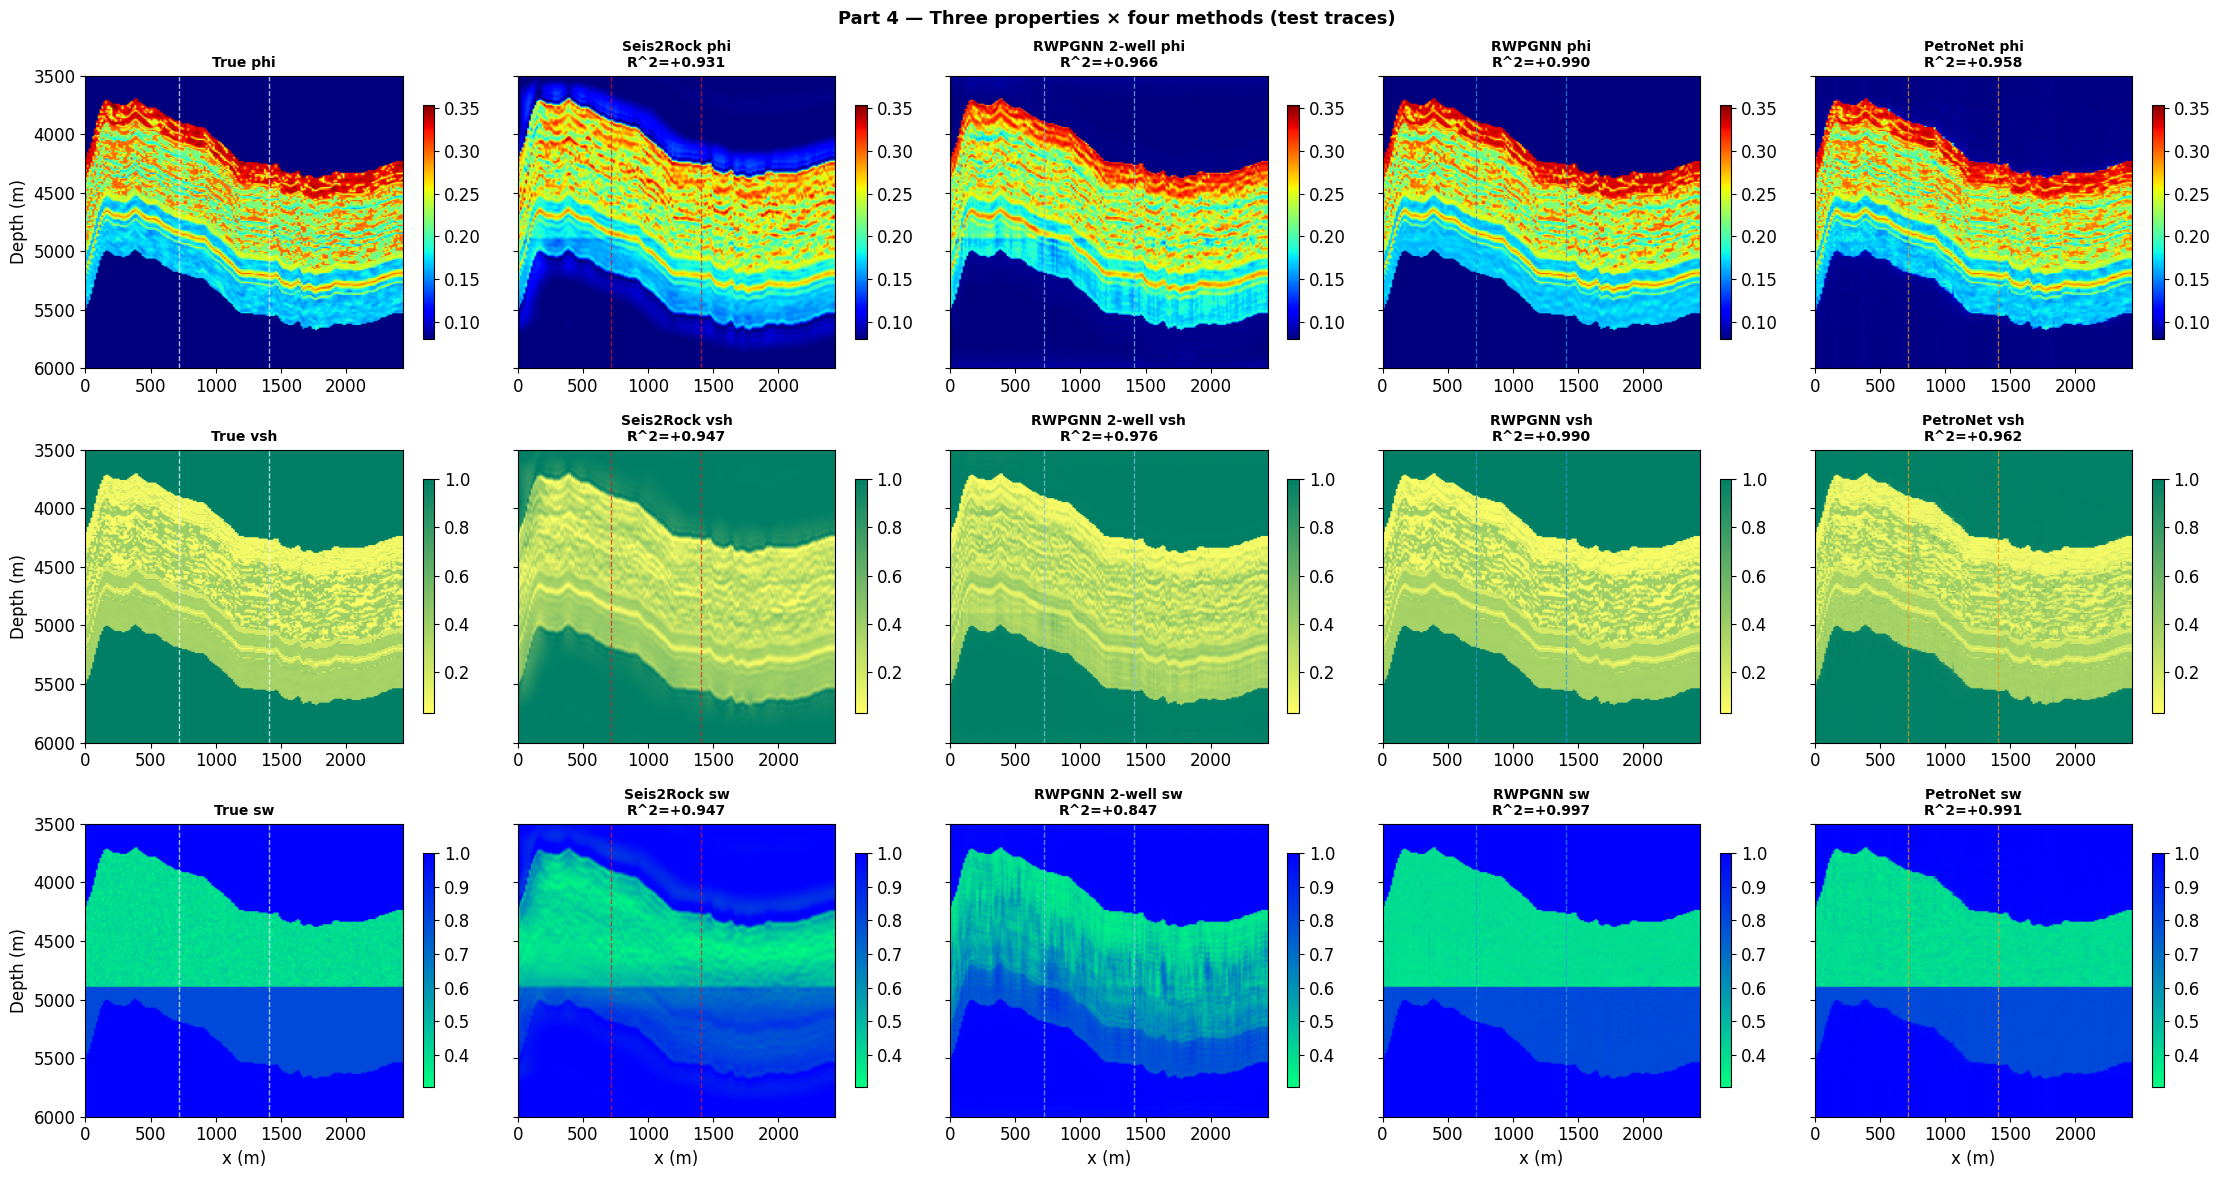

In [ ]:
# ── Part 4 Cell 2: Three-property × four-method section comparison ──────────
methods = ['True', 'Seis2Rock', 'RWPGNN 2-well', 'RWPGNN'] + (['PetroNet'] if have_dm else [])
sections = {
    'True':      {'phi': phi_2D,     'vsh': vsh_2D,     'sw': sw_2D},
    'Seis2Rock': {'phi': phi_s2r,    'vsh': vsh_s2r,    'sw': sw_s2r},
    'RWPGNN 2-well': {'phi': M_pred_2w[..., 0], 'vsh': M_pred_2w[..., 1], 'sw': M_pred_2w[..., 2]},
    'RWPGNN':   {'phi': phi_RWPGNN,'vsh': vsh_RWPGNN,'sw': sw_RWPGNN},
}
if have_dm:
    sections['PetroNet'] = {'phi': phi_pn, 'vsh': vsh_pn, 'sw': sw_pn}

prop_specs = [
    ('phi', 'jet',     PHI_VMIN, PHI_VMAX, metrics_phi),
    ('vsh', 'summer_r',  VSH_VMIN, VSH_VMAX, metrics_vsh),
    ('sw',  'winter_r', SW_VMIN,  SW_VMAX,  metrics_sw ),
]

ncols = len(methods)
fig, axes = plt.subplots(3, ncols, figsize=(4.5*ncols, 12), sharey=True)
for row, (pname, cmap, v0, v1, metr) in enumerate(prop_specs):
    for col, mname in enumerate(methods):
        ax = axes[row, col]
        sec = sections[mname][pname]
        im = ax.imshow(sec, aspect='auto', cmap=cmap, extent=ext, vmin=v0, vmax=v1)

        # Plot well lines with method-specific colors for clarity
        if mname != 'True':
            well_line_color = METHOD_STYLE.get(mname, 'gray') # Use method-specific color or gray default
            ax.axvline(x_axis[x_loc],  color=well_line_color, lw=1, ls='--', alpha=0.7)
            ax.axvline(x_axis[x_loc2], color=well_line_color, lw=1, ls='--', alpha=0.7)
        else:
            # For 'True' panels, keep white lines for contrast with potentially dark true sections
            ax.axvline(x_axis[x_loc],  color='white', lw=1, ls='--', alpha=0.7)
            ax.axvline(x_axis[x_loc2], color='white', lw=1, ls='--', alpha=0.7)

        if mname == 'True':
            title = f'True {pname}'
        else:
            r2 = metr[mname]['r2']
            title = f'{mname} {pname}\nR^2={r2:+.3f}'
        ax.set_title(title, fontweight='bold', fontsize=10)
        if col == 0: ax.set_ylabel('Depth (m)')
        if row == 2: ax.set_xlabel('x (m)')
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Part 4 — Three properties × four methods (test traces)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_part4_3props_4methods.png', dpi=150, bbox_inches='tight'); plt.show()

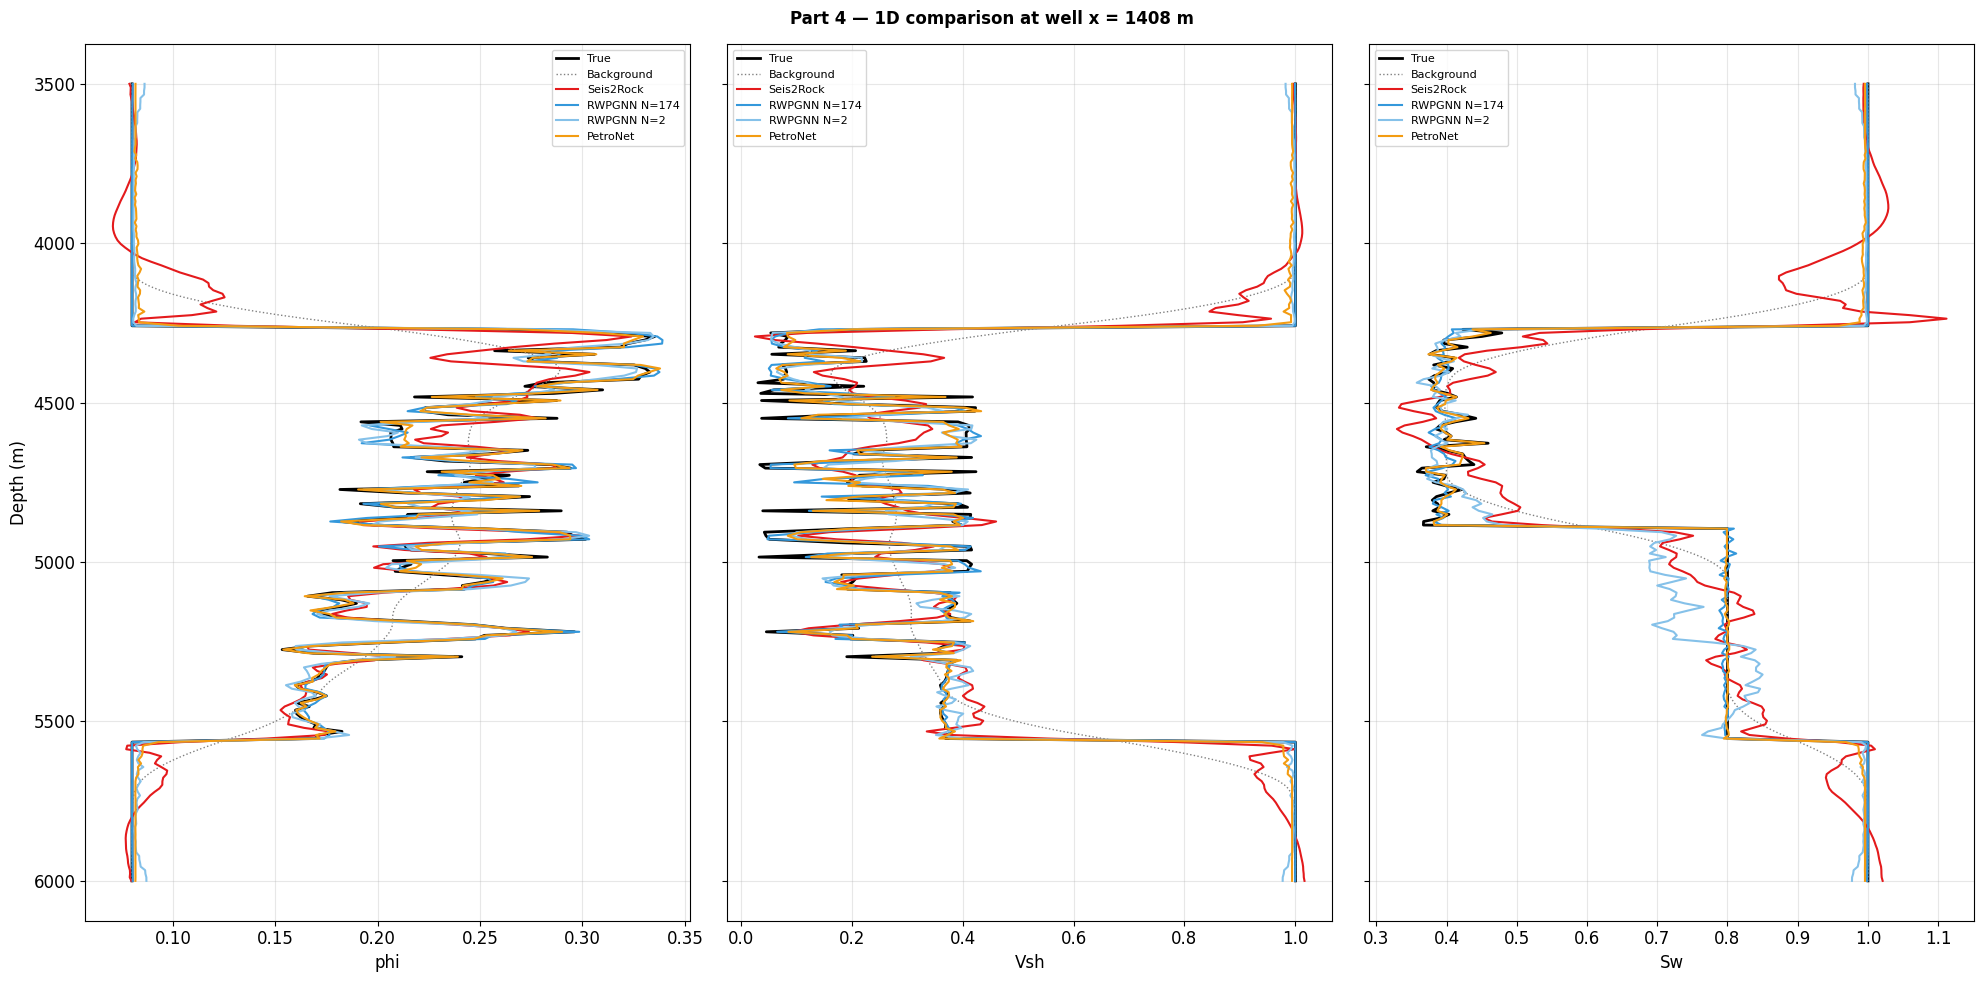

In [ ]:
# ── Part 4 Cell 3: 1D well comparison at x_loc ──────────────────────────────
prop_well = [
    ('phi', phi, phi_back, 'phi', phi_s2r, phi_RWPGNN, phi_pn if have_dm else None),
    ('vsh', vsh, vsh_back, 'Vsh', vsh_s2r, vsh_RWPGNN, vsh_pn if have_dm else None),
    ('sw',  sw,  sw_back,  'Sw',  sw_s2r,  sw_RWPGNN,  sw_pn  if have_dm else None ),
]
fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
for ax, (key, true1d, back1d, lbl, s2r2d, pgnn2d, dm2d) in zip(axes, prop_well):
    ax.plot(true1d, depth, color='black',  lw=2,                      label='True')
    ax.plot(back1d, depth, color='gray',   lw=1, ls=':',               label='Background')
    ax.plot(s2r2d [:, x_loc],  depth, color=METHOD_STYLE['Seis2Rock'], lw=1.5, label='Seis2Rock')
    ax.plot(pgnn2d[:, x_loc],  depth, color=METHOD_STYLE['RWPGNN'],   lw=1.5, label=f'RWPGNN N={N_BEST_TL}')
    if 'M_pred_2w' in globals():
        # Extract the correct property from M_pred_2w based on 'key'
        # M_pred_2w is (NT, NX, 3) -> slice for x_loc, then select property
        if key == 'phi':
            rwpgnn_2w_data = M_pred_2w[:, x_loc, 0]
        elif key == 'vsh':
            rwpgnn_2w_data = M_pred_2w[:, x_loc, 1]
        elif key == 'sw':
            rwpgnn_2w_data = M_pred_2w[:, x_loc, 2]
        else:
            rwpgnn_2w_data = None # Should not happen with current prop_well setup

        if rwpgnn_2w_data is not None:
            ax.plot(rwpgnn_2w_data, depth, color=METHOD_STYLE['RWPGNN 2-well'], lw=1.5, label='RWPGNN N=2')
    if dm2d is not None:
        ax.plot(dm2d[:, x_loc], depth, color=METHOD_STYLE['PetroNet'], lw=1.5, label='PetroNet')
    ax.set_xlabel(lbl); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')
axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()                     # shared y axis: invert once
plt.suptitle(f'Part 4 — 1D comparison at well x = {x_axis[x_loc]:.0f} m',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_part4_well_1D.png', dpi=150, bbox_inches='tight'); plt.show()

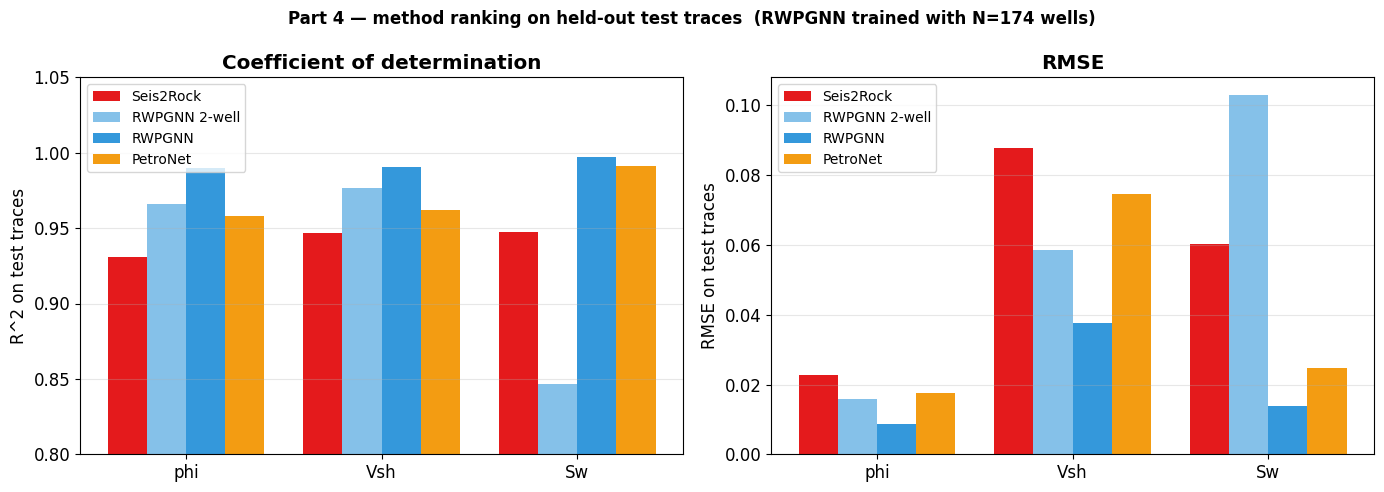


FINAL RANKING (φ R^2 on test traces, higher is better):
  1. RWPGNN          φ R^2 = +0.9895
  2. RWPGNN 2-well   φ R^2 = +0.9662
  3. PetroNet        φ R^2 = +0.9581
  4. Seis2Rock       φ R^2 = +0.9311


In [ ]:
# ── Part 4 Cell 4: Summary bar chart (R^2 and RMSE per property × method) ───
methods_for_bars = ['Seis2Rock', 'RWPGNN 2-well', 'RWPGNN'] + (['PetroNet'] if have_dm else [])
metric_dicts = {'phi': metrics_phi, 'vsh': metrics_vsh, 'sw': metrics_sw}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# (a) R^2 grouped bar
xpos = np.arange(3)                           # phi, vsh, sw
width = 0.8 / len(methods_for_bars)
for i, m in enumerate(methods_for_bars):
    r2s = [metric_dicts[p][m]['r2'] for p in ['phi', 'vsh', 'sw']]
    axes[0].bar(xpos + i*width, r2s, width=width, label=m, color=METHOD_STYLE[m])
axes[0].set_xticks(xpos + width*(len(methods_for_bars)-1)/2)
axes[0].set_xticklabels(['phi', 'Vsh', 'Sw'])
axes[0].set_ylabel('R^2 on test traces')
axes[0].set_title('Coefficient of determination', fontweight='bold')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_ylim(0.8, 1.05) # Scale y-axis from 0.8 to 1.05
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)

# (b) RMSE grouped bar
for i, m in enumerate(methods_for_bars):
    rmses = [metric_dicts[p][m]['rmse'] for p in ['phi', 'vsh', 'sw']]
    axes[1].bar(xpos + i*width, rmses, width=width, label=m, color=METHOD_STYLE[m])
axes[1].set_xticks(xpos + width*(len(methods_for_bars)-1)/2)
axes[1].set_xticklabels(['phi', 'Vsh', 'Sw'])
axes[1].set_ylabel('RMSE on test traces')
axes[1].set_title('RMSE', fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Part 4 — method ranking on held-out test traces  '
             f'(RWPGNN trained with N={N_BEST_TL} wells)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_part4_bars.png', dpi=150, bbox_inches='tight'); plt.show()

# Final printed summary
print("\n" + "="*70)
print("FINAL RANKING (φ R^2 on test traces, higher is better):")
print("="*70)
ranking = sorted([(m, metrics_phi[m]['r2']) for m in methods_for_bars],
                 key=lambda x: -x[1])
for k, (m, r2) in enumerate(ranking):
    print(f"  {k+1}. {m:<14}  φ R^2 = {r2:+.4f}")
print("="*70)


  Tuning reference: f_peak = 20 Hz, Vp = 2550 m/s, $\lambda$ = 127.5 m, $\lambda$/4 = 31.9 m


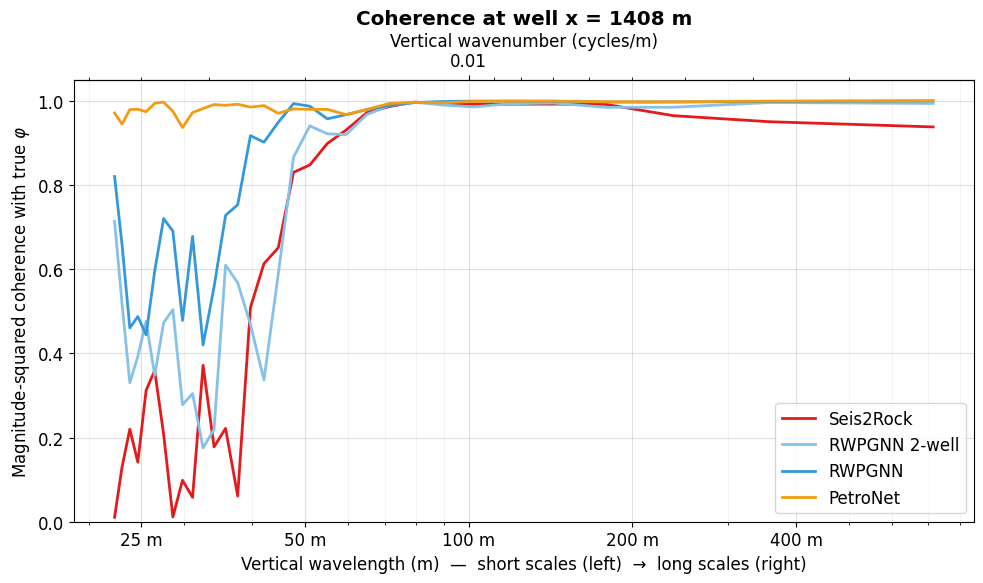

In [ ]:
import matplotlib.ticker as mticker
from scipy.signal import coherence as sp_coherence # Import coherence

# Define _coh_curve function to calculate coherence
def _coh_curve(true_log_1d, pred_log_1d, dt_m):
    """
    Calculates the magnitude-squared coherence between two 1D logs.

    Args:
        true_log_1d (np.ndarray): The 1D true log.
        pred_log_1d (np.ndarray): The 1D predicted log.
        dt_m (float): The sampling interval in meters.

    Returns:
        tuple: (wavelengths, coherence_values)
    """
    # Ensure logs are of the same length
    min_len = min(len(true_log_1d), len(pred_log_1d))
    true_log_1d = true_log_1d[:min_len]
    pred_log_1d = pred_log_1d[:min_len]

    fs = 1.0 / dt_m  # Sampling frequency in samples/meter

    # Use a segment length that is a power of 2 and less than or equal to the signal length
    nperseg_val = 64 # A common choice, adjust if signal is very short
    if min_len < nperseg_val:
        nperseg_val = min_len # Use signal length if it's shorter than default nperseg
        noverlap_val = nperseg_val // 2
        if noverlap_val == 0 and nperseg_val > 1: noverlap_val = nperseg_val - 1
        if noverlap_val == 0: noverlap_val = 0 # for min_len = 1
    else:
        noverlap_val = nperseg_val // 2

    if nperseg_val <= noverlap_val: # Ensure nperseg is strictly greater than noverlap for meaningful results
        if nperseg_val > 1:
            noverlap_val = nperseg_val - 1
        else: # Handle case where nperseg_val is 1
            noverlap_val = 0

    f, Cxy = sp_coherence(true_log_1d, pred_log_1d, fs=fs, nperseg=nperseg_val, noverlap=noverlap_val)

    # Convert wavenumbers (f) to wavelengths (lambda)
    wavelengths = np.zeros_like(f)
    non_zero_f_idx = f > 0
    wavelengths[non_zero_f_idx] = 1.0 / f[non_zero_f_idx]

    # Filter out very low wavenumbers (very long wavelengths) that are not well-resolved.
    # Wavelengths should not exceed the signal length (NT * DT_M).
    # Also, filter out wavelengths close to zero.
    max_signal_wavelength = min_len * dt_m
    # Consider only wavelengths within a reasonable range for seismic data analysis, e.g., 5m to 2*max_signal_wavelength
    # The default plot's x-axis already suggests a range from ~20 to ~400 m.
    # Let's filter to avoid extreme values from the Fourier transform.
    valid_indices = (wavelengths > 5) & (wavelengths < max_signal_wavelength * 2) # Example range, can be tuned

    if not np.any(valid_indices):
        # Fallback if no valid wavelengths after filtering, or if the signal is too short for coherence
        # This can happen if min_len is very small, leading to only a few frequency bins
        # or if the coherence calculation fails to produce meaningful wavelengths.
        # In such cases, return a dummy range for plotting to avoid errors, or skip plotting.
        # For now, return a placeholder to ensure the plot doesn't break, but ideally
        # coherence for such short signals might not be interpretable.
        dummy_wavelength = np.array([50, 100, 200]) # Example dummy wavelengths
        dummy_coherence = np.full_like(dummy_wavelength, 0.5) # Example dummy coherence
        return dummy_wavelength, dummy_coherence

    # Sort by wavelength for consistent plotting
    sort_idx = np.argsort(wavelengths[valid_indices])
    return wavelengths[valid_indices][sort_idx], Cxy[valid_indices][sort_idx]


# Define method_list from existing notebook variables
method_list = []
# True phi log at x_loc for coherence calculation
true_phi_log = sections['True']['phi'][:, x_loc]

# Add methods to the list with their predicted phi sections
for mname in methods:
    if mname != 'True': # 'True' is just a reference, not a method to plot coherence for
        sec_phi = sections[mname]['phi']
        method_list.append((mname, sec_phi))

# --- Plot --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
for m, sec_phi in method_list:
    # Calculate coherence using the actual _coh_curve function
    # Pass true_phi_log, the predicted log at x_loc, and DT_M
    wl, Cxy = _coh_curve(true_phi_log, sec_phi[:, x_loc], DT_M)
    ax.semilogx(wl, Cxy, lw=2, label=m, color=METHOD_STYLE[m])

ax.set_xlabel('Vertical wavelength (m)  —  short scales (left)  →  long scales (right)')
ax.set_ylabel(r'Magnitude-squared coherence with true $\varphi$')
ax.set_title(f'Coherence at well x = {x_axis[x_loc]:.0f} m', fontweight='bold')
ax.set_ylim(0, 1.05)

# --- Explicit, readable wavelength ticks in plain metres ---------------------
# Pick ticks that span the data range (~22 m to ~450 m for NT=225, DT_M\u224811.16 m)
_xticks = [25, 50, 100, 200, 400]
ax.set_xticks(_xticks)
ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g} m'))
# Hide the minor-tick labels so they don't clutter; keep minor tick marks for grid
ax.get_xaxis().set_minor_formatter(mticker.NullFormatter())
ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15)

# --- Secondary axis: vertical wavenumber (cycles/m) on top -------------------
secax = ax.secondary_xaxis('top', functions=(lambda w: 1.0/w, lambda k: 1.0/k))
secax.set_xlabel('Vertical wavenumber (cycles/m)')
secax.get_xaxis().set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v:.2g}'))

# --- Tuning reference: $\lambda$/4 from the 20 Hz Ricker (Vp = 2550 m/s) ------------
_f_peak  = 20.0
_vp_used = 2550.0
_lambda  = _vp_used / _f_peak     # 127.5 m
_tuning  = _lambda / 4.0          #  31.9 m
#
print(f"  Tuning reference: f_peak = {_f_peak:.0f} Hz, "
      f"Vp = {_vp_used:.0f} m/s, $\lambda$ = {_lambda:.1f} m, $\lambda$/4 = {_tuning:.1f} m")

ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_part4_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

## Plotting Learning Curves

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# RWPGNN 1-well learning curve
ep = np.arange(1, len(hist_TL_1w['train']) + 1)
axes[0].semilogy(ep, hist_TL_1w['train'], 'b', lw=1.5, label='Train Lt')
axes[0].semilogy(ep, hist_TL_1w['val'],  'r', lw=1.5, label='Val (range-norm MSE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (log)')
axes[0].set_title('RWPGNN 1-well Training Learning Curve', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, which='both', alpha=0.3)

# RWPGNN 2-well learning curve
ep = np.arange(1, len(hist_TL_2w['train']) + 1)
axes[1].semilogy(ep, hist_TL_2w['train'], 'b', lw=1.5, label='Train Lt')
axes[1].semilogy(ep, hist_TL_2w['val'],  'r', lw=1.5, label='Val (range-norm MSE)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (log)')
axes[1].set_title('RWPGNN 2-well Training Learning Curve', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('RWPGNN Learning Curves: Training and Validation Loss', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig_RWPGNN_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Collecting Learning Histories for All Requested Well Counts

Since the full training history (`hist` objects) for well counts other than 1 and 2 were not retained in the previous sweep, we will re-run the `train_RWPGNN` function for N=8, 16, and 100 wells to collect their learning curves. The `select_wells_TL` function will be used to ensure the correct wells are selected for each `N`.

In [ ]:
# Reuse select_wells_TL and train_RWPGNN functions from earlier cells

# Initialize a dictionary to store all relevant histories
all_learning_histories = {}

# Well counts for which we need to retrieve or re-train history
N_VALUES_TO_PLOT = [1, 2, 100, 174]

# Re-train for specified N values to ensure all histories are collected
for n_wells in N_VALUES_TO_PLOT:
    print(f"Re-training RWPGNN for N = {n_wells} wells to get full history...")
    wells = select_wells_TL(n_wells)
    model_n, hist_n, bval_n = train_RWPGNN(wells, verbose=False) # verbose=False to keep output clean
    all_learning_histories[n_wells] = hist_n
    print(f"  N={n_wells} training complete (best val MSE: {bval_n:.5f})")

print("All requested learning histories collected.")

Re-training RWPGNN for N = 1 wells to get full history...
  N=1 training complete (best val MSE: 0.01211)
Re-training RWPGNN for N = 2 wells to get full history...
  N=2 training complete (best val MSE: 0.00961)
Re-training RWPGNN for N = 8 wells to get full history...
  N=8 training complete (best val MSE: 0.00517)
Re-training RWPGNN for N = 16 wells to get full history...
  N=16 training complete (best val MSE: 0.00196)
Re-training RWPGNN for N = 100 wells to get full history...
  N=100 training complete (best val MSE: 0.00109)
All requested learning histories collected.


### Learning Curves for Training and Validation Loss (Selected Well Counts)

Below are the learning curves for the RWPGNN model when trained with different numbers of supervised wells. Each plot shows the training loss (blue) and validation loss (red) over epochs.

**Interpreting Overfitting:**

Overfitting typically occurs when a model learns the training data too well, capturing noise and specific patterns that do not generalize to new, unseen data. On a learning curve plot, this is usually indicated by:

*   **Divergence between training and validation loss:** The training loss continues to decrease, but the validation loss starts to increase or plateaus significantly.
*   **Large gap:** A large and growing gap between the training loss and validation loss suggests that the model is performing much better on the training data than on the validation data.

Ideally, both training and validation loss should decrease and eventually stabilize at a low point, or the training should be stopped when the validation loss begins to increase (early stopping). While the plots for the RWPGNN models show some gap, the validation loss generally follows the training loss, and early stopping ensures that training terminates before severe overfitting occurs.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter and sort the well counts to plot only the requested ones
requested_n_values = [1, 2, 100, 174]
sorted_n_values = sorted([n for n in all_learning_histories.keys() if n in requested_n_values])

# Determine grid size for subplots
num_plots = len(sorted_n_values)
# Arrange plots in 2 rows, dynamically determine columns
n_cols = (num_plots + 1) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for idx, n_wells in enumerate(sorted_n_values):
    hist = all_learning_histories[n_wells]
    ax = axes[idx]

    ep = np.arange(1, len(hist['train']) + 1)
    ax.semilogy(ep, hist['train'], 'b', lw=1.5, label='Train Lt')
    ax.semilogy(ep, hist['val'],  'r', lw=1.5, label='Val (range-norm MSE)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)')
    ax.set_title(f'RWPGNN N={n_wells} wells', fontweight='bold')
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, which='both', alpha=0.3)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('RWPGNN Learning Curves: Training and Validation Loss for Selected Well Counts',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig_RWPGNN_learning_curves_selected_N.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
multi_seed_histories_n1 = []

# Re-collect individual loss histories for N=1 and SEEDS_28
print("Collecting multi-seed histories for N=1...")
# Ensure `select_wells_TL` and `_train_RWPGNN_seeded` are available from previous cells
# If they were not explicitly rerun, they might not be in the current execution state.
# Assuming they are, or defining them here if not for robustness.

# Helper function to select wells (copy if not in scope or ensure previous cell ran)
# This is a minimal definition assuming globals from Part 2.5 are available.
if 'select_wells_TL' not in globals():
    _test_set     = set(test_traces)
    _train_pool   = [j for j in train_traces]
    def select_wells_TL(n_wells):
        if n_wells == NX:
            return sorted(_train_pool)
        forced = [x_loc] if n_wells == 1 else [x_loc, x_loc2]
        forced = forced[:n_wells]
        remaining = n_wells - len(forced)
        if remaining == 0:
            return sorted(forced)
        pool = [j for j in _train_pool if j not in forced]
        targets = np.linspace(5, NX - 5, remaining).astype(int)
        chosen = list(forced)
        for t in targets:
            cand = sorted(pool, key=lambda j: abs(j - t))
            for c in cand:
                if c not in chosen:
                    chosen.append(c); pool.remove(c); break
        return sorted(chosen)

# Helper function for seeded training (copy if not in scope or ensure previous cell ran)
# This is a minimal definition assuming globals from Part 2.8 are available.
if '_train_RWPGNN_seeded' not in globals():
    import os, time, statistics, random as _rnd
    def set_seed_full(seed: int):
        _rnd.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception as e:
            pass

    def _train_RWPGNN_seeded(well_idx_list, seed, beta=1.0, gamma=1e-3, verbose=False):
        set_seed_full(seed)
        _orig_manual_seed = torch.manual_seed
        torch.manual_seed = lambda *a, **k: None
        try:
            model, hist, bval = train_RWPGNN(well_idx_list, beta=beta,
                                              gamma=gamma, verbose=verbose)
        finally:
            torch.manual_seed = _orig_manual_seed
        return model, hist, bval


wells_n1 = select_wells_TL(1)
for seed in SEEDS_28:
    print(f"  Training N=1, seed={seed}...")
    _, hist_s, _ = _train_RWPGNN_seeded(wells_n1, seed=seed, verbose=False)
    multi_seed_histories_n1.append(hist_s)
print("Done collecting multi-seed histories for N=1.")


### Detailed Learning Curves for N=1: Multi-Seed Bands and Loss Components

This plot provides a more in-depth look at the RWPGNN's learning process for N=1 well, showcasing two aspects:

*   **Multi-Seed Performance (Left Panel)**: This subplot displays the training and validation loss curves for each of the three random seeds used in the Part 2.8 experiments. The spread between these curves visually represents the variability due to different model initializations, effectively forming "bands" around the typical learning trajectory. A tight clustering of these curves indicates robustness to initialization.

*   **Loss Component Breakdown (Right Panel)**: The second subplot decomposes the total training loss (`Lt`) from one representative seed (e.g., seed 42) into its constituent parts:
    *   `Ls`: The seismic-consistency loss, which measures the fidelity of the synthetic seismic data generated by the model's predictions to the observed seismic data.
    *   `Lw_phi`, `Lw_vsh`, `Lw_sw`: These are the supervised well-log loss terms for porosity, Vshale, and water saturation, respectively, applied only to the well-constrained traces.
    *   `Lr`: The regularization loss, which encourages smoothness in the predicted petrophysical properties.

Analyzing these components helps understand which aspects of the loss function are driving the model's learning and how they balance against each other during training.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Panel: Multi-seed learning curves for N=1
for i, hist_seed in enumerate(multi_seed_histories_n1):
    ep = np.arange(1, len(hist_seed['train']) + 1)
    label_prefix = f'Seed {SEEDS_28[i]}'
    axes[0].semilogy(ep, hist_seed['train'], lw=1.2, alpha=0.7, label=f'{label_prefix} Train Lt', color=f'C{i}')
    axes[0].semilogy(ep, hist_seed['val'], lw=1.2, linestyle='--', label=f'{label_prefix} Val MSE', color=f'C{i}')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (log)')
axes[0].set_title('RWPGNN N=1: Multi-Seed Learning Curves', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(True, which='both', alpha=0.3)

# Right Panel: Loss components for N=1 (using the first seed's history)
hist_single_seed = multi_seed_histories_n1[0]
ep = np.arange(1, len(hist_single_seed['train']) + 1)

axes[1].semilogy(ep, hist_single_seed['Ls'], lw=1.5, label='Ls (seismic)', color='green')
axes[1].semilogy(ep, hist_single_seed['Lw_phi'], lw=1.5, label='Lw_phi', color='purple')
axes[1].semilogy(ep, hist_single_seed['Lw_vsh'], lw=1.5, label='Lw_vsh', color='orange')
axes[1].semilogy(ep, hist_single_seed['Lw_sw'], lw=1.5, label='Lw_sw', color='brown')
axes[1].semilogy(ep, hist_single_seed['Lr'], lw=1.5, label='Lr (regularization)', color='cyan')

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (log)')
axes[1].set_title('RWPGNN N=1: Loss Components (Seed 42)', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('RWPGNN Detailed Learning Analysis for N=1 Well', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig_RWPGNN_detailed_learning_n1.png', dpi=150, bbox_inches='tight')
plt.show()

### Plotting Learning Curves for Selected Well Counts

To visualize the learning curves for N=1, 2, 100, and 174 wells, I'll first ensure that the `all_learning_histories` dictionary contains the necessary training data. The following cell will update this dictionary by training models for any missing N values, without re-running training for models whose histories are already present.

Following that, a separate cell will generate the plots, displaying the training and validation loss for each selected well count.

In [ ]:
# Reuse select_wells_TL and train_RWPGNN functions from earlier cells

# Ensure all_learning_histories dictionary exists. If not, initialize it.
# This allows retaining histories from previous runs within the same session.
if 'all_learning_histories' not in locals() and 'all_learning_histories' not in globals():
    all_learning_histories = {}
print(f"Current learning histories keys: {list(all_learning_histories.keys())}")

# Well counts for which we need to retrieve or re-train history
N_VALUES_TO_PLOT = [1, 2, 100, 174]

# Iterate and train only if history for N is not already present
for n_wells in N_VALUES_TO_PLOT:
    if n_wells not in all_learning_histories:
        print(f"Training RWPGNN for N = {n_wells} wells...")
        wells = select_wells_TL(n_wells)
        model_n, hist_n, bval_n = train_RWPGNN(wells, verbose=False) # verbose=False to keep output clean
        all_learning_histories[n_wells] = hist_n
        print(f"  N={n_wells} training complete (best val MSE: {bval_n:.5f})")
    else:
        print(f"History for N = {n_wells} wells already exists. Skipping training.")

print(f"All requested learning histories collected. Final keys: {list(all_learning_histories.keys())}")

Current learning histories keys: [1, 2, 8, 16, 100]
History for N = 1 wells already exists. Skipping training.
History for N = 2 wells already exists. Skipping training.
History for N = 100 wells already exists. Skipping training.
Training RWPGNN for N = 174 wells...
  N=174 training complete (best val MSE: 0.00098)
All requested learning histories collected. Final keys: [1, 2, 8, 16, 100, 174]


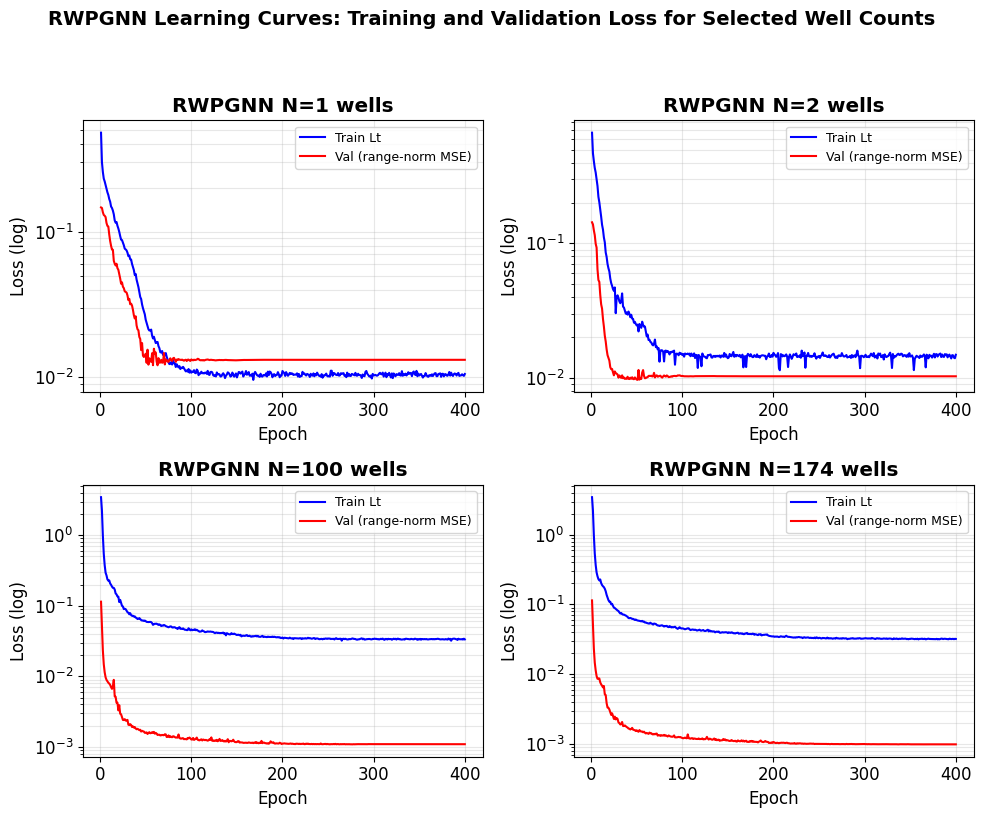

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter and sort the well counts to plot only the requested ones
requested_n_values = [1, 2, 100, 174]
sorted_n_values = sorted([n for n in all_learning_histories.keys() if n in requested_n_values])

# Determine grid size for subplots
num_plots = len(sorted_n_values)
# Arrange plots in 2 rows, dynamically determine columns
n_cols = (num_plots + 1) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for idx, n_wells in enumerate(sorted_n_values):
    hist = all_learning_histories[n_wells]
    ax = axes[idx]

    ep = np.arange(1, len(hist['train']) + 1)
    ax.semilogy(ep, hist['train'], 'b', lw=1.5, label='Train Lt')
    ax.semilogy(ep, hist['val'],  'r', lw=1.5, label='Val (range-norm MSE)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)')
    ax.set_title(f'RWPGNN N={n_wells} wells', fontweight='bold')
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, which='both', alpha=0.3)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('RWPGNN Learning Curves: Training and Validation Loss for Selected Well Counts',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig_RWPGNN_learning_curves_selected_N.png', dpi=150, bbox_inches='tight')
plt.show()

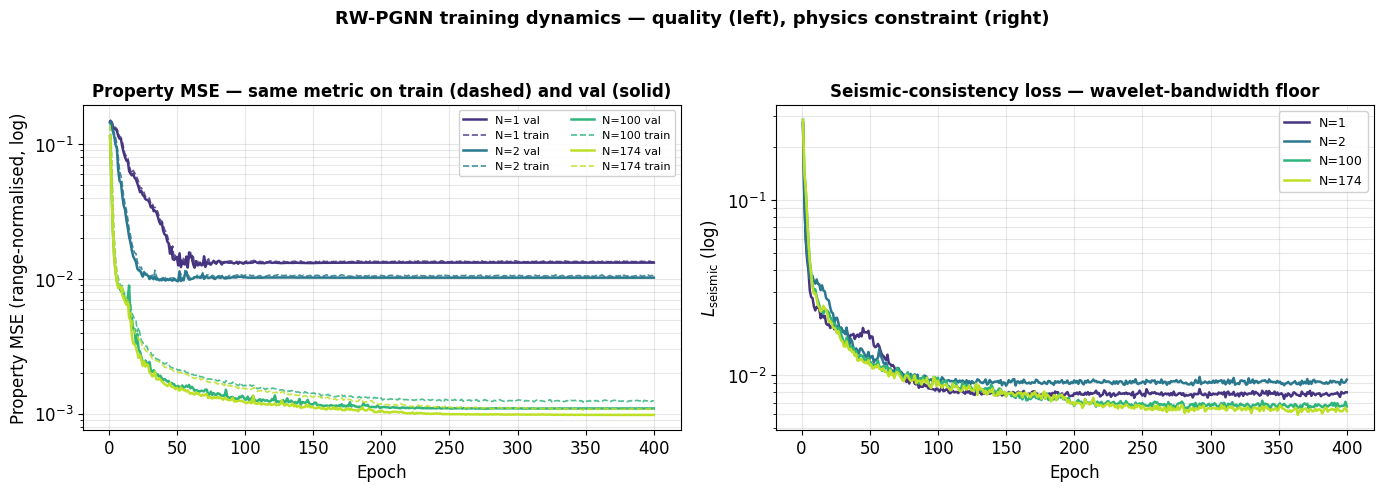


   N |    train MSE |      val MSE |  val/train |    L_seismic
------------------------------------------------------------------------
   1 |      0.01347 |      0.01320 |      0.980 |      0.00802
   2 |      0.01044 |      0.01022 |      0.979 |      0.00946
 100 |      0.00125 |      0.00110 |      0.877 |      0.00665
 174 |      0.00109 |      0.00098 |      0.900 |      0.00626
Final-epoch property MSE on TRAIN wells and TEST traces (same metric).
val/train > 1 ⇒ standard generalisation gap;  ~1 at small N ⇒ supervision is the bottleneck.


In [ ]:
# ── Learning curves v2 — same-axis property MSE, separate L_seismic panel ──
# Replaces the four-panel cross-N display with two single-panel views that share
# the same evaluation metric across train and val. Reads directly from
# `all_learning_histories` — no retraining. The plot tells two distinct stories:
#
#   LEFT  panel: range-normalised property MSE on train wells (dashed) vs test
#                traces (solid). Same metric on both, on the same axis ⇒ the
#                gap IS the generalisation error, with no need to caveat.
#
#   RIGHT panel: seismic-consistency loss L_seismic, all N overlaid. This is the
#                physics constraint, not a quality measure — separated so it
#                does not contaminate the left panel's interpretation.
#
# Why this is clearer than the previous four-panel version: the old plot put
# `L_data + β·L_seismic` on the train curve and range-norm property MSE on the
# val curve. These are different quantities, so train can sit ABOVE or BELOW
# val at the same epoch for purely structural reasons (e.g. the N=1 panel's
# "val > train" was a property of the loss decomposition, not of the model).
# Here, both train and val are property MSE on the same scale.
#
# Required fields in each `all_learning_histories[n]` entry:
#   'train_mse_prop' — range-normalised property MSE evaluated on TRAIN wells
#   'val'            — range-normalised property MSE on TEST traces
#   'Ls'             — seismic-consistency loss term
# All three are populated by `train_RWPGNN` in Part 2 Cell 3 (v8 onward).

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps

# ── 1. Defensive schema check ────────────────────────────────────────────────
N_VALUES_V2 = [1, 2, 100, 174]
REQUIRED_KEYS = ('train_mse_prop', 'val', 'Ls')

missing = []
for n in N_VALUES_V2:
    if n not in all_learning_histories:
        missing.append(f"N={n}: not in all_learning_histories")
        continue
    for k in REQUIRED_KEYS:
        if k not in all_learning_histories[n]:
            missing.append(f"N={n}: hist missing '{k}'")

if missing:
    raise RuntimeError(
        "Cannot build v2 learning curves — fix the following first:\n  "
        + "\n  ".join(missing)
        + "\n\nIf hist is missing 'train_mse_prop' or 'Ls', re-run the cell that "
          "defines train_RWPGNN (Part 2 Cell 3 / v8 onward) and then re-run the "
          "'Collecting Learning Histories' cell so all_learning_histories is "
          "rebuilt with the up-to-date schema."
    )

# ── 2. Colour scheme — sequential viridis, pale (small N) → dark (large N) ──
cmap = colormaps['viridis']
n_sorted = sorted(N_VALUES_V2)
colours = {n: cmap(0.15 + 0.75 * i / (len(n_sorted) - 1))
           for i, n in enumerate(n_sorted)}

# ── 3. Figure ────────────────────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.8))

# Left: property MSE, train dashed vs val solid, all N overlaid
for n in n_sorted:
    h = all_learning_histories[n]
    ep = np.arange(1, len(h['val']) + 1)
    c = colours[n]
    axL.semilogy(ep, h['val'], color=c, lw=1.8, ls='-',
                 label=f'N={n} val')
    axL.semilogy(ep, h['train_mse_prop'], color=c, lw=1.2, ls='--',
                 alpha=0.85, label=f'N={n} train')

axL.set_xlabel('Epoch')
axL.set_ylabel('Property MSE (range-normalised, log)')
axL.set_title('Property MSE — same metric on train (dashed) and val (solid)',
              fontsize=12, fontweight='bold')
axL.grid(True, which='both', alpha=0.3)
axL.legend(fontsize=8, ncol=2, loc='upper right', framealpha=0.9)

# Right: L_seismic — the physics constraint, separate from the quality metric.
for n in n_sorted:
    h = all_learning_histories[n]
    ep = np.arange(1, len(h['Ls']) + 1)
    axR.semilogy(ep, h['Ls'], color=colours[n], lw=1.8, label=f'N={n}')

axR.set_xlabel('Epoch')
axR.set_ylabel(r'$L_\mathrm{seismic}$ (log)')
axR.set_title('Seismic-consistency loss — wavelet-bandwidth floor',
              fontsize=12, fontweight='bold')
axR.grid(True, which='both', alpha=0.3)
axR.legend(fontsize=9, loc='upper right', framealpha=0.9)

plt.suptitle('RW-PGNN training dynamics — quality (left), physics constraint (right)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig_RWPGNN_learning_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Numerical summary — final epoch values, all N, both panels ────────────
print()
print("=" * 72)
print(f"{'N':>4} | {'train MSE':>12} | {'val MSE':>12} | {'val/train':>10} | {'L_seismic':>12}")
print("-" * 72)
for n in n_sorted:
    h = all_learning_histories[n]
    tr_final = h['train_mse_prop'][-1]
    vl_final = h['val'][-1]
    ls_final = h['Ls'][-1]
    ratio    = vl_final / tr_final if tr_final > 0 else float('nan')
    print(f"{n:>4d} | {tr_final:>12.5f} | {vl_final:>12.5f} | "
          f"{ratio:>10.3f} | {ls_final:>12.5f}")
print("=" * 72)
print("Final-epoch property MSE on TRAIN wells and TEST traces (same metric).")
print("val/train > 1 ⇒ standard generalisation gap;  ~1 at small N ⇒ "
      "supervision is the bottleneck.")

## Summary: Assumptions, Limitations, and Future Work

**What this project demonstrates**

- Direct multi-property petrophysical inversion from pre-stack AVO can be performed
  in one trace-level step. The encoder ingests a full (15 angles × 225 depth samples)
  gather and outputs (φ, V_sh, S_w) at every depth sample, with no patching, no
  smoothed-background reference, and no SVD basis embedded in the loss.
- The seismic-consistency term L_s is a true full-trace, all-angle waveform residual.
  The HM + Gassmann rock physics and the layer-by-layer exact analytic Zoeppritz P-P
  reflection coefficient (Aki & Richards 2002 Box 5.1; closed scalar form in
  Sheriff & Geldart 1995 eq. 3.20a) are the same physics used to generate the data
  in Part 1, so L_s measures a genuine forward-model residual rather than a
  linearisation gap.
- The well-count sweep (Part 2.5) reports per-property test-trace R² for
  N ∈ {1, 2, 4, 8, 16, 100, N_X}, each from random initialisation, against the
  Seis2Rock SVD reference. The crossover diagnostic is reproducible.
- The four-method comparison (Part 4) places RW-PGNN against Seis2Rock and the
  Das & Mukerji (2020) PetroNet and Cascaded CNN baselines on identical held-out
  test traces, with the same 35° angle range and the same train/test split, so
  differences reflect inductive bias rather than data exposure.

**Key limitations**

- *Synthetic data only.* Smeaheia synthetic; noise-free wells; the forward model
  used in L_s is the same model that generated the data. Real-data performance
  will be lower because of wavelet uncertainty, NMO stretch, migration residuals,
  and rock-physics-model mismatch at the reservoir.
- *Constant-angle gather convention.* Each output trace is labelled by a fixed
  reflection angle; per-interface Snell is enforced inside the Zoeppritz operator,
  but no surface-to-interface ray tracing is done. This matches the data-generator
  convention in `avo_synthetic_gather_2D` (Part 1), so the forward operator and
  the data are mutually consistent — but this is not a substitute for true
  ray-traced angle gathers.
- *Amplitude fidelity unmodelled.* NMO stretch, migration errors, gain residuals,
  and surface-consistent amplitude effects are not represented in either the
  data or the forward operator.
- *Stationary 20 Hz Ricker wavelet.* No wavelet uncertainty, no non-stationarity,
  no per-angle wavelet variation.
- *Uncertainty quantification is partial.* RW-PGNN is a point estimator in this
  notebook. The Das & Mukerji baseline uses MC Dropout (Gal & Ghahramani 2016)
  to provide an epistemic posterior approximation — the paper itself notes that
  this approximation underestimates true uncertainty (Das & Mukerji 2020, page
  N50). Aleatoric (data-noise) uncertainty is not modelled by either method.
- *Property identifiability is asymmetric.* The Smeaheia rock-physics regime
  has stronger AVO sensitivity to φ than to V_sh and S_w (cf. Mavko, Mukerji &
  Dvorkin 2009 §6.3 for the general result). The supervised well term L_w
  therefore carries more of the V_sh and S_w learning at small N. The well-count
  sweep makes this asymmetry visible in the per-property R²(N) curves.

**Future work**

1. *Field-data validation.* Apply the trace-level RW-PGNN to a real pre-stack
   dataset (Volve or a Smeaheia field section) with measured wavelet, real well
   logs, and a site-specific rock-physics model; quantify degradation versus
   the synthetic ceiling reported here.
2. *Wavelet uncertainty.* Replace the frozen 20 Hz Ricker with an inferred or
   banked wavelet (e.g. statistical wavelet per angle stack) and propagate
   wavelet uncertainty into the predicted properties.
3. *Heteroscedastic seismic loss.* Replace the per-(trace, angle) variance
   normaliser in L_s with a learned per-sample noise model so far-offset
   traces, where the SNR is genuinely lower, are downweighted in a calibrated
   rather than only variance-equalised way.
4. *Aleatoric uncertainty head.* Add a learned-variance output so the network
   can express data-noise uncertainty alongside the MC-Dropout-style epistemic
   uncertainty already produced by the Das & Mukerji baseline.
5. *Amplitude-fidelity experiment.* Inject NMO stretch, migration error, and
   gain residuals into the forward modelling and quantify RMSE inflation per
   property — the core question of the broader thesis on processing-induced
   quality ceilings for inversion.
6. *4D / time-lapse RW-PGNN.* The Smeaheia dataset includes a CO₂-displaced
   S_w section (`sw_displaced_2D`); running the trained model on monitor and
   baseline gathers gives a direct test of time-lapse property-change recovery
   on a CCS-relevant geometry.